<a id='0'></a>
# Projet d'analyse de données – Natation olympique

### Problématique

L'objectif de ce projet est d'étudier la natation olympique sur une longue période, de 1912 à 2020, afin de répondre à la question suivante :

**Comment caractériser l'évolution des performances et les profils nationaux en natation olympique entre 1912 et 2020 ?**

Ce travail analyse donc deux dimensions complémentaires : la dimension temporelle, c'est-à-dire l'évolution des performances au fil des éditions olympiques, et la dimension géographique, c'est-à-dire les différences entre pays en matière de présence, de régularité et de réussite.

### Présentation du jeu de données

Le jeu de données utilisé contient 4359 performances de nageurs et nageuses aux Jeux olympiques entre 1912 et 2020. Il provient de Kaggle.

Chaque ligne correspond à une performance observée dans une épreuve de natation olympique. D'après la structure du tableau, il s'agit de performances classées, avec un rang associé. Le jeu de données ne décrit donc pas nécessairement l'ensemble des séries ou des tours préliminaires, mais les performances retenues dans le classement officiel de l'épreuve considérée.

Le jeu de données contient notamment les variables suivantes :
- le lieu et l'année des Jeux olympiques ;
- la distance et le type de nage ;
- l'information indiquant s'il s'agit ou non d'un relais ;
- le sexe de l'athlète ;
- le pays ou l'équipe représentée ;
- le nom de l'athlète ;
- le résultat, le rang et le temps réalisé.

La suite du projet est organisée en trois parties : l'évolution temporelle des performances, l'étude des profils de pays, puis une projection prudente des performances futures.

Pour faciliter la lecture du jeu de données, voici la correspondance entre certains termes anglais et leur équivalent en français :

- Backstroke : dos crawlé
- Breaststroke : brasse
- Butterfly : papillon
- Freestyle : nage libre, généralement nagée en crawl
- Individual Medley : 4 nages
- Medley : relais 4 nages


# Sommaire

**[0 — Initialisation et préparation des données](#0)**
- [0.1 — Chargement du jeu de données](#0-1)
- [0.2 — Nettoyage des données](#0-2)
- [0.3 — Analyse descriptive préliminaire](#0-3)
- [0.4 — Variables construites pour la suite](#0-4)

**[Partie I — Question 1 : Comment les performances ont-elles évolué dans le temps ?](#q1)**
- [1.1 — Analyse descriptive ciblée](#1-1)
- [1.2 — Évolution temporelle globale des performances](#1-2)
- [1.3 — Évolution des performances par épreuve](#1-3)
- [1.4 — Évolution des performances par épreuve et par sexe](#1-4)
- [1.5 — Mesure explicite de l'écart hommes/femmes](#1-5)
- [1.6 — Mesure relative de l'écart hommes/femmes](#1-6)
- [1.7 — Étude des corrélations avec le temps](#1-7)
- [1.8 — ACP sur des variables agrégées par année](#1-8)
- [1.9 — Conclusion de la question 1](#1-9)

**[Partie II — Question 2 : Existe-t-il des profils de pays en natation olympique ?](#q2)**
- [2.1 — Construction du tableau pays](#2-1)
- [2.2 — Analyse descriptive des pays](#2-2)
- [2.3 — Choix des variables pour l'analyse multivariée](#2-3)
- [2.4 — ACP sur les pays](#2-4)
- [2.5 — Clustering hiérarchique des pays (CAH)](#2-5)
- [2.6 — K-means sur les pays](#2-6)
- [2.7 — Comparaison CAH et K-means](#2-7)
- [2.8 — Conclusion de la question 2](#2-8)
- [2.9 — Mise en perspective historique](#2-9)

**[Partie III — Question 3 : Peut-on esquisser une évolution future des performances ?](#q3)**
- [3.1 — Définir ce qu'on veut prédire et avec quelles données](#3-1)
- [3.2 — Première projection simple par régression linéaire](#3-2)
- [3.3 — Projection sur une période récente](#3-3)
- [3.4 — Comparaison des deux modèles de projection](#3-4)
- [3.5 — Projection de l'écart relatif hommes/femmes](#3-5)

**[Conclusion générale](#ccl)**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt #bibliothèque de base pour faire des graphiques
import seaborn as sns #pratique pour la visualisation, les boxplots...

from sklearn.preprocessing import StandardScaler #permet de standardiser les données, indispensable pour ACP et clustering
from sklearn.decomposition import PCA #permet de faire une Analyse en Composantes Principales
from sklearn.cluster import KMeans # algorithme de clustering, permet de regrouper les pays en groupes similaires
from scipy.cluster.hierarchy import dendrogram, linkage #clustering hiérarchique, permet de construire un dendrogramme

sns.set() # améliore le style des graphiques (plus lisibles et propres)

<a id='0-1'></a>
## 0.1 — Chargement du jeu de données


In [2]:
df = pd.read_csv("Olympic_Swimming_Results_1912to2020.csv")  
df.head()

,Location,Year,Distance (in meters),Stroke,Relay?,Gender,Team,Athlete,Results,Rank
0,Tokyo,2020,100m,Backstroke,0,Men,ROC,Evgeny Rylov,51.98,1
1,Tokyo,2020,100m,Backstroke,0,Men,ROC,Kliment Kolesnikov,52,2
2,Tokyo,2020,100m,Backstroke,0,Men,USA,Ryan Murphy,52.19,3
3,Tokyo,2020,100m,Backstroke,0,Men,ITA,Thomas Ceccon,52.3,4
4,Tokyo,2020,100m,Backstroke,0,Men,CHN,Jiayu Xu,52.51,4


In [3]:
df.shape

(4359, 10)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4359 entries, 0 to 4358
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Location              4359 non-null   str  
 1   Year                  4359 non-null   int64
 2   Distance (in meters)  4359 non-null   str  
 3   Stroke                4359 non-null   str  
 4   Relay?                4359 non-null   int64
 5   Gender                4359 non-null   str  
 6   Team                  4359 non-null   str  
 7   Athlete               4345 non-null   str  
 8   Results               4331 non-null   str  
 9   Rank                  4359 non-null   int64
dtypes: int64(3), str(7)
memory usage: 340.7 KB


On observe que certaines valeurs sont manquantes dans le jeu de données, notamment pour le nom de l'athlète, le résultat et le rang. Ces absences devront être prises en compte dans le nettoyage, car elles peuvent limiter certaines analyses ou empêcher certains calculs.

Par ailleurs, la variable `Results` est stockée sous forme de chaîne de caractères. Or, pour étudier l'évolution des performances de manière quantitative, il est nécessaire de disposer d'une mesure numérique du temps. Une étape de prétraitement consistera donc à convertir cette variable en un format exploitable pour les calculs, ici en secondes.


In [5]:
df.describe(include='all')

,Location,Year,Distance (in meters),Stroke,Relay?,Gender,Team,Athlete,Results,Rank
count,4359,4359.000000,4359,4359,4359.000000,4359,4359,4345,4331,4359.000000
unique,22,NaN,8,6,NaN,2,87,2821,3635,NaN
top,Tokyo,NaN,200m,Freestyle,NaN,Men,USA,Michael Phelps,Did not start,NaN
freq,368,NaN,1280,1973,NaN,2291,896,18,43,NaN
mean,NaN,1982.936453,NaN,NaN,0.169764,NaN,NaN,NaN,NaN,3.164946
std,NaN,26.928344,NaN,NaN,0.375468,NaN,NaN,NaN,NaN,1.189715
min,NaN,1912.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,0.000000
25%,NaN,1968.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,2.000000
50%,NaN,1988.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,4.000000
75%,NaN,2004.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,4.000000


On observe que la valeur la plus fréquente pour la variable `Results` est `Did not start` : certaines lignes ne contiennent donc pas de temps exploitable. Ces cas devront être convertis en valeurs manquantes avant les analyses quantitatives.


<a id='0-2'></a>
## 0.2 — Nettoyage des données

L'objectif est de convertir les temps en secondes et de gérer les valeurs non exploitables.


In [7]:
def convert_time_to_seconds(t):
    # Valeur manquante
    if pd.isna(t):
        return np.nan

    # Conversion en chaîne de caractères et suppression des espaces inutiles
    t = str(t).strip()

    # Cas où aucun temps exploitable n'est donné
    if t in ["Did not start", "Did not finish", "Disqualified"]:
        return np.nan

    try:
        # Formats du type minutes:secondes ou heures:minutes:secondes
        if ":" in t:
            parts = t.split(":")
            if len(parts) == 2:
                return float(parts[0]) * 60 + float(parts[1])
            elif len(parts) == 3:
                return float(parts[0]) * 3600 + float(parts[1]) * 60 + float(parts[2])

        # Format numérique directement exprimé en secondes
        val = float(t)
        if val > 1000:
            return val / 1000
        return val

    except:
        return np.nan


Cette fonction convertit différentes écritures d'un temps en une valeur numérique exprimée en secondes. Elle gère notamment :

- les valeurs manquantes ;
- les mentions `Did not start`, `Did not finish` et `Disqualified` ;
- les temps écrits au format minutes:secondes ;
- les temps écrits au format heures:minutes:secondes ;
- les valeurs numériques directement exprimées en secondes ;
- certains temps numériques anormalement grands, interprétés comme étant exprimés en millisecondes, puis convertis en secondes ;
- certains formats atypiques, qui sont automatiquement renvoyés comme valeurs manquantes si la conversion échoue.

On crée ensuite une nouvelle variable `Time_second`, qui sera utilisée dans toute la suite de l'analyse.


In [8]:
df["Time_second"] = df["Results"].apply(convert_time_to_seconds)
df.info()
print(df["Time_second"].isna().sum())

<class 'pandas.DataFrame'>
RangeIndex: 4359 entries, 0 to 4358
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Location              4359 non-null   str    
 1   Year                  4359 non-null   int64  
 2   Distance (in meters)  4359 non-null   str    
 3   Stroke                4359 non-null   str    
 4   Relay?                4359 non-null   int64  
 5   Gender                4359 non-null   str    
 6   Team                  4359 non-null   str    
 7   Athlete               4345 non-null   str    
 8   Results               4331 non-null   str    
 9   Rank                  4359 non-null   int64  
 10  Time_second           4226 non-null   float64
dtypes: float64(1), int64(3), str(7)
memory usage: 374.7 KB
133


Après application de la fonction `convert_time_to_seconds`, on obtient 4226 valeurs exploitables. On perd donc seulement 133 performances sur les 4359 disponibles au départ. La fonction permet ainsi de conserver l'essentiel du jeu de données tout en supprimant les lignes sans temps exploitable.


In [9]:
df["Time_second"].describe()

count    4226.000000
mean      209.657575
std       215.190842
min        21.070000
25%        66.932500
50%       132.985000
75%       251.992500
max      1395.400000
Name: Time_second, dtype: float64

In [10]:
df = df.dropna(subset=["Time_second"])
df.shape

(4226, 11)

In [11]:
df

,Location,Year,Distance (in meters),Stroke,Relay?,Gender,Team,Athlete,Results,Rank,Time_second
0,Tokyo,2020,100m,Backstroke,0,Men,ROC,Evgeny Rylov,51.98,1,51.98
1,Tokyo,2020,100m,Backstroke,0,Men,ROC,Kliment Kolesnikov,52,2,52.00
2,Tokyo,2020,100m,Backstroke,0,Men,USA,Ryan Murphy,52.19,3,52.19
3,Tokyo,2020,100m,Backstroke,0,Men,ITA,Thomas Ceccon,52.3,4,52.30
4,Tokyo,2020,100m,Backstroke,0,Men,CHN,Jiayu Xu,52.51,4,52.51
...,...,...,...,...,...,...,...,...,...,...,...
4353,Stockholm,1912,4x100,Freestyle,1,Women,AUT,"Margarete Adler, Bertha Zahourek, Josephine St...",00:06:17.000000,4,377.00
4355,Stockholm,1912,4x200,Freestyle,1,Men,AUS,"Malcolm Champion, Cecil Healy, Harold H. Hardw...",00:10:11.200000,1,611.20
4356,Stockholm,1912,4x200,Freestyle,1,Men,USA,"Duke Paoa Kahanamoku, Harry J. Hebner, Perry M...",00:10:20.200000,2,620.20
4357,Stockholm,1912,4x200,Freestyle,1,Men,GBR,"Thomas Sidney Battersby, Henry Taylor, John Ga...",00:10:28.600000,3,628.60


On dispose maintenant d'un jeu de données contenant uniquement des temps exploitables, avec une nouvelle variable `Time_second` exprimée en secondes.


<a id='0-3'></a>
## 0.3 — Analyse descriptive préliminaire


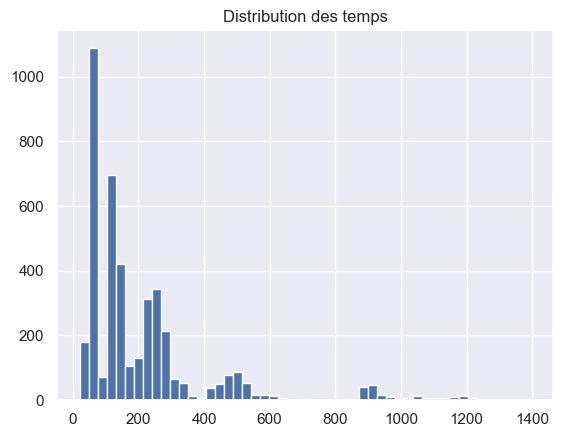

In [12]:
plt.hist(df["Time_second"], bins=50) #on trace un histogramme avec 50 intervalles pour chercher a savoir comment se repartissent globalement les temps de performance dans le dataset 
plt.title("Distribution des temps")
plt.show()

L’histogramme des temps permet d’observer la répartition globale des performances dans l’ensemble du jeu de données.

La distribution obtenue n’est pas unimodale : elle présente plusieurs groupes de valeurs distincts. Ce résultat est cohérent avec la structure du jeu de données, puisque celui-ci mélange des épreuves très différentes, à la fois en termes de distance, de style de nage et de sexe.

Cette observation montre qu’une analyse globale des temps serait insuffisante. Elle suggère au contraire qu’il est nécessaire de raisonner aussi par sous-groupes, par exemple selon l’épreuve ou le sexe, afin d’interpréter correctement les performances.

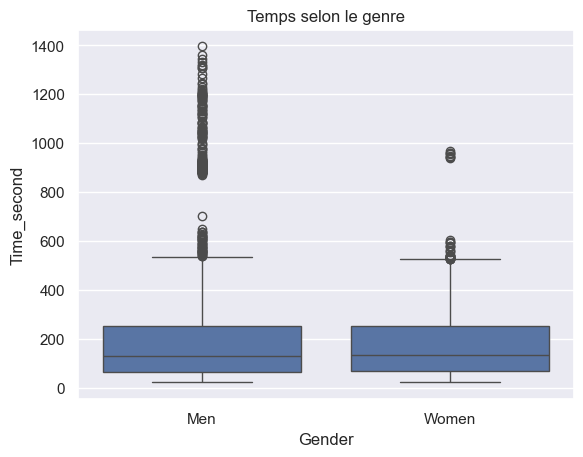

In [13]:
sns.boxplot(x="Gender", y="Time_second", data=df) #on construit un boxplot répartie selon le genre 
plt.title("Temps selon le genre")#le boxplot donne la mediane, les quartiles, les moustaches(etendue des valeurs) et les valeurs extermes/atypiques
plt.show()

Le boxplot des temps selon le sexe permet de comparer la distribution globale des performances masculines et féminines.

On observe que les valeurs centrales, en particulier la médiane, paraissent relativement proches entre les deux groupes. En revanche, les performances masculines présentent davantage de valeurs extrêmes et une dispersion plus importante.

Cette différence peut s’expliquer par le fait que le mélange d’épreuves n’est pas exactement le même chez les hommes et chez les femmes dans le jeu de données. Certaines longues distances sont notamment présentes chez les hommes mais pas systématiquement chez les femmes, ce qui peut élargir artificiellement la distribution masculine.

Il faut donc interpréter ce graphique avec prudence. Comme il agrège des épreuves très différentes, il ne permet pas à lui seul de conclure précisément sur les écarts de performance entre hommes et femmes. Une comparaison plus pertinente devra être menée à distance et style de nage fixés.

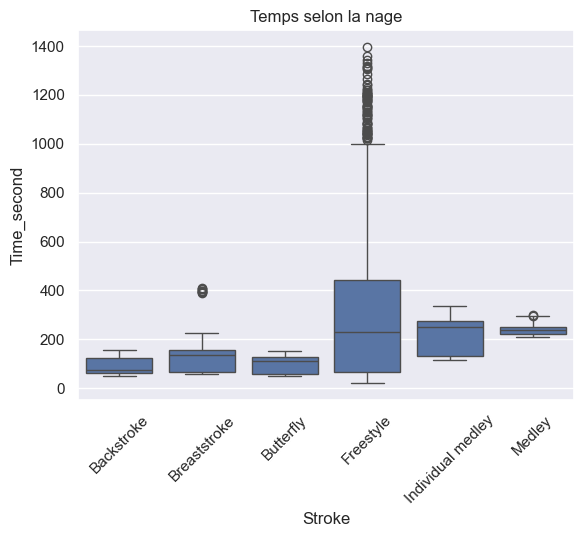

In [16]:
sns.boxplot(x="Stroke", y="Time_second", data=df) #on construit un boxplot 
plt.xticks(rotation=45)#Ça incline les étiquettes de l’axe horizontal de 45° pour qu’elles soient lisibles.
plt.title("Temps selon la nage")
plt.show()
#le crawl a des valeurs bien plus dispersés car il y a bcp de distances 
#Les nages backstroke, breaststroke et butterfly présentent des distributions plus resserrées. Les catégories Individual Medley et Medley semblent associées à des temps plus élevés.
#Il faut toutefois interpréter ce graphique avec prudence, car les différences observées reflètent à la fois l'effet du style de nage et celui des distances présentes dans chaque catégorie.

Le boxplot des temps selon le type de nage permet d’observer comment les performances se répartissent selon les différentes catégories d’épreuves.

On constate que la nage libre présente une dispersion beaucoup plus importante que les autres nages. Cela s’explique en grande partie par le fait que cette catégorie regroupe de nombreuses distances différentes, allant des épreuves courtes aux plus longues.

Le dos crawlé, la brasse et le papillon présentent des distributions plus resserrées. Les catégories 4 nages individuel et relais 4 nages semblent quant à elles associées à des temps plus élevés, ce qui est cohérent avec la nature plus longue ou plus complexe de ces épreuves.

Il faut toutefois interpréter ce graphique avec prudence. Les différences observées ne traduisent pas uniquement un effet du style de nage, mais aussi un effet de composition lié aux distances présentes dans chaque catégorie.

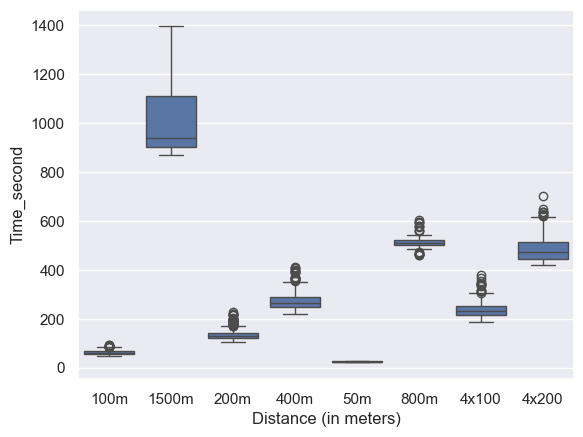

In [17]:
sns.boxplot(x="Distance (in meters)", y="Time_second", data=df)
plt.show()

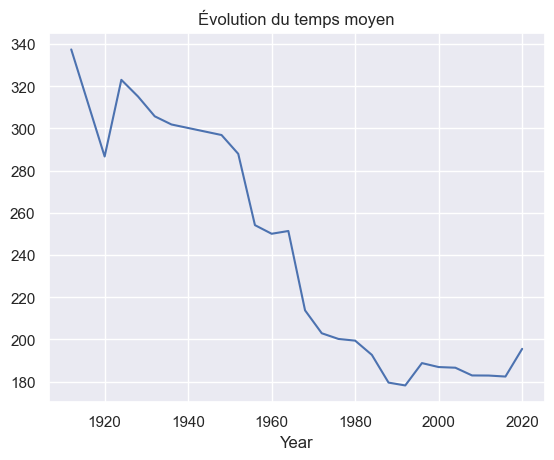

In [18]:
df.groupby("Year")["Time_second"].mean().plot() #df.groupby("Year") regroupe les lignes par année des JO
plt.title("Évolution du temps moyen")
plt.show()

Le tracé du temps moyen par année suggère, à première vue, une diminution progressive des temps au fil des éditions olympiques. Cette tendance va dans le sens d'une amélioration globale des performances au cours du temps.

Cette première lecture doit toutefois être nuancée. La courbe agrège l'ensemble des performances sans distinguer les distances, les styles de nage ni le sexe. Or ces catégories correspondent à des épreuves très différentes, dont les temps ne sont pas directement comparables.

Cette représentation est donc utile pour dégager une tendance générale, mais elle ne suffit pas à elle seule pour conclure de manière rigoureuse. La partie I reprendra cette question de façon plus fine, en travaillant sur des épreuves homogènes.


<a id='0-4'></a>
## 0.4 — Variables construites pour la suite

Avant de passer aux questions d'analyse, on construit quelques variables utiles pour la suite du projet : des indicateurs de médailles et une variable `Event`, qui combine la distance et le type de nage.


In [24]:
df["Gold"] = (df["Rank"] == 1).astype(int)
df["Silver"] = (df["Rank"] == 2).astype(int)
df["Bronze"] = (df["Rank"] == 3).astype(int)
df["Medals"] = df["Gold"] + df["Silver"] + df["Bronze"]

df.head()


,Location,Year,Distance (in meters),Stroke,Relay?,Gender,Team,Athlete,Results,Rank,Time_second,Gold,Silver,Bronze,Medals
0,Tokyo,2020,100m,Backstroke,0,Men,ROC,Evgeny Rylov,51.98,1,51.98,1,0,0,1
1,Tokyo,2020,100m,Backstroke,0,Men,ROC,Kliment Kolesnikov,52,2,52.00,0,1,0,1
2,Tokyo,2020,100m,Backstroke,0,Men,USA,Ryan Murphy,52.19,3,52.19,0,0,1,1
3,Tokyo,2020,100m,Backstroke,0,Men,ITA,Thomas Ceccon,52.3,4,52.30,0,0,0,0
4,Tokyo,2020,100m,Backstroke,0,Men,CHN,Jiayu Xu,52.51,4,52.51,0,0,0,0


In [31]:
df['Event'] = df['Distance (in meters)'].astype(str) + ' ' + df['Stroke'].astype(str)
df[['Distance (in meters)', 'Stroke', 'Event']].head()


,Distance (in meters),Stroke,Event
0,100m,Backstroke,100m Backstroke
1,100m,Backstroke,100m Backstroke
2,100m,Backstroke,100m Backstroke
3,100m,Backstroke,100m Backstroke
4,100m,Backstroke,100m Backstroke


Ces variables seront réutilisées dans les trois parties du projet : `Event` permettra de raisonner par épreuve homogène, tandis que les variables de médailles serviront à construire les profils de pays.


<a id='q1'></a>
# Partie I — Question 1 : Comment les performances ont-elles évolué dans le temps ?

Dans cette première partie, on cherche à étudier l’évolution des performances en natation olympique au cours du temps.

Plus précisément, on souhaite répondre à trois questions :

- Les temps baissent-ils globalement au fil des années ?
- Cette évolution est-elle la même selon les épreuves ?
- L’écart entre les performances masculines et féminines se réduit-il ?

<a id='1-1'></a>
### 1.1 — Analyse descriptive ciblée


In [32]:
q1_data = df[['Year', 'Gender', 'Distance (in meters)', 'Stroke', 'Event', 'Time_second']].copy()
q1_data.head() #on créer un nouveau data avec seulement les variables qui nous interesse

,Year,Gender,Distance (in meters),Stroke,Event,Time_second
0,2020,Men,100m,Backstroke,100m Backstroke,51.98
1,2020,Men,100m,Backstroke,100m Backstroke,52.00
2,2020,Men,100m,Backstroke,100m Backstroke,52.19
3,2020,Men,100m,Backstroke,100m Backstroke,52.30
4,2020,Men,100m,Backstroke,100m Backstroke,52.51


In [33]:
event_counts = q1_data['Event'].value_counts()
event_counts.head(20) #on compte ici cb on a de performances pour chaque epreuve 

Event
100m Freestyle            371
400m Freestyle            367
200m Breaststroke         362
100m Backstroke           353
4x100 Freestyle           263
200m Butterfly            248
100m Butterfly            246
200m Backstroke           232
400m Individual medley    232
4x100 Medley              230
4x200 Freestyle           226
200m Freestyle            223
100m Breaststroke         222
200m Individual medley    191
1500m Freestyle           188
50m Freestyle             144
800m Freestyle            120
400m Breaststroke           8
Name: count, dtype: int64

Ici, nous allons retenir 5 épreuves suffisamment différentes, tant par la distance que par la nage, et suffisamment représentées pour fonder notre analyse sur celles-ci.

J'ai sélectionné :
- 100 m Backstroke
- 100 m Freestyle
- 200 m Breaststroke
- 200 m Butterfly
- 400 m Freestyle


In [34]:
selected_events = ['100m Freestyle', '200m Butterfly','400m Freestyle','200m Breaststroke','100m Backstroke']
q1_selected = q1_data[q1_data['Event'].isin(selected_events)].copy() #q1_selected réduit le tableau des performances aux 5 épreuves que l'on va etudier  
q1_selected

,Year,Gender,Distance (in meters),Stroke,Event,Time_second
0,2020,Men,100m,Backstroke,100m Backstroke,51.98
1,2020,Men,100m,Backstroke,100m Backstroke,52.00
2,2020,Men,100m,Backstroke,100m Backstroke,52.19
3,2020,Men,100m,Backstroke,100m Backstroke,52.30
4,2020,Men,100m,Backstroke,100m Backstroke,52.51
...,...,...,...,...,...,...
4343,1912,Men,400m,Freestyle,400m Freestyle,324.40
4344,1912,Men,400m,Freestyle,400m Freestyle,325.80
4345,1912,Men,400m,Freestyle,400m Freestyle,331.20
4346,1912,Men,400m,Freestyle,400m Freestyle,337.80


In [35]:
q1_selected.groupby(['Event', 'Gender']).size()

Event              Gender
100m Backstroke    Men       177
                   Women     176
100m Freestyle     Men       186
                   Women     185
200m Breaststroke  Men       191
                   Women     171
200m Butterfly     Men       136
                   Women     112
400m Freestyle     Men       183
                   Women     184
dtype: int64

Le tableau donne, pour chaque épreuve retenue, le nombre de performances disponibles chez les hommes et chez les femmes.

On observe d’abord que les effectifs sont globalement équilibrés entre les deux sexes pour la plupart des épreuves. C’est le cas du 100m dos crawlé, du 100m nage libre et du 400m nage libre, où les nombres d’observations sont très proches chez les hommes et chez les femmes. Le 200m brasse présente lui aussi des effectifs relativement élevés dans les deux groupes, même si les hommes y sont légèrement plus nombreux.

On observe aussi qu’il y a moins de performances en 200m papillon que dans les autres épreuves. Cela s’explique en partie par le fait que le papillon est une nage plus récente : il s’est développé plus tard que les autres styles et n’est apparu aux Jeux olympiques qu’en 1956, à Melbourne.

Ce tableau montre ainsi que les épreuves retenues sont globalement suffisamment renseignées pour l’analyse, tout en signalant que le 200m papillon devra être interprété avec un peu plus de prudence en raison de sa profondeur historique plus limitée.

In [36]:
q1_selected.groupby('Event')['Time_second'].describe()

,count,mean,std,min,25%,50%,75%,max
Event,,,,,,,,
100m Backstroke,353.0,64.309065,8.926430,51.97,57.630,62.12,69.40,91.2
100m Freestyle,371.0,57.118895,7.629400,47.02,51.780,55.59,60.50,87.4
200m Breaststroke,362.0,155.086326,20.846935,126.38,139.020,150.69,168.55,227.6
200m Butterfly,248.0,126.320121,9.104971,111.25,118.385,126.69,131.63,154.3
400m Freestyle,367.0,265.356131,37.266365,220.14,236.850,251.70,290.25,385.4


In [37]:
q1_selected.groupby(['Event', 'Gender'])['Time_second'].describe()

count        mean        std     min       25%  \
Event             Gender                                                   
100m Backstroke   Men     177.0   60.956215   8.160565   51.97   54.7800   
                  Women   176.0   67.680966   8.396001   57.47   61.1350   
100m Freestyle    Men     186.0   53.317849   4.967326   47.02   49.0825   
                  Women   185.0   60.940486   7.934156   51.96   54.8400   
200m Breaststroke Men     191.0  146.980105  17.976518  126.38  131.6200   
                  Women   171.0  164.140643  20.134801  138.95  146.7800   
200m Butterfly    Men     136.0  122.053676   8.939955  111.25  115.8500   
                  Women   112.0  131.500804   6.155110  123.86  127.3925   
400m Freestyle    Men     183.0  253.975246  32.230802  220.14  227.7750   
                  Women   184.0  276.675163  38.549589  236.46  247.0925   

                              50%       75%    max  
Event             Gender                            
100m Backstroke   Men      57.690   66.5000   85.8  
                  Women    64.175   73.5750   91.2  
100m Freestyle    Men      51.780   57.8750   66.4  
                  Women    57.830   66.4000   87.4  
200m Breaststroke Men     140.790  160.0500  192.2  
                  Women   158.270  176.6500  227.6  
200m Butterfly    Men     118.940  124.8525  151.0  
                  Women   130.190  132.9675  154.3  
400m Freestyle    Men     237.180  278.0500  342.0  
                  Women   254.680  303.6500  385.4

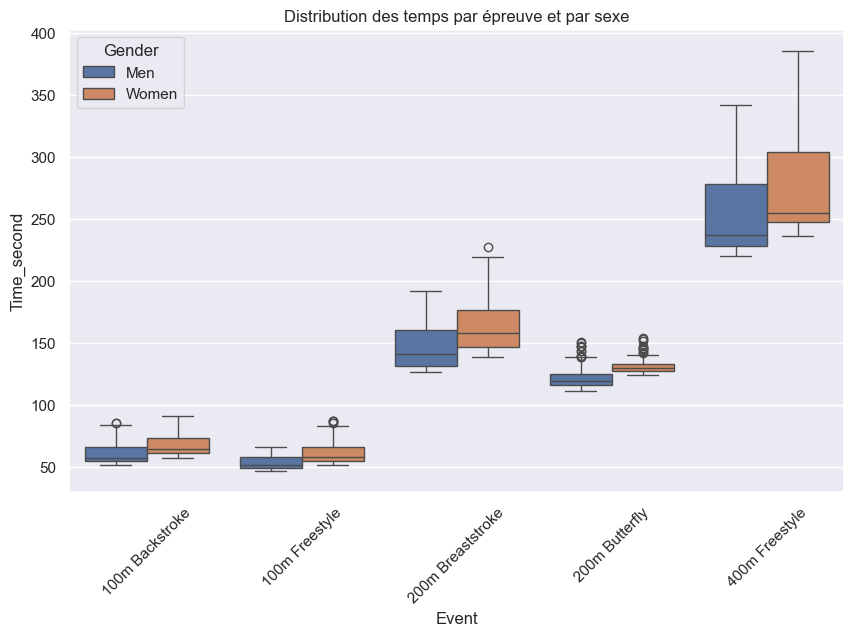

In [38]:
plt.figure(figsize=(10,6))
sns.boxplot(data=q1_selected, x='Event', y='Time_second', hue='Gender')
plt.title("Distribution des temps par épreuve et par sexe")
plt.xticks(rotation=45)
plt.show()

Cette première analyse descriptive menée sur les épreuves 100m dos, 100m nage libre, 200m brasse, 200m papillon et 400m nage libre met en évidence plusieurs éléments importants.

Pour chacune des cinq épreuves étudiées, les performances masculines sont en moyenne plus rapides que les performances féminines. Cet écart apparaît clairement à la fois dans les statistiques descriptives et sur les boxplots. Par exemple :
- sur le 100m nage libre, le temps moyen est d’environ 53,3 s chez les hommes contre 60,9 s chez les femmes ;
- sur le 100m dos, il est d’environ 61,0 s chez les hommes contre 67,7 s chez les femmes ;
- sur le 200m Brasse, il est d’environ 147,0 s chez les hommes contre 164,1 s chez les femmes ;
- sur le 200m papillon, il est d’environ 122,1 s chez les hommes contre 131,5 s chez les femmes ;
- sur le 400m nage libre, il est d’environ 254,0 s chez les hommes contre 276,7 s chez les femmes.

Les distributions montrent aussi une dispersion variable selon les épreuves. Cette dispersion est particulièrement marquée pour les épreuves plus longues, notamment le 400m nage libre, où l’étendue des performances est importante pour les deux sexes. On observe également plusieurs valeurs extrêmes, ce qui peut s’expliquer par l’évolution historique des performances : les anciennes éditions olympiques présentent probablement des temps plus élevés que les éditions récentes.

Ainsi, cette première exploration confirme qu’il est nécessaire de raisonner par épreuve homogène pour étudier correctement l’évolution des performances. Elle montre également qu’il existe un écart hommes/femmes dans toutes les épreuves retenues, mais que son ampleur peut varier selon la nage considérée. La suite de l’analyse devra donc examiner l’évolution temporelle de ces performances, épreuve par épreuve.

<a id='1-2'></a>
### 1.2 — Évolution temporelle globale des performances


Le but ici n’est pas encore de conclure définitivement, mais simplement de voir s’il existe une tendance générale quand on regarde les temps en fonction de l’année.
On va donc tracer le temps moyen par année et le temps médian par année


In [39]:
time_by_year = q1_data.groupby('Year')['Time_second'].agg(['mean', 'median', 'count']).reset_index()
#groupby('Year') regroupe les années par ligne 
#['Time_second'] pour chaque année on regarde la colonne time-second
#agg vient de aggregate, on applique mean, median et count a chaque année 
time_by_year

,Year,mean,median,count
0,1912,337.442105,256.600,38
1,1920,286.703030,192.200,33
2,1924,323.038596,217.600,57
3,1928,315.126471,196.400,68
4,1932,305.752239,191.700,67
5,1936,301.883544,189.500,79
6,1948,296.881609,182.500,87
7,1952,287.966667,177.800,87
8,1956,254.171845,158.700,103
9,1960,250.080672,174.600,119


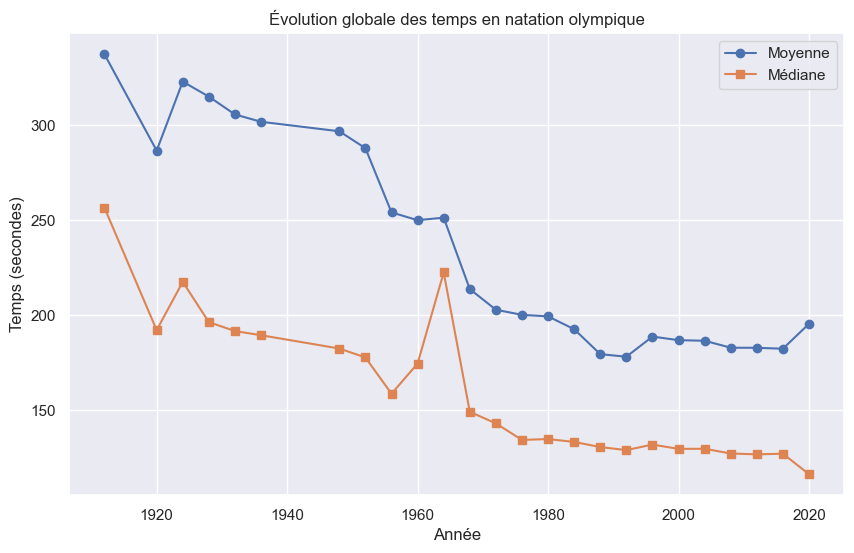

In [40]:
plt.figure(figsize=(10,6))
plt.plot(time_by_year['Year'], time_by_year['mean'], marker='o', label='Moyenne')
plt.plot(time_by_year['Year'], time_by_year['median'], marker='s', label='Médiane')
plt.title("Évolution globale des temps en natation olympique")
plt.xlabel("Année")
plt.ylabel("Temps (secondes)")
plt.legend()
plt.grid(True)
plt.show()

L’évolution du temps moyen et du temps médian par année suggère une amélioration globale des performances en natation olympique au cours du temps : les temps ont tendance à diminuer entre le début du XXe siècle et les éditions récentes.

La médiane est systématiquement inférieure à la moyenne, ce qui indique que la distribution des temps est tirée vers le haut par certaines valeurs élevées, probablement liées aux épreuves plus longues ou à des performances anciennes plus lentes.

Cependant, cette lecture globale doit être interprétée avec prudence. En effet, cette agrégation mélange des épreuves très différentes (distances, styles, sexes, relais), dont les temps ne sont pas directement comparables. Ainsi, une variation de la moyenne d’une année à l’autre peut refléter à la fois une évolution réelle des performances et un changement dans la composition des épreuves olympiques.

<a id='1-3'></a>
### 1.3 — Évolution des performances par épreuve


On corrige ici la limite de l'analyse globale précédente : au lieu de mélanger toutes les épreuves, on étudie l'évolution des performances à l'intérieur de chaque épreuve sélectionnée.


In [41]:
event_year = q1_selected.groupby(['Event', 'Year'])['Time_second'].agg(['mean', 'median', 'count']).reset_index()
event_year 
#ici on ne melange plus les courses, on calcule moyenne et mediane epreuve par epreuve

,Event,Year,mean,median,count
0,100m Backstroke,1912,83.720000,84.000,5
1,100m Backstroke,1920,77.600000,77.900,4
2,100m Backstroke,1924,82.680000,81.600,10
3,100m Backstroke,1928,78.369231,82.000,13
4,100m Backstroke,1932,76.316667,76.100,12
...,...,...,...,...,...
112,400m Freestyle,2004,236.982500,237.150,16
113,400m Freestyle,2008,234.306250,235.755,16
114,400m Freestyle,2012,234.834375,235.350,16
115,400m Freestyle,2016,233.659375,232.765,16


In [42]:
event_year.groupby('Event')['Year'].nunique() #Ça permet de voir si les 5 épreuves sont bien suivies sur un nombre suffisant d’éditions.
#on voit que le 200m papillon est moins représneté car plus recent, les autres epreuves sont représentés lors de toutes les editions disponible sur le jeu de données.

Event
100m Backstroke      25
100m Freestyle       25
200m Breaststroke    25
200m Butterfly       17
400m Freestyle       25
Name: Year, dtype: int64

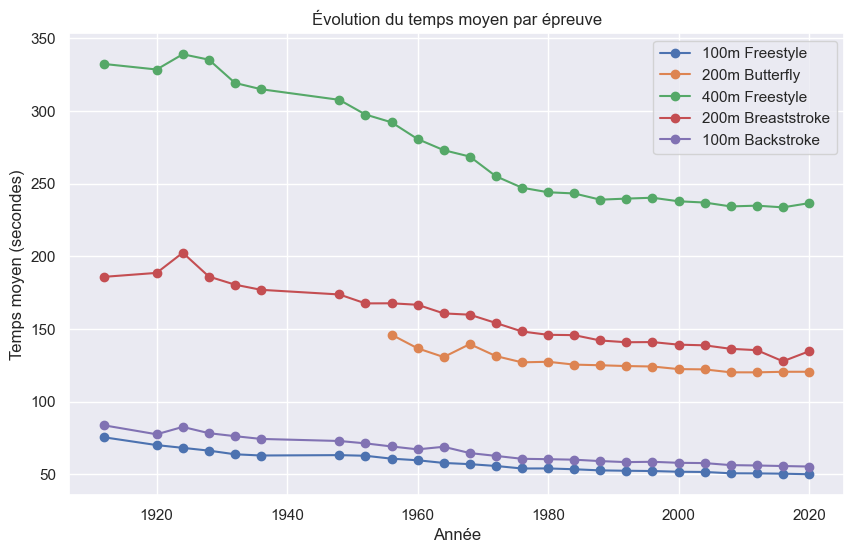

In [43]:
plt.figure(figsize=(10,6))

for event in selected_events:
    subset = event_year[event_year['Event'] == event] #Cette ligne extrait du tableau event_year uniquement les lignes correspondant à l’épreuve en cours
    plt.plot(subset['Year'], subset['mean'], marker='o', label=event)

plt.title("Évolution du temps moyen par épreuve")
plt.xlabel("Année")
plt.ylabel("Temps moyen (secondes)")
plt.legend()
plt.grid(True)
plt.show()

L’étude de l’évolution des temps moyens par épreuve confirme la tendance générale observée précédemment : les performances s’améliorent globalement au cours du temps, puisque les temps moyens diminuent dans les cinq épreuves retenues.

Cette baisse est visible pour les épreuves anciennes et régulièrement présentes au programme olympique, ici le 100m nage libre, le 100m dos, le 200m brasse et le 400m nage libre, qui sont chacune observées sur 25 éditions. Elle apparaît également pour le 200m papillon , bien que cette épreuve ne soit observée que sur 17 éditions, ce qui limite un peu la profondeur historique de son analyse.

Cette analyse confirme donc que la baisse des temps ne provient pas seulement d’une agrégation globale des données : elle apparaît aussi lorsqu’on raisonne sur des épreuves homogènes. Toutefois, la dynamique n’est pas identique selon les nages. Certaines épreuves suivent une trajectoire assez régulière, tandis que d’autres présentent davantage de fluctuations ou une stabilisation plus précoce dans les périodes récentes.

<a id='1-4'></a>
### 1.4 — Évolution des performances par épreuve et par sexe


On compare maintenant les performances par épreuve et par sexe afin de répondre à une question complémentaire : l'écart entre hommes et femmes se réduit-il au fil du temps ?


In [44]:
event_year_gender = q1_selected.groupby(['Event', 'Year', 'Gender'])['Time_second'].agg(['mean', 'median', 'count']).reset_index()
event_year_gender.head(20)

,Event,Year,Gender,mean,median,count
0,100m Backstroke,1912,Men,83.720000,84.00,5
1,100m Backstroke,1920,Men,77.600000,77.90,4
2,100m Backstroke,1924,Men,77.200000,77.80,5
3,100m Backstroke,1924,Women,88.160000,88.20,5
4,100m Backstroke,1928,Men,72.166667,72.80,6
5,100m Backstroke,1928,Women,83.685714,84.20,7
6,100m Backstroke,1932,Men,70.566667,70.45,6
7,100m Backstroke,1932,Women,82.066667,82.55,6
8,100m Backstroke,1936,Men,68.885714,69.40,7
9,100m Backstroke,1936,Women,79.942857,79.60,7


In [45]:
event_year_gender.groupby(['Event', 'Gender'])['Year'].nunique()
#nunique compte le nombre de valeurs distinctes de Year dans chaque groupe
#on observe que les 2 sexes sont presents et de maniere a peu pres egale dans les 2 epreuves qu'on observe 
#encore une fois le 200 papillon est le moins exploitable 

Event              Gender
100m Backstroke    Men       24
                   Women     23
100m Freestyle     Men       25
                   Women     25
200m Breaststroke  Men       25
                   Women     22
200m Butterfly     Men       17
                   Women     14
400m Freestyle     Men       25
                   Women     23
Name: Year, dtype: int64

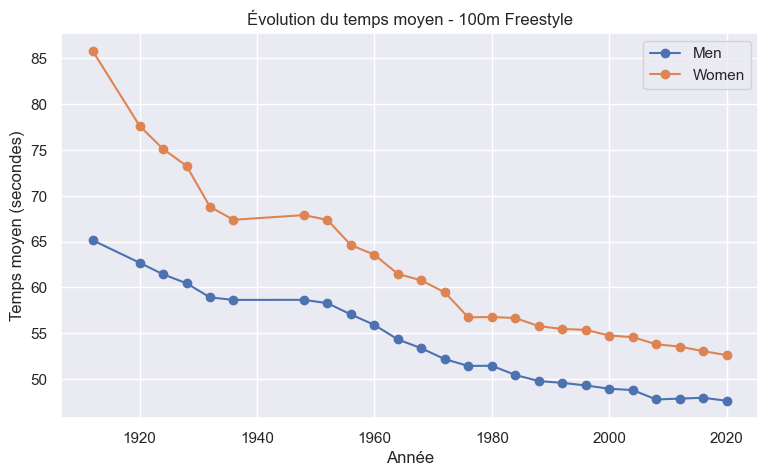

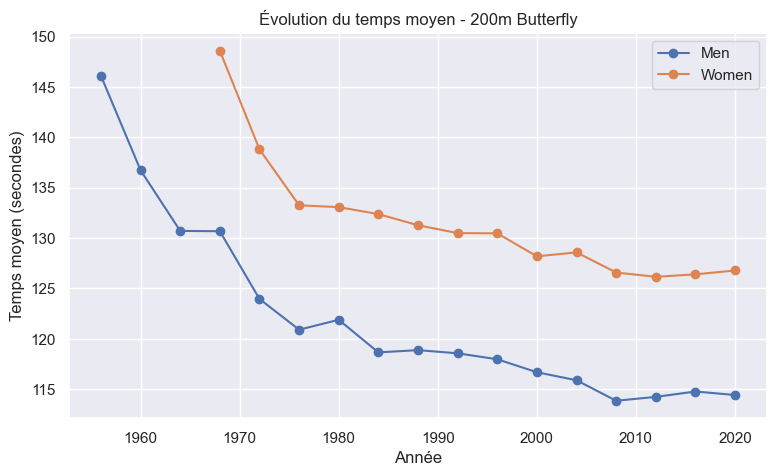

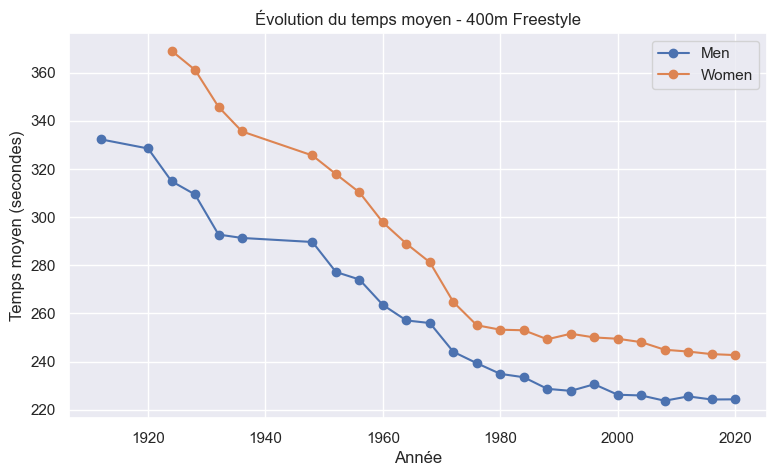

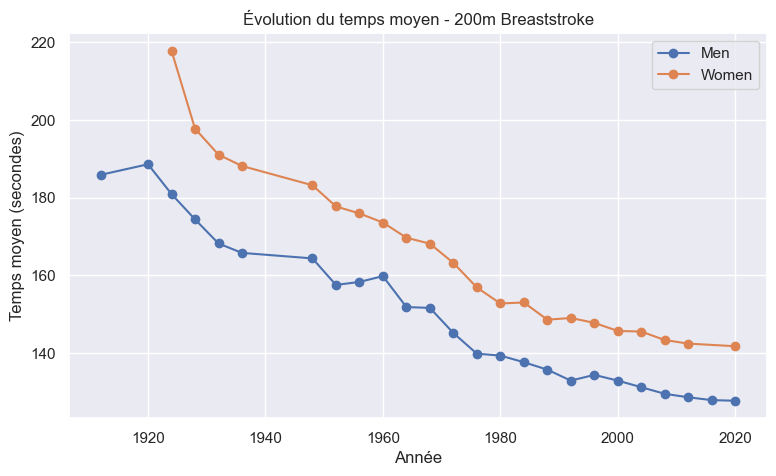

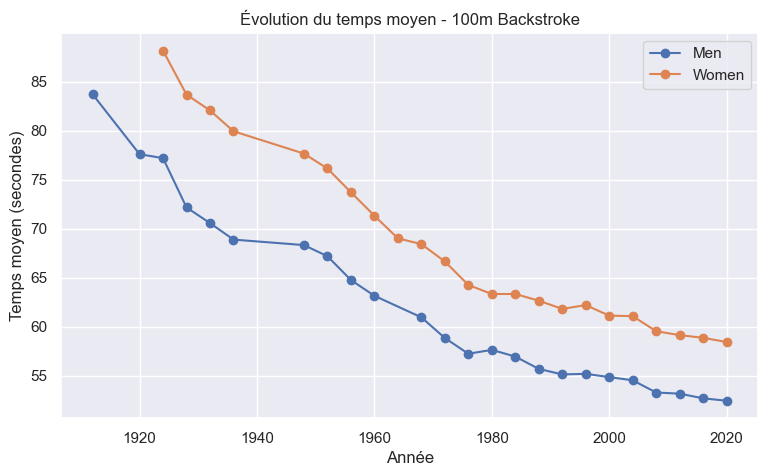

In [46]:
for event in selected_events:
    plt.figure(figsize=(9,5))
    
    for gender in ['Men', 'Women']:
        subset = event_year_gender[
            (event_year_gender['Event'] == event) &
            (event_year_gender['Gender'] == gender)
        ]
        plt.plot(subset['Year'], subset['mean'], marker='o', label=gender)
    
    plt.title(f"Évolution du temps moyen - {event}")
    plt.xlabel("Année")
    plt.ylabel("Temps moyen (secondes)")
    plt.legend()
    plt.grid(True)
    plt.show()

L’analyse des temps moyens par épreuve et par sexe montre que les performances progressent globalement chez les hommes comme chez les femmes. Dans les cinq épreuves étudiées, les temps moyens diminuent au fil des années, ce qui confirme une amélioration générale des performances indépendamment du sexe.

On observe également que, pour chaque épreuve, les temps moyens masculins restent inférieurs aux temps moyens féminins sur l’ensemble de la période étudiée. Il existe donc un écart hommes/femmes persistant dans les performances, quelle que soit la nage considérée.

Cependant, la dynamique de cet écart n’est pas exactement la même selon les épreuves. Dans le 100m Freestyle et le 100m Backstroke, les deux courbes se rapprochent progressivement, ce qui suggère une réduction visible de l’écart au fil du temps. Dans le 200m Breaststroke et le 400m Freestyle, on observe également un rapprochement global, même si celui-ci paraît plus progressif. En revanche, dans le 200m Butterfly, bien que les performances s’améliorent pour les deux sexes, le rapprochement visuel semble moins net et davantage marqué par une forme de stabilisation dans les périodes récentes.

<a id='1-5'></a>
### 1.5 — Mesure explicite de l'écart hommes/femmes


Jusqu’ici, on a regardé les courbes séparément. Maintenant, on veut quantifier l’écart entre hommes et femmes pour chaque épreuve et chaque année.

L’idée la plus simple est de calculer :

$$
\text{écart} = \text{temps moyen des femmes} - \text{temps moyen des hommes}
$$

Donc :

- si l’écart est grand, les performances féminines sont plus éloignées des performances masculines ;
- si l’écart diminue, cela signifie que les performances féminines se rapprochent de celles des hommes.

In [47]:
gap_data = event_year_gender.pivot_table(
    index=['Event', 'Year'],
    columns='Gender',
    values='mean'
).reset_index()
#la fonction pivot_table sert a transformer un tableau long en un tableau large 

gap_data = gap_data.dropna(subset=['Men', 'Women']).copy()
gap_data

Gender,Event,Year,Men,Women
2,100m Backstroke,1924,77.200000,88.160000
3,100m Backstroke,1928,72.166667,83.685714
4,100m Backstroke,1932,70.566667,82.066667
5,100m Backstroke,1936,68.885714,79.942857
6,100m Backstroke,1948,68.325000,77.662500
...,...,...,...,...
112,400m Freestyle,2004,225.915000,248.050000
113,400m Freestyle,2008,223.717500,244.895000
114,400m Freestyle,2012,225.525000,244.143750
115,400m Freestyle,2016,224.240000,243.078750


In [48]:
gap_data['Gap_Women_Men'] = gap_data['Women'] - gap_data['Men']
gap_data.head(75)

Gender,Event,Year,Men,Women,Gap_Women_Men
2,100m Backstroke,1924,77.200000,88.160000,10.960000
3,100m Backstroke,1928,72.166667,83.685714,11.519048
4,100m Backstroke,1932,70.566667,82.066667,11.500000
5,100m Backstroke,1936,68.885714,79.942857,11.057143
6,100m Backstroke,1948,68.325000,77.662500,9.337500
...,...,...,...,...,...
79,200m Butterfly,1972,123.960000,138.806250,14.846250
80,200m Butterfly,1976,120.907500,133.252500,12.345000
81,200m Butterfly,1980,121.890000,133.068750,11.178750
82,200m Butterfly,1984,118.655000,132.377500,13.722500


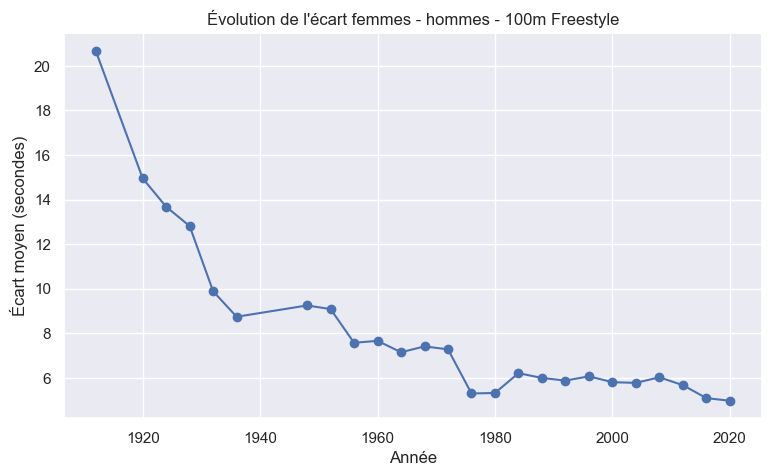

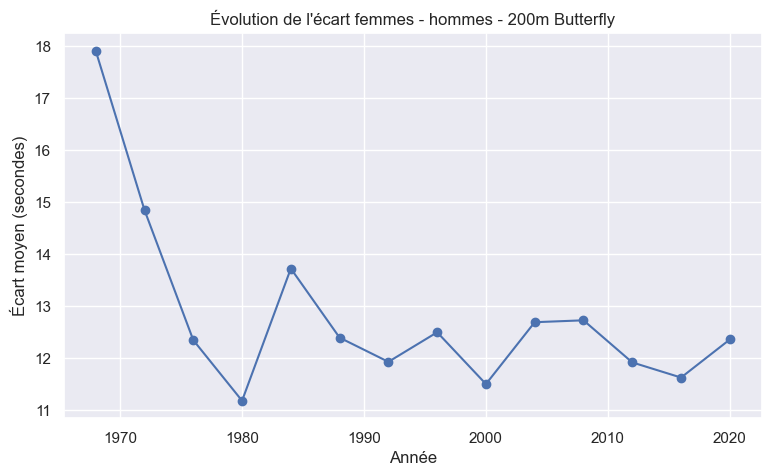

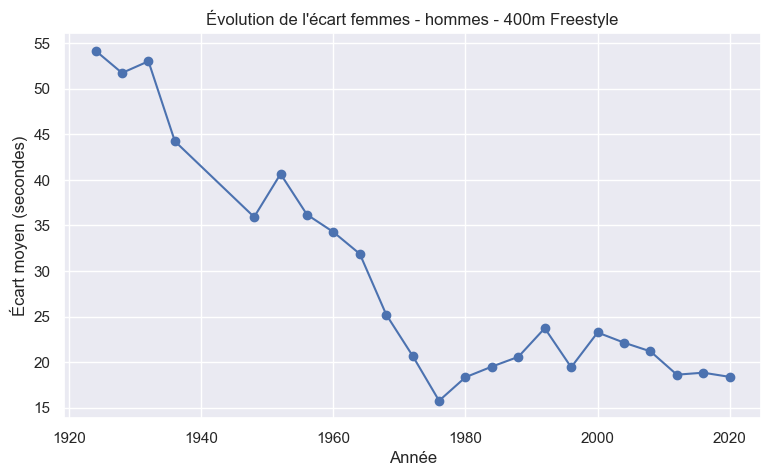

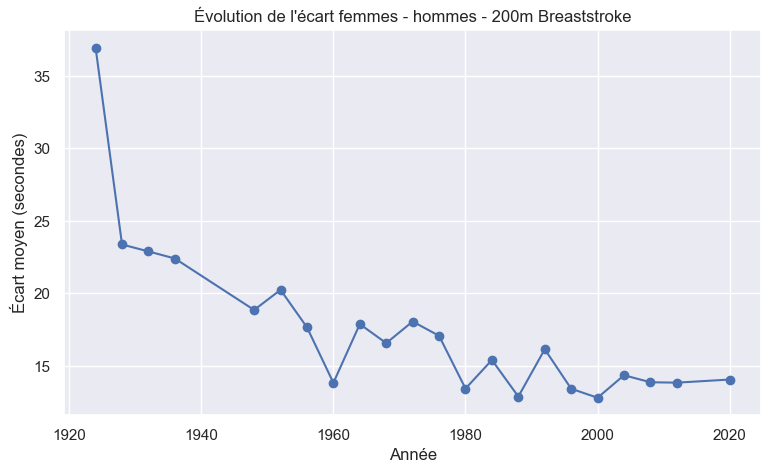

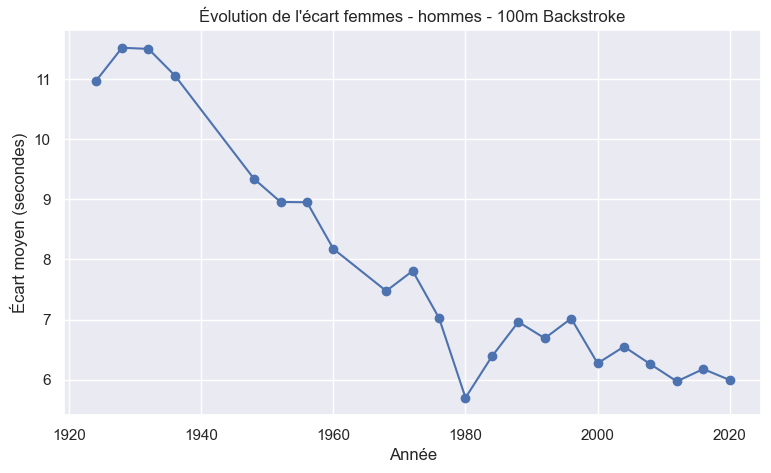

In [49]:
for event in selected_events:
    subset = gap_data[gap_data['Event'] == event]

    plt.figure(figsize=(9,5))
    plt.plot(subset['Year'], subset['Gap_Women_Men'], marker='o')

    plt.title(f"Évolution de l'écart femmes - hommes - {event}")
    plt.xlabel("Année")
    plt.ylabel("Écart moyen (secondes)")
    plt.grid(True)
    plt.show()

Le calcul explicite de l’écart entre le temps moyen des femmes et celui des hommes permet d’analyser plus rigoureusement l’évolution de la différence de performance entre les deux sexes selon l’épreuve.

Pour les épreuves de 100m nage libre et 100m dos, l’écart diminue nettement au cours du temps. Il est relativement élevé au début de la période observée, puis se réduit progressivement pour atteindre environ 5 à 6 secondes dans les éditions récentes. Ces deux épreuves mettent donc en évidence un rapprochement marqué des performances féminines et masculines.

Pour le 200m papillon, l’écart diminue également dans un premier temps, mais la baisse devient ensuite beaucoup moins prononcée. À partir des années 1980 environ, l’écart oscille globalement autour de 11 à 13 secondes, ce qui suggère plutôt une stabilisation qu’une diminution continue.

Le 200m brasse présente lui aussi une baisse globale de l’écart au fil du temps. L’écart est très important dans les premières éditions observées, puis diminue nettement, avant de se stabiliser à un niveau intermédiaire dans les périodes récentes, autour d’une quinzaine de secondes. On observe donc un rapprochement réel, mais moins spectaculaire que pour les épreuves de 100 mètres.

Le 400m nage libre montre le plus grand écart absolu en secondes, ce qui est cohérent avec la longueur de l’épreuve. Là encore, l’écart diminue fortement entre les premières éditions et la seconde moitié du XXe siècle, puis semble davantage fluctuer autour d’un niveau plus stable dans les périodes récentes, souvent compris entre 18 et 24 secondes.


Les graphes degagnent une tendance générale mais présentent des valeurs qui n'ont pas vraiment de sens. Le plus choquant est le fait que le gap homme/femme en 200m papillon atteint sa valeur la plus faible en 1980 avant de remonter 
Le fait que l’écart femmes-hommes atteigne un minimum en 1980 n’est pas nécessairement dû à un problème d’effectif, puisque les deux groupes contiennent le même nombre de performances. Cette variation peut s’expliquer par le fait que l’on compare ici les moyennes de seulement huit finalistes par sexe, ce qui rend l’indicateur sensible à la qualité particulière d’une génération ou d’une olympiade. Dans une épreuve relativement récente comme le 200m papillon, on peut également observer une phase initiale de rattrapage rapide, suivie d’une stabilisation. Ainsi, ce creux en 1980 semble davantage traduire une fluctuation réelle des niveaux relatifs qu’une anomalie de construction de la variable.

<a id='1-6'></a>
### 1.6 — Mesure relative de l'écart hommes/femmes


On va faire un ratio plus significatif, car les secondes n'ont pas la meme valeur sur 100m que sur 200m par exemple.


On peut définir :

$$
\text{écart relatif} = \frac{\text{Women} - \text{Men}}{\text{Men}}
$$

Cette quantité :

- est positive si les temps féminins sont plus élevés ;
- se lit comme une proportion ;
- peut être transformée en pourcentage.

Par exemple :

- `0.10` signifie que le temps féminin est environ 10 % plus élevé que le temps masculin.

In [50]:
gap_data['Relative_Gap'] = (gap_data['Women'] - gap_data['Men']) / gap_data['Men']
gap_data.head(10)

Gender,Event,Year,Men,Women,Gap_Women_Men,Relative_Gap
2,100m Backstroke,1924,77.200000,88.160000,10.960000,0.141969
3,100m Backstroke,1928,72.166667,83.685714,11.519048,0.159617
4,100m Backstroke,1932,70.566667,82.066667,11.500000,0.162966
5,100m Backstroke,1936,68.885714,79.942857,11.057143,0.160514
6,100m Backstroke,1948,68.325000,77.662500,9.337500,0.136663
7,100m Backstroke,1952,67.187500,76.142857,8.955357,0.133289
8,100m Backstroke,1956,64.762500,73.712500,8.950000,0.138197
9,100m Backstroke,1960,63.150000,71.325000,8.175000,0.129454
11,100m Backstroke,1968,60.950000,68.425000,7.475000,0.122642
12,100m Backstroke,1972,58.843750,66.652500,7.808750,0.132703


In [51]:
gap_data['Relative_Gap_pct'] = 100 * gap_data['Relative_Gap']
gap_data.head(10)

Gender,Event,Year,Men,Women,Gap_Women_Men,Relative_Gap,Relative_Gap_pct
2,100m Backstroke,1924,77.200000,88.160000,10.960000,0.141969,14.196891
3,100m Backstroke,1928,72.166667,83.685714,11.519048,0.159617,15.961729
4,100m Backstroke,1932,70.566667,82.066667,11.500000,0.162966,16.296646
5,100m Backstroke,1936,68.885714,79.942857,11.057143,0.160514,16.051431
6,100m Backstroke,1948,68.325000,77.662500,9.337500,0.136663,13.666301
7,100m Backstroke,1952,67.187500,76.142857,8.955357,0.133289,13.328904
8,100m Backstroke,1956,64.762500,73.712500,8.950000,0.138197,13.819726
9,100m Backstroke,1960,63.150000,71.325000,8.175000,0.129454,12.945368
11,100m Backstroke,1968,60.950000,68.425000,7.475000,0.122642,12.264151
12,100m Backstroke,1972,58.843750,66.652500,7.808750,0.132703,13.270313


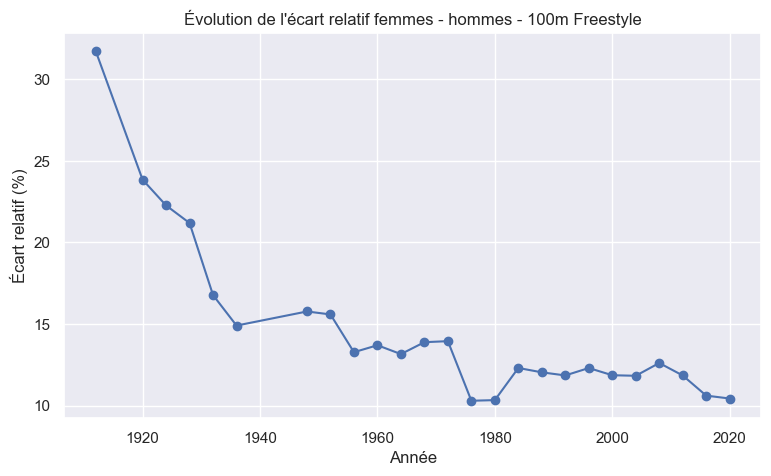

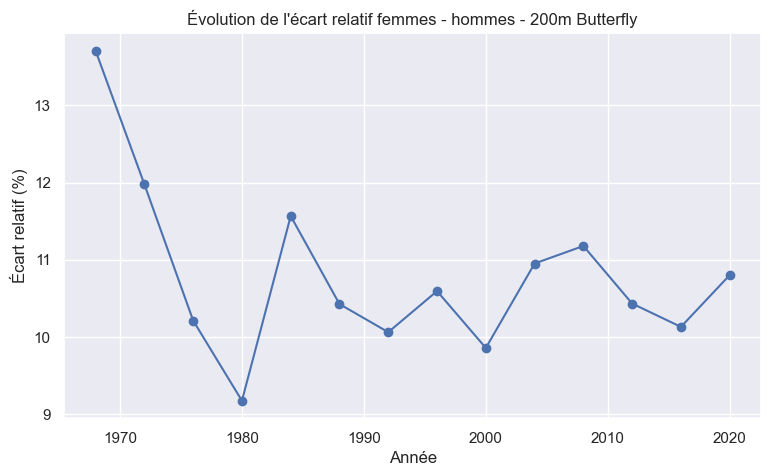

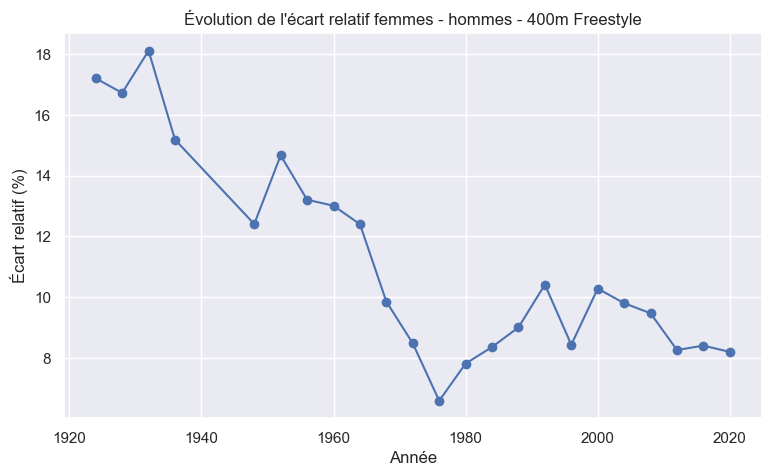

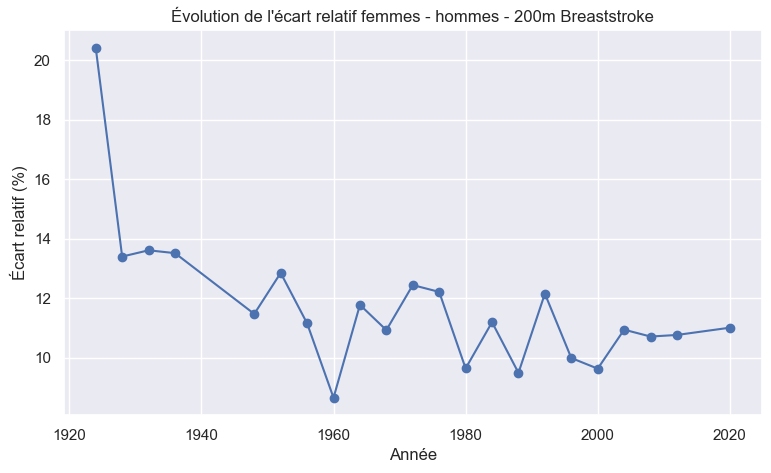

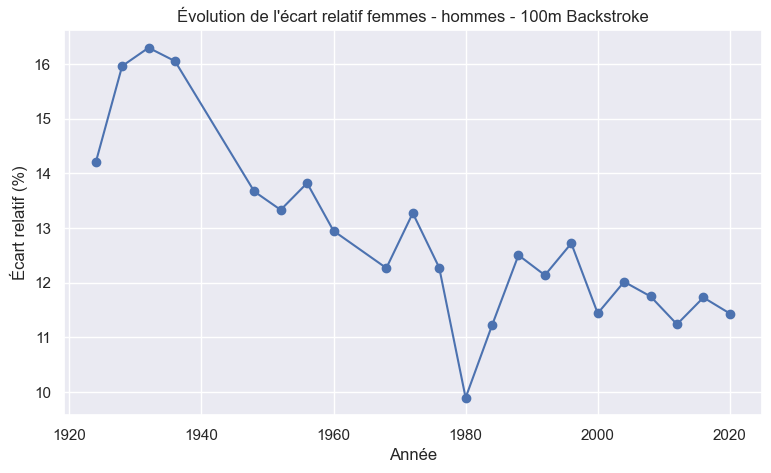

In [52]:
for event in selected_events:
    subset = gap_data[gap_data['Event'] == event]

    plt.figure(figsize=(9,5))
    plt.plot(subset['Year'], subset['Relative_Gap_pct'], marker='o')

    plt.title(f"Évolution de l'écart relatif femmes - hommes - {event}")
    plt.xlabel("Année")
    plt.ylabel("Écart relatif (%)")
    plt.grid(True)
    plt.show()

L’étude en pourcentage complète utilement l’analyse précédente en secondes, car elle permet de comparer des épreuves de durées très différentes sur une base plus homogène. Elle montre que, même lorsque l’écart absolu reste important dans les épreuves longues, l’écart relatif peut être d’ampleur comparable, voire plus faible, que dans certaines épreuves plus courtes.

On observe ainsi que les différentes nages tendent, dans les périodes récentes, vers des écarts relatifs souvent situés dans une zone assez resserrée, autour de 9 à 12 %. Cette lecture nuance donc l’interprétation en secondes : une grande différence absolue dans une épreuve longue ne signifie pas nécessairement un écart relatif plus marqué. L’approche en pourcentage permet ainsi une comparaison plus équilibrée entre épreuves et confirme que les écarts hommes/femmes se lisent différemment selon l’échelle retenue.

<a id='1-7'></a>
### 1.7 — Étude des corrélations avec le temps


Ici, on utilise la corrélation linéaire de Pearson pour mesurer l’intensité du lien entre l'année et une variable de performance(temps moyen, ecart homme/femme, ecart relatif )

La correlation lineaire de Pearson mesure l intensite et le sens de la relation lineaire entre deux variables quantitatives.

Son coefficient, noté r, est compris entre -1 et 1 : r proche de 1 indique une liaison lineaire positive forte, r proche de -1 une liaison lineaire negative forte, et r proche de 0 une absence de relation lineaire nette.

Elle permet donc de voir si deux variables evoluent ensemble de facon croissante ou decroissante, sans pour autant prouver une causalite.

In [53]:
event_year.groupby('Event')[['Year', 'mean']].corr()

Year      mean
Event                                     
100m Backstroke   Year  1.000000 -0.975971
                  mean -0.975971  1.000000
100m Freestyle    Year  1.000000 -0.966174
                  mean -0.966174  1.000000
200m Breaststroke Year  1.000000 -0.972880
                  mean -0.972880  1.000000
200m Butterfly    Year  1.000000 -0.889122
                  mean -0.889122  1.000000
400m Freestyle    Year  1.000000 -0.960296
                  mean -0.960296  1.000000

In [54]:
for event in selected_events:
    subset = event_year[event_year['Event'] == event] #on filtre le tableau pour ne garder que l'epreuve en cours
    corr = subset['Year'].corr(subset['mean'])
    print(f"Corrélation Year / temps moyen pour {event} : {corr:.3f}")

Corrélation Year / temps moyen pour 100m Freestyle : -0.966
Corrélation Year / temps moyen pour 200m Butterfly : -0.889
Corrélation Year / temps moyen pour 400m Freestyle : -0.960
Corrélation Year / temps moyen pour 200m Breaststroke : -0.973
Corrélation Year / temps moyen pour 100m Backstroke : -0.976


In [55]:
for event in selected_events:
    subset = gap_data[gap_data['Event'] == event]
    corr = subset['Year'].corr(subset['Gap_Women_Men'])
    print(f"Corrélation Year / écart absolu pour {event} : {corr:.3f}")

Corrélation Year / écart absolu pour 100m Freestyle : -0.847
Corrélation Year / écart absolu pour 200m Butterfly : -0.572
Corrélation Year / écart absolu pour 400m Freestyle : -0.889
Corrélation Year / écart absolu pour 200m Breaststroke : -0.788
Corrélation Year / écart absolu pour 100m Backstroke : -0.930


Les corrélations calculées ici permettent de compléter l’analyse graphique par une mesure chiffrée de l’intensité du lien entre deux variables. Une corrélation négative signifie que les deux variables évoluent en sens inverse. Dans notre cas, cela veut dire que lorsque l’année augmente, le temps moyen ou l’écart femmes-hommes ont tendance à diminuer. Plus la corrélation est proche de -1, plus cette relation décroissante est forte et régulière.

Les résultats obtenus confirment d’abord très clairement ce qui apparaissait déjà sur les courbes : dans toutes les épreuves étudiées, le temps moyen diminue fortement au fil du temps. Autrement dit, plus on avance dans les éditions olympiques, plus les performances s’améliorent. Ce constat est tout à fait cohérent avec l’évolution historique de la natation de haut niveau, marquée par les progrès de l’entraînement, de la préparation physique, de la technique de nage et des conditions matérielles de compétition.

L’étude des corrélations portant sur l’écart absolu entre femmes et hommes va dans le même sens. Le fait que ces corrélations soient elles aussi négatives signifie que l’écart tend globalement à se réduire au cours du temps, ce qui confirme l’existence d’un rapprochement des performances entre les deux sexes. Cette diminution n’a toutefois pas la même intensité selon les épreuves : dans certaines nages, elle est très nette, tandis que dans d’autres elle paraît plus modérée et plus irrégulière. Cela est logique, car la dynamique d’évolution ne dépend pas seulement de la distance, mais aussi de l’histoire propre de chaque nage et du rythme auquel les performances féminines et masculines s’y sont développées.

Ainsi, les corrélations viennent confirmer les tendances observées graphiquement : les temps diminuent de manière marquée dans toutes les épreuves retenues, et l’écart femmes-hommes a globalement tendance à se réduire. Il faut toutefois garder à l’esprit qu’une corrélation ne mesure qu’une relation linéaire. Elle permet donc de résumer une tendance générale, mais elle ne rend pas compte à elle seule des fluctuations locales, des ruptures de rythme ou des phases de stabilisation visibles sur certaines courbes.

<a id='1-8'></a>
### 1.8 — ACP sur des variables agrégées par année


L'ACP permet de résumer plusieurs variables simultanément et d'identifier quelles variables expliquent le mieux la structure temporelle des données.

Dans le cadre de l'étude d'un jeu de données, l'ACP (*Analyse en composantes principales*) sert à synthétiser l'information contenue dans plusieurs variables quantitatives. Elle remplace les variables initiales par de nouveaux axes, appelés composantes principales, choisis pour capter un maximum de variabilité.

Ici, l'objectif est de résumer en quelques axes l'évolution conjointe des temps moyens et des écarts relatifs femmes-hommes pour les épreuves étudiées.


In [56]:
event_year

,Event,Year,mean,median,count
0,100m Backstroke,1912,83.720000,84.000,5
1,100m Backstroke,1920,77.600000,77.900,4
2,100m Backstroke,1924,82.680000,81.600,10
3,100m Backstroke,1928,78.369231,82.000,13
4,100m Backstroke,1932,76.316667,76.100,12
...,...,...,...,...,...
112,400m Freestyle,2004,236.982500,237.150,16
113,400m Freestyle,2008,234.306250,235.755,16
114,400m Freestyle,2012,234.834375,235.350,16
115,400m Freestyle,2016,233.659375,232.765,16


In [57]:
mean_wide = event_year.pivot(index='Year', columns='Event', values='mean')
mean_wide.columns = [f"Mean_{col.replace(' ', '_')}" for col in mean_wide.columns] #modifie simplement le nom des colonnes: 100 m freestyle devient mean_100_freestyle
mean_wide.head()
#ici on agit sur event_year
#pivot est une commande numpy qui permet de reorganiser un tableau
#(index='Year', columns='Event', values='mean'):les lignes deviennent les années, chaque event devient une colonne, les cases contiennent la moyenne 

,Mean_100m_Backstroke,Mean_100m_Freestyle,Mean_200m_Breaststroke,Mean_200m_Butterfly,Mean_400m_Freestyle
Year,,,,,
1912,83.720000,75.500000,185.900000,NaN,332.240000
1920,77.600000,70.175000,188.600000,NaN,328.466667
1924,82.680000,68.280000,202.466667,NaN,338.955556
1928,78.369231,66.369231,186.083333,NaN,335.233333
1932,76.316667,63.858333,180.507692,NaN,319.241667


In [58]:
gap_wide = gap_data.pivot(index='Year', columns='Event', values='Relative_Gap_pct')
gap_wide.columns = [f"RelGap_{col.replace(' ', '_')}" for col in gap_wide.columns]
gap_wide

,RelGap_100m_Backstroke,RelGap_100m_Freestyle,RelGap_200m_Breaststroke,RelGap_200m_Butterfly,RelGap_400m_Freestyle
Year,,,,,
1912,NaN,31.737262,NaN,NaN,NaN
1920,NaN,23.843700,NaN,NaN,NaN
1924,14.196891,22.265625,20.416285,NaN,17.203379
1928,15.961729,21.187776,13.398318,NaN,16.722336
1932,16.296646,16.775106,13.609015,NaN,18.110909
1936,16.051431,14.908648,13.513746,NaN,15.184876
1948,13.666301,15.771526,11.470297,NaN,12.403435
1952,13.328904,15.590821,12.849206,NaN,14.665163
1956,13.819726,13.277826,11.153985,NaN,13.204105


In [59]:
acp_data = mean_wide.join(gap_wide, how='inner')
acp_data = acp_data.drop(columns=['Mean_200m_Butterfly', 'RelGap_200m_Butterfly']) #on supprime le 200m papillons car il possède trop de NAN, et donc cela donnerait trop d'années inexploitables pour l'ACP
acp_data = acp_data.dropna().copy()
acp_data

,Mean_100m_Backstroke,Mean_100m_Freestyle,Mean_200m_Breaststroke,Mean_400m_Freestyle,RelGap_100m_Backstroke,RelGap_100m_Freestyle,RelGap_200m_Breaststroke,RelGap_400m_Freestyle
Year,,,,,,,,
1924,82.680000,68.280000,202.466667,338.955556,14.196891,22.265625,20.416285,17.203379
1928,78.369231,66.369231,186.083333,335.233333,15.961729,21.187776,13.398318,16.722336
1932,76.316667,63.858333,180.507692,319.241667,16.296646,16.775106,13.609015,18.110909
1936,74.414286,63.014286,176.957143,314.906667,16.051431,14.908648,13.513746,15.184876
1948,72.993750,63.275000,173.762500,307.600000,13.666301,15.771526,11.470297,12.403435
1952,71.366667,62.831250,167.618750,297.512500,13.328904,15.590821,12.849206,14.665163
1956,69.237500,60.837500,167.686667,292.156250,13.819726,13.277826,11.153985,13.204105
1960,67.237500,59.743750,166.675000,280.637500,12.945368,13.704449,8.653470,13.007590
1968,64.687500,57.068750,159.856250,268.593750,12.264151,13.890841,10.926934,9.849114


Avant de réaliser une ACP, il est nécessaire de standardiser les variables quantitatives.

La standardisation consiste à transformer chaque variable afin qu’elle ait :

- une moyenne nulle ;
- un écart-type égal à 1.

Autrement dit, on ne travaille plus avec les valeurs brutes, mais avec des valeurs recentrées et mises sur la même échelle.  
Chaque valeur x est remplacée par :

$$
z = \frac{x - \bar{x}}{s}
$$

où :

- x est la valeur initiale ;
- $\bar{x}$ est la moyenne de la variable ;
- s est son écart-type.

Cette transformation permet d’exprimer chaque observation en nombre d’écarts-types par rapport à la moyenne.

On effectue cette étape ici, car les variables de notre tableau ne sont pas de même nature :

- certaines colonnes correspondent à des temps moyens ;
- d’autres correspondent à des écarts relatifs entre hommes et femmes.

Ces variables n’ont donc ni la même unité, ni le même ordre de grandeur. Sans standardisation, les variables ayant les plus grandes amplitudes numériques influenceraient davantage l’ACP, ce qui fausserait l’analyse.

En standardisant, on donne à chaque variable un poids comparable dans la construction des axes principaux. L’ACP peut alors mettre en évidence la structure des données sans être artificiellement dominée par une variable simplement plus grande numériquement.

In [60]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
acp_scaled = scaler.fit_transform(acp_data) #apprend la moyenne et l’écart-type de chaque colonne, puis applique la transformation ;
acp_scaled

array([[ 2.21479435,  2.0180272 ,  2.42665884,  1.96336181,  0.80232862,
         2.73175495,  3.67020498,  1.78138616],
       [ 1.67979649,  1.67811468,  1.56358762,  1.85926359,  1.87422942,
         2.38529904,  0.707691  ,  1.63841028],
       [ 1.42505834,  1.23144353,  1.2698638 ,  1.41202966,  2.07764657,
         0.9669232 ,  0.79663314,  2.05112258],
       [ 1.18895901,  1.08129334,  1.08282146,  1.29079408,  1.92871137,
         0.36698273,  0.75641712,  1.18144576],
       [ 1.01266018,  1.12767259,  0.91452822,  1.08645082,  0.4800665 ,
         0.64433985, -0.10618973,  0.35474441],
       [ 0.81072728,  1.04873256,  0.59087651,  0.80433687,  0.27514326,
         0.58625548,  0.47589295,  1.02697641],
       [ 0.54648219,  0.69405834,  0.59445435,  0.6545403 ,  0.57325159,
        -0.15721647, -0.23971556,  0.59271983],
       [ 0.29826763,  0.49948784,  0.54115992,  0.33239903,  0.04219719,
        -0.02008611, -1.29526494,  0.53431161],
       [-0.01820595,  0.02362398

In [61]:
from sklearn.decomposition import PCA

pca = PCA()
acp_coord = pca.fit_transform(acp_scaled)

In [62]:
pca.explained_variance_ratio_
#ici on voit quelle proportion d information est capté par chaque axe, PC1 capte donc plus de 75% de l information

array([8.66881001e-01, 6.81312330e-02, 3.15406694e-02, 1.81992233e-02,
       1.28592740e-02, 1.36867581e-03, 7.57012228e-04, 2.62911302e-04])

L’ACP produit ici huit axes principaux, puisqu’on travaille désormais sur huit variables quantitatives agrégées par année, après avoir retiré le 200 m papillon. La part de variance expliquée par chaque axe indique la proportion d’information contenue dans les données initiales qui est résumée par cet axe.

On obtient les résultats suivants :
- PC1 explique environ **86,7 %** de la variance totale ;
- PC2 explique environ **6,8 %** ;
- PC3 explique environ **3,2 %** ;
- PC4 explique environ **1,8 %** ;
- PC5 explique environ **1,3 %** ;
- les axes suivants expliquent chacun une part très faible de la variance.

Ainsi, les deux premiers axes résument à eux seuls environ **93,5 %** de l’information totale. Cela signifie que la structure des données peut être représentée de manière très satisfaisante dans le plan formé par PC1 et PC2.

Le premier axe joue un rôle particulièrement important, ce qui suggère l’existence d’une tendance dominante très marquée dans les données, probablement liée à l’évolution temporelle globale des performances et des écarts entre hommes et femmes.

In [63]:
# on crée un DataFrame pandas à partir des coordonnées obtenues par l'ACP
acp_results = pd.DataFrame(
    acp_coord[:, :2],  # on garde toutes les lignes, mais seulement les deux premières composantes principales
    columns=['PC1', 'PC2'], # on nomme les deux colonnes du tableau : PC1 et PC2
    index=acp_data.index  # on utilise le même index que dans acp_data (ici les années)
).reset_index()

acp_results

,Year,PC1,PC2
0,1924,6.136151,2.379997
1,1928,4.779711,-0.507182
2,1932,3.977571,-0.775385
3,1936,3.136364,-0.644005
4,1948,2.028320,-0.552919
5,1952,2.013987,-0.077542
6,1956,1.204092,-0.789419
7,1960,0.448446,-1.363202
8,1968,-0.279982,-0.049420
9,1972,-0.460096,0.446403


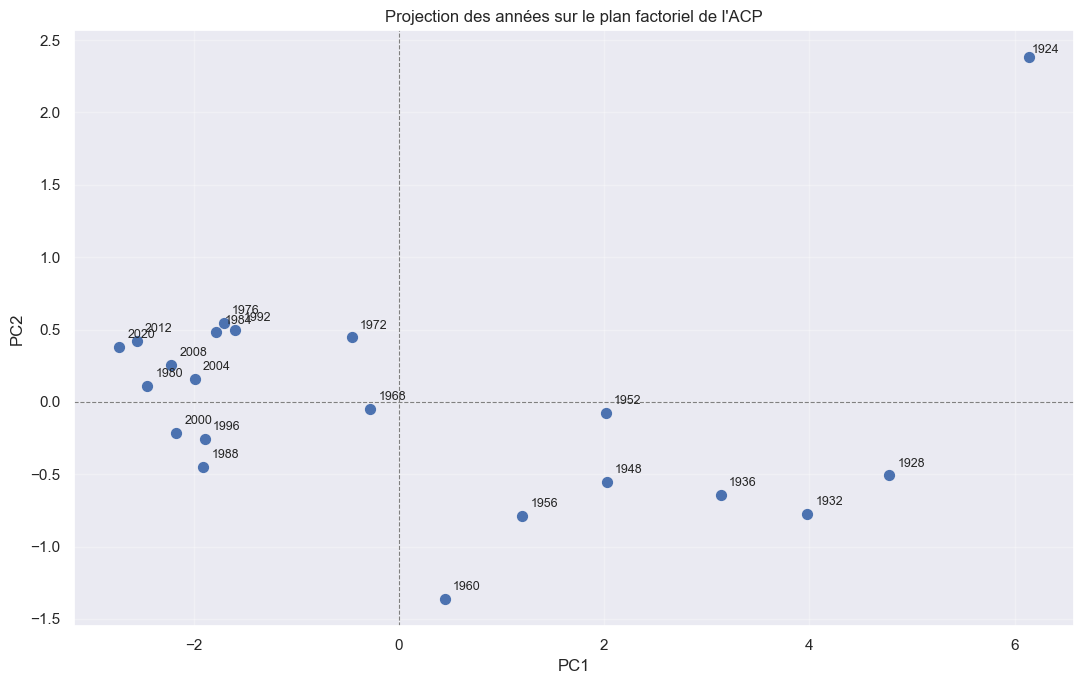

In [64]:
plt.figure(figsize=(11, 7))
plt.scatter(acp_results['PC1'], acp_results['PC2'], s=50) # trace les points du nuage ACP,en abscisse les coordonnées sur PC1, en ordonnée les coordonnées sur PC2

for _, row in acp_results.iterrows(): # row contient les valeurs de la ligne courante
    x = row['PC1'] # récupère la coordonnée sur le premier axe principal
    y = row['PC2']
    
    # petit décalage différent selon la position pour éviter les chevauchements
    dx = 0.08 if x < 5 else 0.03 # on choisit un léger décalage horizontal pour placer le texte
    # si le point est à gauche (x < 5), on décale un peu plus pour améliorer la lisibilité
    # sinon on met un décalage plus faible
    dy = 0.06 if y < 2 else 0.03

# ajoute une étiquette textuelle près du point
    plt.annotate(
        str(int(row['Year'])), # texte affiché : l'année convertie en entier puis en chaîne
        (x, y),
        xytext=(x + dx, y + dy), # position du texte légèrement décalée
        fontsize=9
    )

plt.title("Projection des années sur le plan factoriel de l'ACP")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True, alpha=0.3)
plt.axhline(0, color='grey', linewidth=0.8, linestyle='--')
plt.axvline(0, color='grey', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.show()

In [65]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=acp_data.columns,
    columns=[f'PC{i+1}' for i in range(len(acp_data.columns))]
)

loadings

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
Mean_100m_Backstroke,0.375738,-0.056517,-0.224283,-0.179425,0.028946,0.001485,0.145588,0.866657
Mean_100m_Freestyle,0.370687,-0.118377,-0.342783,-0.204744,0.013403,-0.185417,0.693807,-0.416210
Mean_200m_Breaststroke,0.372401,-0.005693,-0.304512,-0.233142,-0.043673,0.728174,-0.360585,-0.228113
Mean_400m_Freestyle,0.374747,-0.132759,-0.168764,-0.128421,0.032663,-0.644077,-0.601127,-0.140395
RelGap_100m_Backstroke,0.329742,-0.382242,0.763662,-0.277206,-0.277297,0.062734,0.059165,-0.028433
RelGap_100m_Freestyle,0.354492,0.214815,-0.041849,0.648890,-0.635970,-0.013973,0.026958,0.000566
RelGap_200m_Breaststroke,0.286557,0.851763,0.307677,-0.206689,0.219107,-0.060678,0.035752,-0.045078
RelGap_400m_Freestyle,0.354662,-0.217671,0.177177,0.560729,0.683117,0.112843,0.023554,-0.032984


L’ACP, mise en œuvre ici conformément aux méthodes vues dans le TP4, avait pour objectif de résumer simultanément plusieurs indicateurs de performance agrégés par année : les temps moyens du 100 m dos, du 100 m nage libre, du 200 m brasse et du 400 m nage libre, ainsi que les écarts relatifs femmes-hommes associés à ces épreuves. Le 200 m papillon a été exclu de cette analyse en raison d’un trop grand nombre de valeurs manquantes, qui empêchaient une ACP fiable sur l’ensemble de la période.

Les résultats montrent d’abord que cette représentation est très satisfaisante : le premier axe (PC1) explique à lui seul environ **86,7 %** de la variance totale, et les deux premiers axes en expliquent environ **93,5 %**. Le plan factoriel formé par PC1 et PC2 fournit donc une synthèse très fidèle de la structure des données.

L’interprétation des loadings montre que le premier axe est positivement lié à l’ensemble des variables étudiées : temps moyens et écarts relatifs évoluent dans le même sens sur cet axe. On peut donc interpréter PC1 comme un axe global opposant les années où les performances sont plus lentes et les écarts hommes/femmes plus élevés aux années où les temps sont plus faibles et les écarts relatifs plus réduits. Comme les années anciennes ont globalement des coordonnées positives sur cet axe, tandis que les années récentes se situent plutôt du côté négatif, PC1 peut être interprété comme un axe de progrès global des performances.

Le deuxième axe (PC2) joue un rôle plus secondaire. Il semble surtout distinguer certaines formes d’écarts relatifs entre épreuves, en particulier celui du 200 m brasse, qui contribue fortement positivement à cet axe. Il permet donc de différencier des années qui, à niveau global de performance comparable, se distinguent par la structure plus fine des écarts hommes/femmes selon les nages.

La projection des années sur le plan factoriel confirme cette lecture. Les années les plus anciennes, comme 1924, 1928, 1932 ou 1936, se situent nettement à droite du plan, ce qui traduit des temps plus élevés et des écarts plus importants. Les années plus récentes, comme 1988, 1996, 2000, 2008 ou 2012, se regroupent davantage à gauche, ce qui correspond à des performances plus rapides et à des écarts globalement plus faibles. On observe ainsi une structuration temporelle claire des données, même si certaines années anciennes, comme 1924, apparaissent particulièrement atypiques.

Ainsi, l’ACP ne remplace pas les analyses précédentes, mais elle en fournit une synthèse cohérente : elle confirme que les années olympiques s’organisent principalement selon un axe de progrès global, combinant amélioration des temps et réduction partielle des écarts relatifs entre hommes et femmes.

<a id='1-9'></a>
## Conclusion de la question 1

L’ensemble des méthodes mobilisées dans cette première partie permet de répondre de façon solide à la question de l’évolution des performances en natation olympique.

D’abord, les analyses descriptives et les courbes temporelles montrent que les temps baissent globalement au fil du temps, ce qui traduit une amélioration nette des performances. Cette baisse apparaît non seulement dans l’analyse globale, mais aussi, de manière plus rigoureuse, dans l’étude d’épreuves homogènes comme le 100m nage libre, le 100m dos, le 200m brasse, le 200m papillon et le 400m nage libre.

Ensuite, cette amélioration n’est pas exactement identique selon les épreuves. Les épreuves de 100m nage libre et 100m dos présentent une baisse très régulière sur le long terme. Le 200m brasse et le 400m nage libre montrent eux aussi une amélioration nette, mais avec des phases de ralentissement ou de stabilisation plus visibles dans les périodes récentes. Le 200m papillon, bien qu’en amélioration globale, suit une dynamique un peu plus courte et moins régulière.

Concernant l’écart entre hommes et femmes, les résultats sont plus nuancés. Les analyses graphiques, les écarts absolus, les écarts relatifs et les corrélations montrent qu’il existe bien un rapprochement des performances dans l’ensemble des épreuves étudiées, mais avec une intensité variable. Ce rapprochement est particulièrement net dans le 100m nage libreet le 100m dos, également visible dans le 200m brasse et le 400m nage libre, tandis qu’il apparaît plus limité et plus irrégulier dans le 200m papillon.

Enfin, les corrélations et l’ACP confirment quantitativement les tendances observées. Les corrélations négatives entre l’année et les temps moyens montrent une amélioration très forte dans toutes les nages retenues. L’ACP met en évidence un axe principal opposant clairement les années anciennes aux années récentes, ce qui confirme que l’évolution temporelle constitue bien la dimension dominante de cette partie du jeu de données.

On peut donc conclure que :
- les performances se sont nettement améliorées au fil du temps ;
- cette amélioration dépend de l’épreuve considérée ;
- l’écart hommes/femmes tend globalement à se réduire, mais ni avec la même ampleur ni avec la même régularité selon les nages.

Cette première partie apporte ainsi une réponse robuste à la problématique temporelle, tout en montrant que l’analyse doit rester fine et différenciée selon les épreuves.

<a id='q2'></a>
# Partie II — Question 2 : Existe-t-il des profils de pays en natation olympique ?

On veut répondre à :

- quels pays dominent ;
- quels pays sont réguliers sans forcément gagner beaucoup ;
- peut-on distinguer des groupes de nations.

On se donne en plan:

1. Construire proprement le tableau pays
2. Faire une analyse descriptive des pays
3. Choisir les variables pertinentes pour comparer les pays
4. ACP sur les pays 
5. Clustering hiérarchique 
6. K-means 
7. Comparer les groupes obtenus
8. Mini-conclusion 

À l’observation du jeu de données, on remarque que certains pays apparaissent sous plusieurs appellations selon les périodes historiques ou selon les codes utilisés. C’est notamment le cas de l’Allemagne, de la Russie au sens large, mais aussi des Pays-Bas.

Pour l’Allemagne, plusieurs codes sont présents :
- `GER`, qui désigne l’Allemagne ;
- `GDR`, qui correspond à la République démocratique allemande, c’est-à-dire l’Allemagne de l’Est ;
- `FRG`, qui correspond à la République fédérale d’Allemagne, c’est-à-dire l’Allemagne de l’Ouest.

Pour l’espace soviétique et russe, on rencontre également plusieurs dénominations :
- `URS`, pour l’Union soviétique ;
- `SUN` et `EUN`, qui renvoient à des équipes unifiées de la période de transition après la disparition de l’URSS ;
- `RUS`, pour la Russie ;
- `ROC`, utilisé plus récemment pour le Comité olympique russe.

Enfin, les Pays-Bas apparaissent sous deux codes différents :
- `NED`, ancien code couramment utilisé pour les Pays-Bas ;
- `NLD`, code également utilisé pour désigner les Pays-Bas.

Si l’on conserve ces appellations séparées, une même continuité sportive peut se retrouver artificiellement fragmentée en plusieurs pays distincts dans l’analyse. Je choisis donc d’harmoniser ces codes avant de construire le tableau agrégé.

In [66]:
df['Team'] = df['Team'].replace({
    # Allemagne
    'GER': 'Germany',
    'GDR': 'Germany',
    'FRG': 'Germany',

    # URSS / Russie
    'URS': 'Russia/USSR',
    'SUN': 'Russia/USSR',
    'EUN': 'Russia/USSR',
    'RUS': 'Russia/USSR',
    'ROC': 'Russia/USSR',

    # Pays-Bas
    'NED': 'Netherlands',
    'NLD': 'Netherlands'
})

<a id='2-1'></a>
### 2.1 — Construction du tableau pays
  
Ici, l’unité d’analyse n’est plus la performance individuelle ni l’année, mais le pays.

L’idée est de construire un tableau synthétique dans lequel :

- chaque ligne représente un pays ;
- chaque colonne correspond à un indicateur de performance, de présence ou de régularité.

Un tel tableau permettra ensuite de comparer les pays entre eux, puis d’appliquer des méthodes comme l’ACP ou le clustering.

On peut construire au minimum les variables suivantes :

- `Participations` : nombre total de lignes ou de participations associées au pays ;
- `Gold` : nombre total de médailles d’or ;
- `Silver` : nombre total de médailles d’argent ;
- `Bronze` : nombre total de médailles de bronze ;
- `Medals` : nombre total de médailles ;
- `Avg_rank` : rang moyen du pays ;
- `Years_present` : nombre d’années où le pays apparaît dans les données ;
- `Events_count` : nombre d’épreuves différentes disputées par le pays ;

Ces indicateurs permettent de décrire plusieurs dimensions du profil d’un pays :

- sa domination à travers le nombre de médailles, surtout d’or ;
- sa régularité à travers sa présence sur plusieurs années ;
- sa polyvalence à travers le nombre d’épreuves disputées ;
- son niveau moyen grâce au rang moyen.

L’objectif est donc de disposer d’un tableau pays suffisamment riche pour distinguer différents profils de nations en natation olympique.

In [67]:
country_stats = df.groupby('Team').agg(
    Participations=('Team', 'size'),
    Gold=('Gold', 'sum'),
    Silver=('Silver', 'sum'),
    Bronze=('Bronze', 'sum'),
    Medals=('Medals', 'sum'),
    Avg_rank=('Rank', 'mean'),
    Years_present=('Year', 'nunique'),
    Events_count=('Event', 'nunique')
).reset_index()

country_stats.head()

,Team,Participations,Gold,Silver,Bronze,Medals,Avg_rank,Years_present,Events_count
0,ALG,2,0,0,0,0,4.000000,1,2
1,ANZ,6,1,2,2,5,2.500000,1,3
2,ARG,14,1,1,1,3,3.571429,7,7
3,AUS,444,61,67,69,197,3.130631,25,17
4,AUT,13,0,2,1,3,3.615385,7,9


#### Ajout d'indicateurs relatifs

Les variables précédentes décrivent surtout le volume total : un pays très présent historiquement aura mécaniquement plus de participations et plus de médailles. Pour comparer plus finement les profils de pays, j'ajoute donc des indicateurs normalisés :
- `Medal_rate` : proportion de participations donnant une médaille ;
- `Gold_rate` : proportion de médailles d’or parmi les médailles obtenues ;
- `Medals_per_year` : nombre moyen de médailles par année de présence ;

In [68]:
# Indicateurs relatifs : ils permettent de ne pas mesurer uniquement le volume historique brut
country_stats['Medal_rate'] = country_stats['Medals'] / country_stats['Participations']

country_stats['Gold_rate'] = country_stats['Gold'] / country_stats['Medals'] #dans le cas de 0/0, cela renvoie nan
country_stats['Gold_rate'] = country_stats['Gold_rate'].fillna(0) #remplace les nan par des 0

country_stats['Medals_per_year'] = country_stats['Medals'] / country_stats['Years_present']

country_stats.head()

,Team,Participations,Gold,Silver,Bronze,Medals,Avg_rank,Years_present,Events_count,Medal_rate,Gold_rate,Medals_per_year
0,ALG,2,0,0,0,0,4.000000,1,2,0.000000,0.000000,0.000000
1,ANZ,6,1,2,2,5,2.500000,1,3,0.833333,0.200000,5.000000
2,ARG,14,1,1,1,3,3.571429,7,7,0.214286,0.333333,0.428571
3,AUS,444,61,67,69,197,3.130631,25,17,0.443694,0.309645,7.880000
4,AUT,13,0,2,1,3,3.615385,7,9,0.230769,0.000000,0.428571


In [69]:
country_stats.shape #78 pays sont représentés 
country_stats.describe()
country_stats.sort_values('Medals', ascending=False).reset_index().head(25) 
#on voit que les etats-unis sont très largement les premiers en nombres de medailles, la france est 12ème

,index,Team,Participations,Gold,Silver,Bronze,Medals,Avg_rank,Years_present,Events_count,Medal_rate,Gold_rate,Medals_per_year
0,71,USA,882,240,171,138,549,2.639456,24,18,0.622449,0.437158,22.875000
1,3,AUS,444,61,67,69,197,3.130631,25,17,0.443694,0.309645,7.880000
2,29,Germany,440,46,57,68,171,3.272727,22,18,0.388636,0.269006,7.772727
3,58,Russia/USSR,273,23,31,36,90,3.388278,17,17,0.329670,0.255556,5.294118
4,37,JPN,243,24,29,31,84,3.337449,21,17,0.345679,0.285714,4.000000
5,26,GBR,280,10,27,30,67,3.592857,25,18,0.239286,0.149254,2.680000
6,49,Netherlands,170,19,22,23,64,3.270588,22,16,0.376471,0.296875,2.909091
7,31,HUN,164,25,19,19,63,3.195122,23,15,0.384146,0.396825,2.739130
8,12,CAN,196,8,14,28,50,3.591837,21,16,0.255102,0.160000,2.380952
9,14,CHN,120,14,19,12,45,3.233333,9,17,0.375000,0.311111,5.000000


<a id='2-2'></a>
### 2.2 — Analyse descriptive des pays

#### graphiques descriptifs

on veut d abord comprendre quels pays dominent, sont reguliers, les variables les plus importantes 

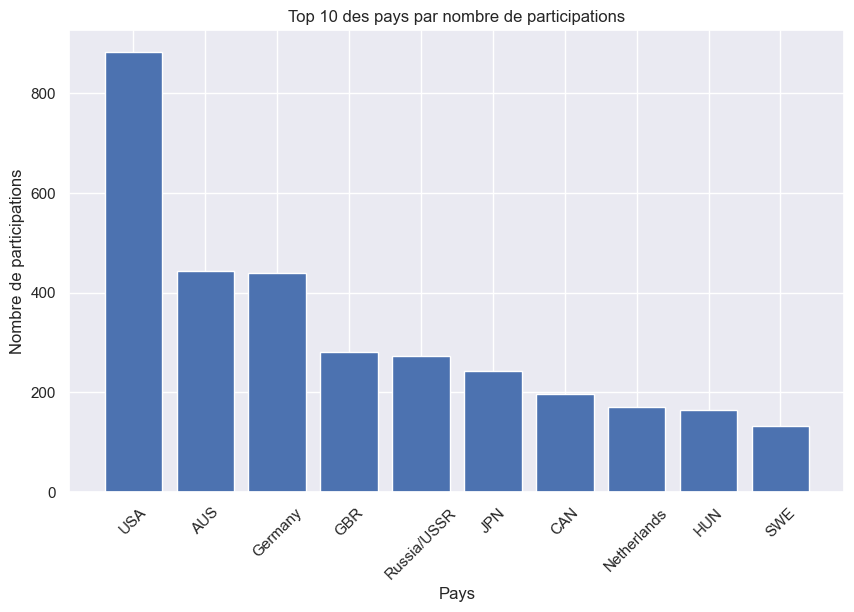

In [70]:
top10_part = country_stats.sort_values('Participations', ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.bar(top10_part['Team'], top10_part['Participations'])
plt.title("Top 10 des pays par nombre de participations")
plt.xlabel("Pays")
plt.ylabel("Nombre de participations")
plt.xticks(rotation=45)
plt.show()

In [71]:
country_stats.sort_values('Gold', ascending=False).reset_index().head(10)

,index,Team,Participations,Gold,Silver,Bronze,Medals,Avg_rank,Years_present,Events_count,Medal_rate,Gold_rate,Medals_per_year
0,71,USA,882,240,171,138,549,2.639456,24,18,0.622449,0.437158,22.875000
1,3,AUS,444,61,67,69,197,3.130631,25,17,0.443694,0.309645,7.880000
2,29,Germany,440,46,57,68,171,3.272727,22,18,0.388636,0.269006,7.772727
3,31,HUN,164,25,19,19,63,3.195122,23,15,0.384146,0.396825,2.739130
4,37,JPN,243,24,29,31,84,3.337449,21,17,0.345679,0.285714,4.000000
5,58,Russia/USSR,273,23,31,36,90,3.388278,17,17,0.329670,0.255556,5.294118
6,49,Netherlands,170,19,22,23,64,3.270588,22,16,0.376471,0.296875,2.909091
7,14,CHN,120,14,19,12,45,3.233333,9,17,0.375000,0.311111,5.000000
8,26,GBR,280,10,27,30,67,3.592857,25,18,0.239286,0.149254,2.680000
9,12,CAN,196,8,14,28,50,3.591837,21,16,0.255102,0.160000,2.380952


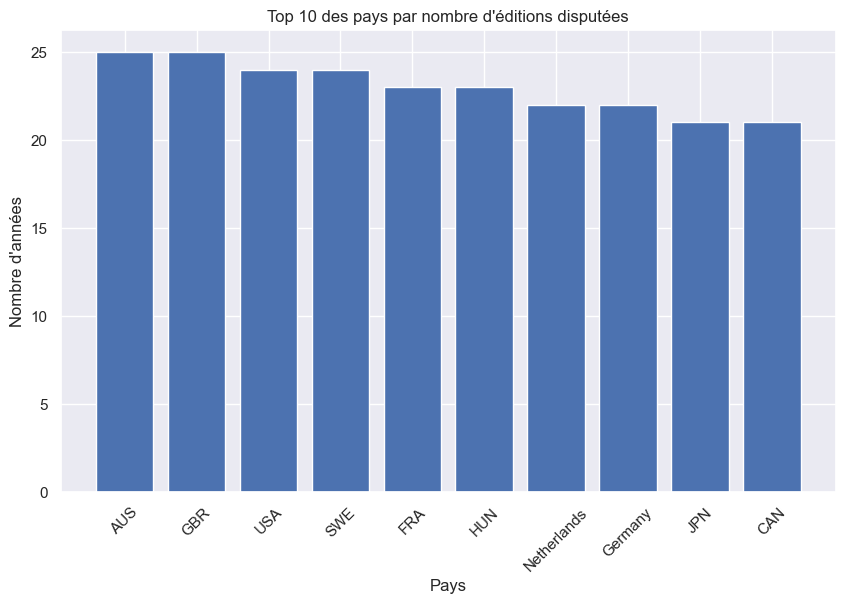

In [72]:
top10_years = country_stats.sort_values('Years_present', ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.bar(top10_years['Team'], top10_years['Years_present'])
plt.title("Top 10 des pays par nombre d'éditions disputées")
plt.xlabel("Pays")
plt.ylabel("Nombre d'années")
plt.xticks(rotation=45)
plt.show()
#on voit que chaque pays est a peu près present sur le meme nombre d'edition

In [73]:
country_stats.sort_values('Events_count', ascending=False).head(10)
#de même chaque pays participe a peu pres au meme nombre d'epreuves 

,Team,Participations,Gold,Silver,Bronze,Medals,Avg_rank,Years_present,Events_count,Medal_rate,Gold_rate,Medals_per_year
26,GBR,280,10,27,30,67,3.592857,25,18,0.239286,0.149254,2.680000
29,Germany,440,46,57,68,171,3.272727,22,18,0.388636,0.269006,7.772727
71,USA,882,240,171,138,549,2.639456,24,18,0.622449,0.437158,22.875000
25,FRA,131,8,14,16,38,3.480916,23,17,0.290076,0.210526,1.652174
3,AUS,444,61,67,69,197,3.130631,25,17,0.443694,0.309645,7.880000
14,CHN,120,14,19,12,45,3.233333,9,17,0.375000,0.311111,5.000000
58,Russia/USSR,273,23,31,36,90,3.388278,17,17,0.329670,0.255556,5.294118
37,JPN,243,24,29,31,84,3.337449,21,17,0.345679,0.285714,4.000000
35,ITA,120,5,5,14,24,3.675000,17,17,0.200000,0.208333,1.411765
65,SWE,132,6,15,17,38,3.507576,24,17,0.287879,0.157895,1.583333


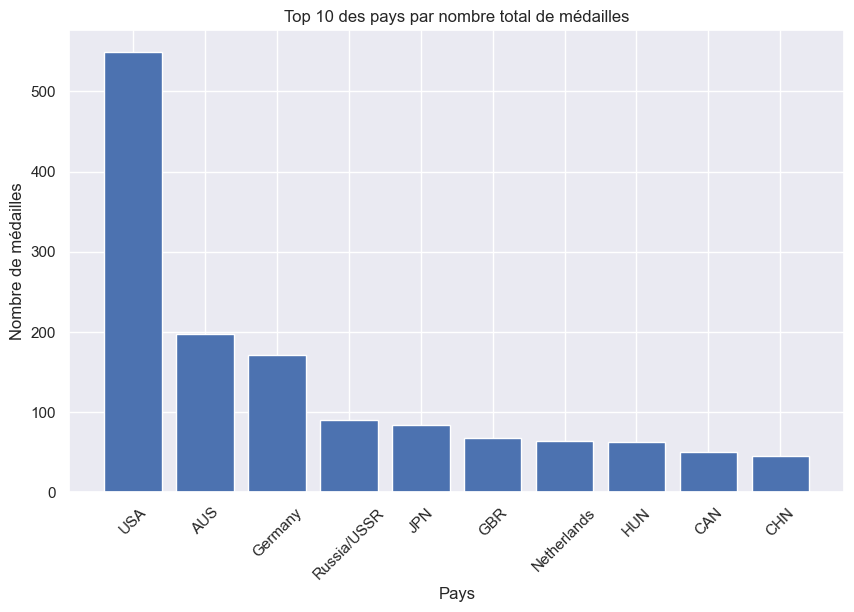

In [74]:
top10_medals = country_stats.sort_values('Medals', ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.bar(top10_medals['Team'], top10_medals['Medals'])
plt.title("Top 10 des pays par nombre total de médailles")
plt.xlabel("Pays")
plt.ylabel("Nombre de médailles")
plt.xticks(rotation=45)
plt.show()

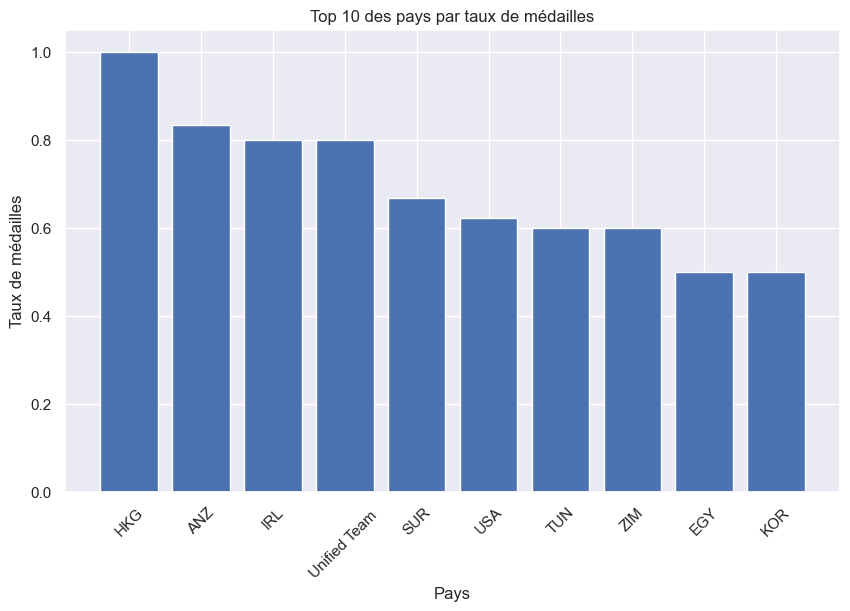

In [75]:
# Top 10 des pays selon le taux de médailles
top10_medal_rate = country_stats.sort_values('Medal_rate', ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.bar(top10_medal_rate['Team'], top10_medal_rate['Medal_rate'])
plt.title("Top 10 des pays par taux de médailles")
plt.xlabel("Pays")
plt.ylabel("Taux de médailles")
plt.xticks(rotation=45)
plt.show()

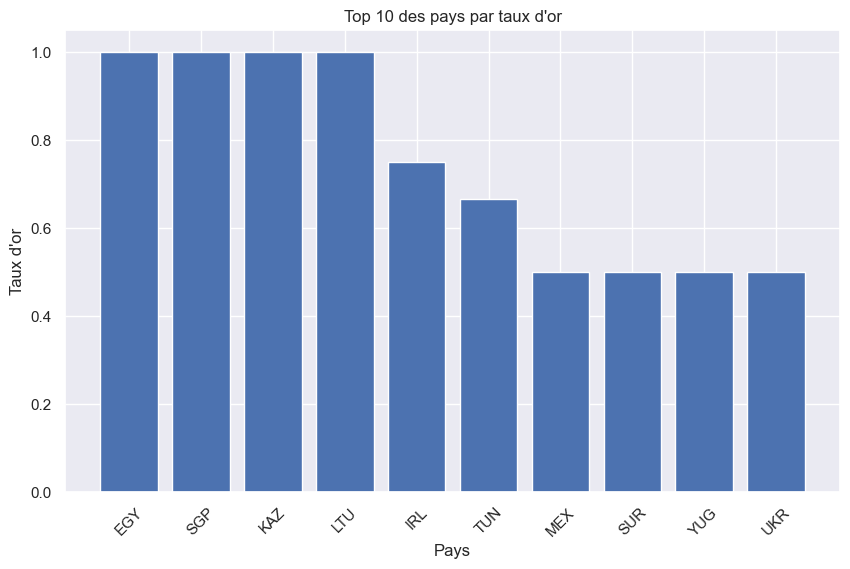

In [76]:
# Top 10 des pays selon le taux d'or
top10_gold_rate = country_stats.sort_values('Gold_rate', ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.bar(top10_gold_rate['Team'], top10_gold_rate['Gold_rate'])
plt.title("Top 10 des pays par taux d'or")
plt.xlabel("Pays")
plt.ylabel("Taux d'or")
plt.xticks(rotation=45)
plt.show()

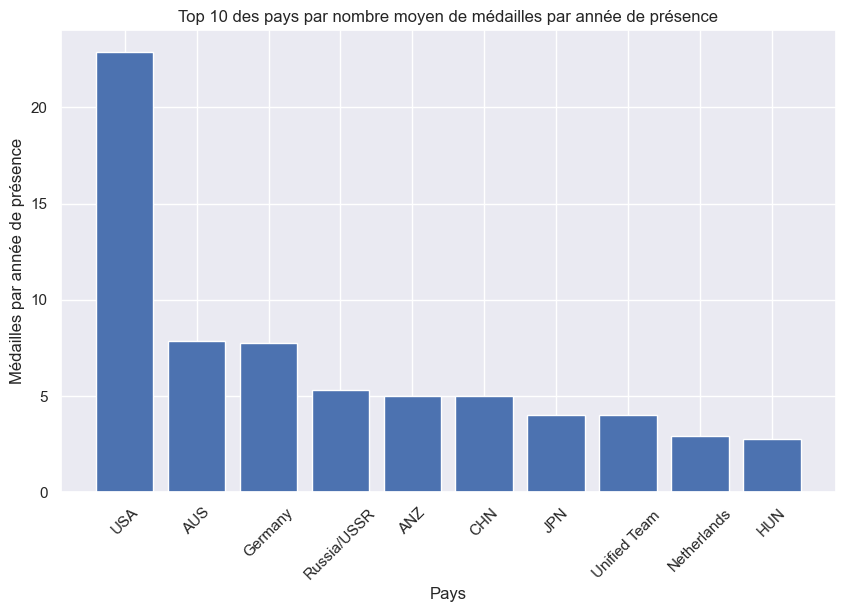

In [77]:
# Top 10 des pays selon le nombre moyen de médailles par année de présence
top10_medals_per_year = country_stats.sort_values('Medals_per_year', ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.bar(top10_medals_per_year['Team'], top10_medals_per_year['Medals_per_year'])
plt.title("Top 10 des pays par nombre moyen de médailles par année de présence")
plt.xlabel("Pays")
plt.ylabel("Médailles par année de présence")
plt.xticks(rotation=45)
plt.show()

Les graphiques descriptifs mettent en évidence une forte concentration des performances sur un petit nombre de pays.

D’abord, les **États-Unis** dominent très nettement l’ensemble des classements fondés sur les volumes bruts. Ils apparaissent à la fois comme le pays le plus représenté en nombre de participations et comme celui qui possède de très loin le plus grand nombre de médailles. L’écart avec les autres nations est particulièrement marqué, ce qui confirme une situation de surreprésentation qu’il faudra garder en tête pour les analyses multivariées suivantes.

L’**Australie** occupe ensuite une place majeure, mais reste nettement derrière les États-Unis. L’harmonisation des appellations historiques fait également apparaître plus clairement le poids de l’**Allemagne** et de l’ensemble **Russie/URSS**, qui figurent désormais parmi les nations les plus importantes du tableau descriptif. Ce regroupement montre que, sur le long terme, ces espaces sportifs ont accumulé un volume élevé de participations et de médailles, comparable à celui des autres grandes puissances historiques de la natation olympique.

D’autres pays comme le **Japon**, la **Grande-Bretagne**, la **Hongrie**, le **Canada** ou les **Pays-Bas** apparaissent aussi régulièrement parmi les nations les plus performantes ou les plus présentes, mais à des niveaux inférieurs à ceux des tout premiers pays.

L’observation des indicateurs relatifs permet cependant de nuancer cette première hiérarchie. Le **taux de médailles** fait apparaître en tête certains pays ou équipes comme **Hong Kong**, **Australasie**, **Irlande**, **Équipe unifiée**, **Suriname**, **États-Unis**, **Tunisie**, **Zimbabwe**, **Égypte** ou **Singapour**. Ces pays ont une proportion élevée de médailles par rapport à leur nombre total de participations dans le jeu de données. Cela ne signifie pas nécessairement qu’ils dominent historiquement la natation olympique : pour certains d’entre eux, le nombre d’observations est plus faible, donc quelques bonnes performances peuvent fortement augmenter le taux.

Le même phénomène apparaît avec le **taux d’or**. Des pays comme **Lituanie**, **Égypte**, **Singapour**, **Kazakhstan**, **Irlande**, **Tunisie**, **Suriname**, **Mexique**, **Ukraine** ou **Yougoslavie** ressortent dans le top 10. Ce classement indique que, parmi leurs médailles, une part importante correspond à des médailles d’or. Là encore, l’interprétation doit être prudente : un pays ayant remporté peu de médailles peut obtenir un taux d’or très élevé si la majorité de ces médailles sont des titres olympiques. Ces indicateurs sont donc intéressants pour mesurer l’efficacité relative, mais ils sont sensibles aux petits effectifs.

Il faut aussi tenir compte de la structure du jeu de données. Celui-ci contient les résultats olympiques disponibles pour les épreuves de natation, mais il ne représente pas forcément de manière parfaitement homogène tous les pays, toutes les périodes et tous les types de performances. Certaines nations ont beaucoup plus d’observations car elles participent à davantage d’épreuves, sur davantage d’éditions, ou parce qu’elles qualifient plus souvent plusieurs nageurs. Les indicateurs relatifs permettent donc de corriger partiellement l’effet de volume, mais ils ne suppriment pas totalement les biais liés au nombre d’observations disponibles.

Enfin, le graphique du **nombre moyen de médailles par année de présence** remet en avant les grandes puissances historiques. Les **États-Unis** dominent très largement, suivis notamment par l’**Australie**, l’**Allemagne**, la **Russie/URSS**, la **Chine**, **ANZ**, le **Japon**, la **Hongrie** ou la **Grande-Bretagne**. Ce résultat est cohérent avec les observations précédentes : on a vu que les grands pays participent à de nombreuses épreuves lors des éditions où ils sont présents, et que les pays les plus installés ont souvent un nombre assez comparable d’éditions différentes disputées. Ainsi, lorsqu’on rapporte les médailles au nombre d’années de présence, les pays capables d’obtenir beaucoup de médailles à chaque édition restent naturellement en tête.

Ainsi, cette exploration descriptive fait déjà apparaître plusieurs types de profils :
- des pays très dominants à la fois en présence et en médailles, comme les États-Unis ;
- des pays historiquement très puissants et réguliers, comme l’Australie, l’Allemagne ou l’ensemble Russie/URSS ;
- des pays très présents sur la durée, comme la Grande-Bretagne ou la Suède ;
- des pays solides mais à un niveau légèrement inférieur, comme le Japon, la Hongrie, le Canada ou les Pays-Bas ;
- des pays dont les indicateurs relatifs sont élevés, mais pour lesquels l’interprétation doit rester prudente en raison d’un nombre plus faible d’observations.

Ces constats justifient la suite de l’analyse : il faudra utiliser des méthodes permettant de dépasser les simples classements bruts, afin d’identifier plus finement des profils de nations en tenant compte à la fois de la domination, de la régularité, de la diversité de présence et de l’efficacité relative.

#### Distribution des variables

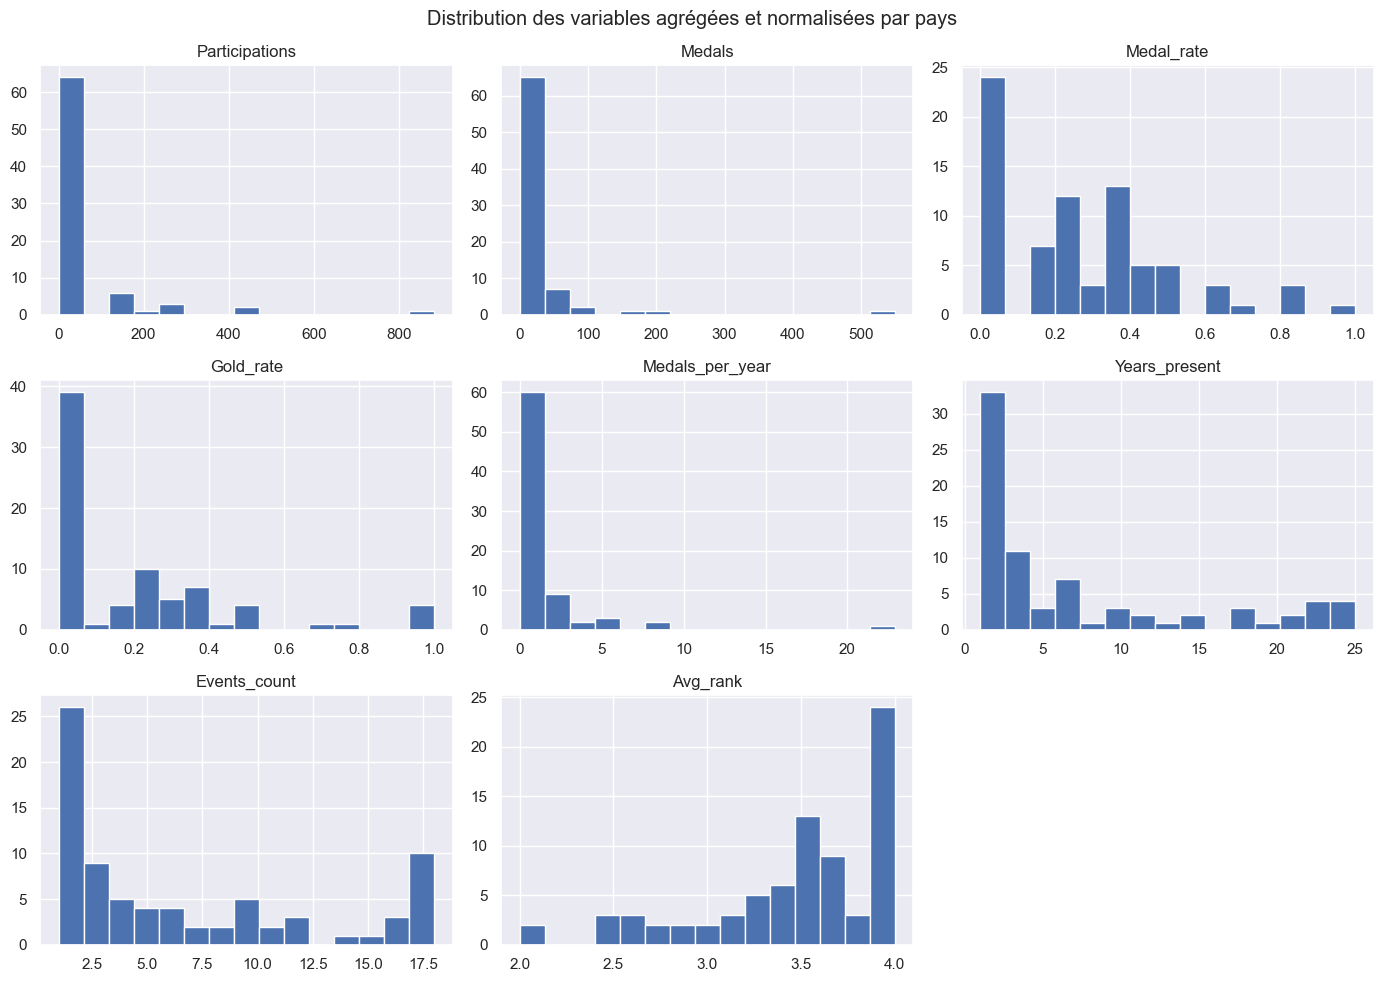

In [78]:
country_stats[[
    'Participations', 'Medals', 'Medal_rate', 'Gold_rate',
    'Medals_per_year',
    'Years_present', 'Events_count', 'Avg_rank'
]].hist(
    figsize=(14,10),
    bins=15
)
plt.suptitle("Distribution des variables agrégées et normalisées par pays")
plt.tight_layout()
plt.show()


L’examen des distributions des variables agrégées par pays montre que les données sont très asymétriques et marquées par la présence de quelques nations dominantes.

Les variables `Participations`, `Medals` et `Gold` sont très concentrées sur les petites valeurs, avec une longue queue vers la droite. Cela signifie que la plupart des pays ont peu de participations et peu de médailles, tandis qu’un petit nombre de nations en accumulent beaucoup. Ces variables mesurent donc surtout un effet de volume historique.

La variable `Medal_rate` apporte une information différente, puisqu’elle rapporte le nombre de médailles au nombre de participations. Sa distribution est moins directement liée au volume total, mais elle reste assez dispersée : certains pays ont un taux élevé, souvent parce qu’ils ont peu d’observations dans le jeu de données mais plusieurs performances médaillées.

La variable `Gold_rate` est également très particulière. Beaucoup de pays ont une valeur proche de 0, car ils n’ont pas remporté de médaille d’or ou très peu de médailles au total. À l’inverse, quelques pays ont un taux élevé, parfois proche de 1, ce qui signifie que leurs médailles sont majoritairement des médailles d’or. Cette variable doit donc être interprétée avec prudence, car elle est très sensible aux petits effectifs.

La variable `Medals_per_year` reste elle aussi très asymétrique. La plupart des pays remportent peu de médailles par année de présence, tandis que quelques grandes nations se détachent fortement. Elle permet donc de mesurer non seulement la présence historique, mais aussi la capacité moyenne à obtenir des médailles lors des éditions disputées.

La variable `Years_present` est dispersée, mais un peu moins fortement que les variables de volume. Elle permet de distinguer les pays présents sur peu d’éditions de ceux qui reviennent régulièrement au fil du temps.

La variable `Events_count` montre aussi des écarts importants entre pays. Certains n’ont participé qu’à très peu d’épreuves, alors que d’autres couvrent un grand nombre de nages et de distances.

Enfin, la variable `Avg_rank` est plus resserrée que les autres. Elle varie moins fortement, mais elle apporte une information différente, davantage liée au niveau moyen des performances qu’au volume de participation ou de médailles.

Dans l’ensemble, ces histogrammes montrent que les variables n’ont ni la même échelle ni la même forme. Les variables brutes décrivent surtout la domination historique et le volume de présence, tandis que les variables relatives permettent de nuancer cette lecture en introduisant des notions d’efficacité. Cela justifie l’utilisation d’une standardisation avant les méthodes multivariées comme l’ACP, la CAH ou le K-means. Ces distributions rappellent aussi que les résultats peuvent être fortement influencés par quelques pays très dominants ou, au contraire, par certains pays ayant peu d’observations mais des ratios élevés.

#### Corrélation des variables

In [79]:
country_corr = country_stats[['Participations', 'Gold', 'Silver', 'Bronze', 'Medals',
                              'Avg_rank', 'Years_present', 'Events_count', 'Medals_per_year', 'Gold_rate', 'Medal_rate']].corr()
country_corr

,Participations,Gold,Silver,Bronze,Medals,Avg_rank,Years_present,Events_count,Medals_per_year,Gold_rate,Medal_rate
Participations,1.000000,0.899837,0.969527,0.994077,0.961473,-0.216068,0.730065,0.679793,0.921011,0.155854,0.233139
Gold,0.899837,1.000000,0.974268,0.923502,0.983911,-0.243183,0.465200,0.420883,0.944067,0.162395,0.235343
Silver,0.969527,0.974268,1.000000,0.981032,0.997975,-0.246082,0.591055,0.542966,0.962116,0.146646,0.253128
Bronze,0.994077,0.923502,0.981032,1.000000,0.976532,-0.225074,0.681267,0.624323,0.935394,0.147586,0.243898
Medals,0.961473,0.983911,0.997975,0.976532,1.000000,-0.242328,0.573436,0.523696,0.960501,0.155417,0.246730
Avg_rank,-0.216068,-0.243183,-0.246082,-0.225074,-0.242328,1.000000,-0.112716,-0.135056,-0.413850,-0.654832,-0.952416
Years_present,0.730065,0.465200,0.591055,0.681267,0.573436,-0.112716,1.000000,0.937215,0.520163,0.162838,0.168016
Events_count,0.679793,0.420883,0.542966,0.624323,0.523696,-0.135056,0.937215,1.000000,0.513036,0.186906,0.187633
Medals_per_year,0.921011,0.944067,0.962116,0.935394,0.960501,-0.413850,0.520163,0.513036,1.000000,0.209814,0.432111
Gold_rate,0.155854,0.162395,0.146646,0.147586,0.155417,-0.654832,0.162838,0.186906,0.209814,1.000000,0.471269


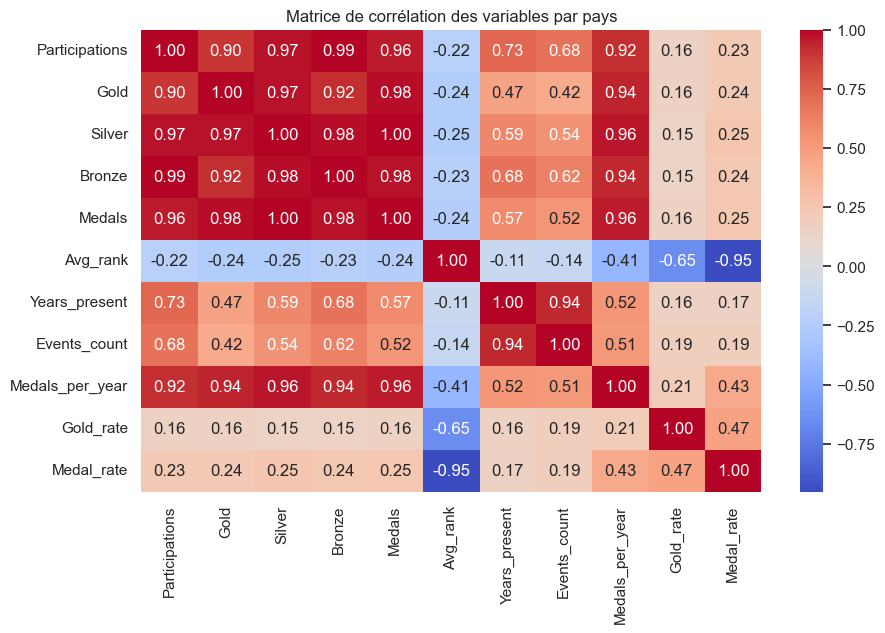

In [80]:
plt.figure(figsize=(10,6))
sns.heatmap(country_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Matrice de corrélation des variables par pays")
plt.show()

La matrice de corrélation met en évidence plusieurs relations fortes entre les variables agrégées par pays.

D’abord, les variables liées aux médailles, comme `Gold`, `Silver`, `Bronze` et `Medals`, sont très fortement corrélées entre elles. Cela signifie qu’un pays qui gagne beaucoup de médailles d’or gagne en général aussi beaucoup de médailles d’argent et de bronze, et cumule donc un grand nombre total de médailles. La variable `Participations` est elle aussi fortement corrélée à ces variables, ce qui montre qu’un pays très présent dans les compétitions olympiques obtient souvent davantage de récompenses.

La variable `Medals_per_year` est également très corrélée aux variables de médailles. Cela confirme que les pays qui accumulent beaucoup de médailles au total sont aussi ceux qui en gagnent beaucoup en moyenne par année de présence. Cet indicateur reste donc lié à la domination globale, même s’il rapporte les médailles au nombre d’années où le pays apparaît dans le jeu de données.

Les variables `Years_present` et `Events_count` sont aussi fortement corrélées. Cela suggère qu’un pays présent sur un grand nombre d’éditions participe généralement à une plus grande diversité d’épreuves. Ces deux variables décrivent donc plutôt la régularité historique et l’étendue de la présence olympique.

La variable `Avg_rank` se distingue davantage des autres. Elle est négativement corrélée aux variables de participations et de médailles, ce qui est logique : plus un pays est performant, plus son rang moyen tend à être faible. Cette relation est particulièrement marquée avec `Medal_rate`, car un bon taux de médailles correspond naturellement à un meilleur classement moyen. Elle est aussi négative avec `Gold_rate`, ce qui indique que les pays dont les médailles sont souvent des titres olympiques ont généralement un rang moyen plus faible.

Les variables relatives `Medal_rate` et `Gold_rate` apportent donc une information complémentaire. Elles ne sont que faiblement corrélées aux variables brutes de volume comme `Participations`, `Medals` ou `Years_present`, ce qui montre qu’elles ne mesurent pas exactement la même chose. Elles permettent davantage d’évaluer l’efficacité relative des pays, même si leur interprétation doit rester prudente pour les pays ayant peu d’observations.

Dans l’ensemble, cette matrice montre que certaines variables sont partiellement redondantes, surtout celles liées au nombre de médailles et au volume de participation. À l’inverse, des variables comme `Avg_rank`, `Medal_rate`, `Gold_rate`, `Years_present` et `Events_count` apportent une information complémentaire sur la qualité moyenne, l’efficacité relative, la régularité et la diversité de présence.

### Conclusion de la sous-partie descriptive sur les pays

Cette première exploration descriptive met en évidence une structure très inégale du jeu de données. Quelques nations dominent très nettement, en particulier les États-Unis, qui se distinguent à la fois par leur nombre de participations, leur total de médailles et leur nombre moyen de médailles par année de présence. D’autres pays apparaissent aussi comme des acteurs majeurs, comme l’Australie, le Japon, l’Allemagne, l’ensemble Russie/URSS, la Grande-Bretagne ou la Hongrie, mais à un niveau inférieur.

L’analyse montre aussi qu’il existe plusieurs dimensions pour décrire le profil d’un pays : `Participations`, `Medals`, `Years_present`, `Events_count`, mais aussi les indicateurs relatifs `Medal_rate`, `Gold_rate` et `Medals_per_year`. Ces derniers permettent de nuancer les classements bruts en mesurant davantage l’efficacité relative des pays. Cependant, ils doivent être interprétés avec prudence, car certains pays ayant peu d’observations peuvent obtenir des taux très élevés.

La matrice de corrélation confirme que certaines variables sont très proches, en particulier celles liées aux différentes médailles et au volume global de participation. À l’inverse, les variables relatives et le rang moyen apportent une information complémentaire sur la qualité moyenne des performances et le rendement sportif.

Enfin, la forte asymétrie des distributions et la surreprésentation de quelques pays montrent que les classements bruts ne suffisent pas pour identifier proprement des profils de nations. Il faudra donc construire une analyse plus synthétique, en sélectionnant les variables les plus pertinentes puis en utilisant des méthodes comme l’ACP et le clustering pour faire apparaître des groupes de pays comparables.

<a id='2-3'></a>
### 2.3 — Choix des variables pour l'analyse multivariée


On vient d'observer que les variables liées aux médailles brutes sont très corrélées entre elles. Si on garde uniquement ces variables, l'ACP et le clustering risquent d'être dominés par le simple volume historique, en particulier par les pays surreprésentés comme les États-Unis.

L'idée est donc de garder à la fois :

- des variables de volume et de présence : `Participations`, `Medals`, `Years_present`, `Events_count` ;
- une variable de qualité moyenne : `Avg_rank` ;
- des variables d'efficacité relative : `Medal_rate`, `Gold_rate`, `Medals_per_year` ;

Ce choix rend l’analyse multivariée plus intéressante, car elle ne compare pas seulement les pays qui ont accumulé le plus de médailles, mais aussi ceux qui sont efficaces relativement à leur nombre de participations ou à leur nombre d’années de présence.


In [81]:
country_acp = country_stats[[
    'Team',
    'Participations',
    'Medals',
    'Avg_rank',
    'Years_present',
    'Events_count',
    'Medal_rate',
    'Gold_rate',
    'Medals_per_year'
]].copy()

# On utilise ici `.copy()` pour créer un nouveau tableau indépendant à partir des colonnes sélectionnées de `country_stats`.
# Cela permet de travailler ensuite sur `country_acp` sans modifier accidentellement le tableau d’origine.
country_acp.head()


,Team,Participations,Medals,Avg_rank,Years_present,Events_count,Medal_rate,Gold_rate,Medals_per_year
0,ALG,2,0,4.000000,1,2,0.000000,0.000000,0.000000
1,ANZ,6,5,2.500000,1,3,0.833333,0.200000,5.000000
2,ARG,14,3,3.571429,7,7,0.214286,0.333333,0.428571
3,AUS,444,197,3.130631,25,17,0.443694,0.309645,7.880000
4,AUT,13,3,3.615385,7,9,0.230769,0.000000,0.428571


In [82]:
country_acp.shape

(77, 9)

Afin de rendre l’analyse multivariée plus stable, je retire ici les pays présents sur moins de trois éditions olympiques. En effet, un pays observé seulement une ou deux fois apporte peu d’information sur le long terme et peut introduire du bruit dans l’ACP comme dans les méthodes de clustering.

L’objectif de ce filtrage n’est donc pas d’exclure arbitrairement certains pays, mais de se concentrer sur des profils nationaux suffisamment documentés pour que les comparaisons statistiques aient du sens.

In [83]:
country_acp_filtered = country_acp[country_acp['Years_present'] >= 3].reset_index().copy()
country_acp_filtered.shape

(44, 10)

In [84]:
country_acp_filtered

,index,Team,Participations,Medals,Avg_rank,Years_present,Events_count,Medal_rate,Gold_rate,Medals_per_year
0,2,ARG,14,3,3.571429,7,7,0.214286,0.333333,0.428571
1,3,AUS,444,197,3.130631,25,17,0.443694,0.309645,7.880000
2,4,AUT,13,3,3.615385,7,9,0.230769,0.000000,0.428571
3,7,BEL,24,4,3.666667,11,10,0.166667,0.250000,0.363636
4,9,BLR,9,3,3.444444,6,5,0.333333,0.000000,0.500000
5,10,BRA,59,14,3.661017,19,16,0.237288,0.071429,0.736842
6,11,BUL,7,3,3.142857,3,5,0.428571,0.333333,1.000000
7,12,CAN,196,50,3.591837,21,16,0.255102,0.160000,2.380952
8,14,CHN,120,45,3.233333,9,17,0.375000,0.311111,5.000000
9,16,CRC,9,4,3.222222,5,6,0.444444,0.250000,0.800000


In [85]:
excluded_countries = np.array(country_acp[country_acp['Years_present'] < 3]['Team'])
excluded_countries[:20], len(excluded_countries)
#on affiche tous les pays sous-représentés

(array(['ALG', 'ANZ', 'BAH', 'BAR', 'BGR', 'CHE', 'COL', 'CRO', 'CZE',
        'ECU', 'EGY', 'GRE', 'GUA', 'HKG', 'IRL', 'ISL', 'KAZ', 'KEN',
        'LUX', 'MDA'], dtype=object),
 33)

On construit ici le tableau `X_country`, qui servira de base aux méthodes quantitatives de la suite, comme l’ACP, la classification hiérarchique et le K-means.

L’idée est de ne conserver que les variables numériques décrivant le profil de chaque pays. On retire donc la colonne `Team`, qui contient uniquement le nom du pays et n’a pas de sens dans ces méthodes. On supprime aussi d’éventuelles colonnes techniques ou parasites, comme `level_0` ou `index`, qui pourraient provenir d’étapes précédentes de manipulation du tableau.

Ainsi, `X_country` contient uniquement les variables quantitatives utiles pour l’analyse, tandis que `country_acp_filtered` permet de conserver la correspondance avec les noms des pays pour l’interprétation des résultats.

In [86]:
X_country = country_acp_filtered.drop(columns=['Team'], errors='ignore').copy()

X_country = X_country.drop(columns=['level_0', 'index'], errors='ignore')

X_country 

,Participations,Medals,Avg_rank,Years_present,Events_count,Medal_rate,Gold_rate,Medals_per_year
0,14,3,3.571429,7,7,0.214286,0.333333,0.428571
1,444,197,3.130631,25,17,0.443694,0.309645,7.880000
2,13,3,3.615385,7,9,0.230769,0.000000,0.428571
3,24,4,3.666667,11,10,0.166667,0.250000,0.363636
4,9,3,3.444444,6,5,0.333333,0.000000,0.500000
5,59,14,3.661017,19,16,0.237288,0.071429,0.736842
6,7,3,3.142857,3,5,0.428571,0.333333,1.000000
7,196,50,3.591837,21,16,0.255102,0.160000,2.380952
8,120,45,3.233333,9,17,0.375000,0.311111,5.000000
9,9,4,3.222222,5,6,0.444444,0.250000,0.800000


On standardise les valeurs : 

In [87]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_country_scaled = scaler.fit_transform(X_country)

<a id='2-4'></a>
### 2.4 — ACP sur les pays


Ici, on veut voir si les pays s’organisent selon quelques grandes dimensions :

- domination sportive ;
- régularité dans le temps ;
- diversité des épreuves ;
- qualité moyenne.

L’ACP va permettre :

- de résumer les variables choisies ;
- de visualiser les pays dans un plan factoriel ;
- de repérer des profils proches ou très différents.

In [88]:
from sklearn.decomposition import PCA

pca_country = PCA()
country_coord = pca_country.fit_transform(X_country_scaled)

In [89]:
pca_country.explained_variance_ratio_

array([5.52407515e-01, 2.48804105e-01, 1.10087349e-01, 6.96576080e-02,
       1.25039418e-02, 3.87992893e-03, 2.23992149e-03, 4.19631218e-04])

In [90]:
explained_var_country = pd.DataFrame({
    'Axe': [f'PC{i+1}' for i in range(len(pca_country.explained_variance_ratio_))],
    'Variance expliquée': pca_country.explained_variance_ratio_,
    'Variance cumulée': pca_country.explained_variance_ratio_.cumsum()
})

explained_var_country

,Axe,Variance expliquée,Variance cumulée
0,PC1,0.552408,0.552408
1,PC2,0.248804,0.801212
2,PC3,0.110087,0.911299
3,PC4,0.069658,0.980957
4,PC5,0.012504,0.993461
5,PC6,0.003880,0.997340
6,PC7,0.002240,0.999580
7,PC8,0.000420,1.000000


les deux premiers axes résument environ **80 %** de la variance totale. Le plan formé par **PC1** et **PC2** fournit donc déjà une représentation assez riche de la structure des données.

In [91]:
country_names = country_acp_filtered['Team'].reset_index(drop=True)

pca_results_country = pd.DataFrame(
    country_coord[:, :2],
    columns=['PC1', 'PC2']
)

pca_results_country['Team'] = country_names
pca_results_country

,PC1,PC2,Team
0,-1.134932,-0.272524,ARG
1,4.101002,0.512479,AUS
2,-1.303235,0.543205,AUT
3,-0.993546,0.615367,BEL
4,-1.247798,-0.403063,BLR
5,-0.095354,1.578082,BRA
6,-0.609094,-1.999800,BUL
7,0.914427,1.503949,CAN
8,1.177790,-0.322360,CHN
9,-0.580559,-1.593467,CRC


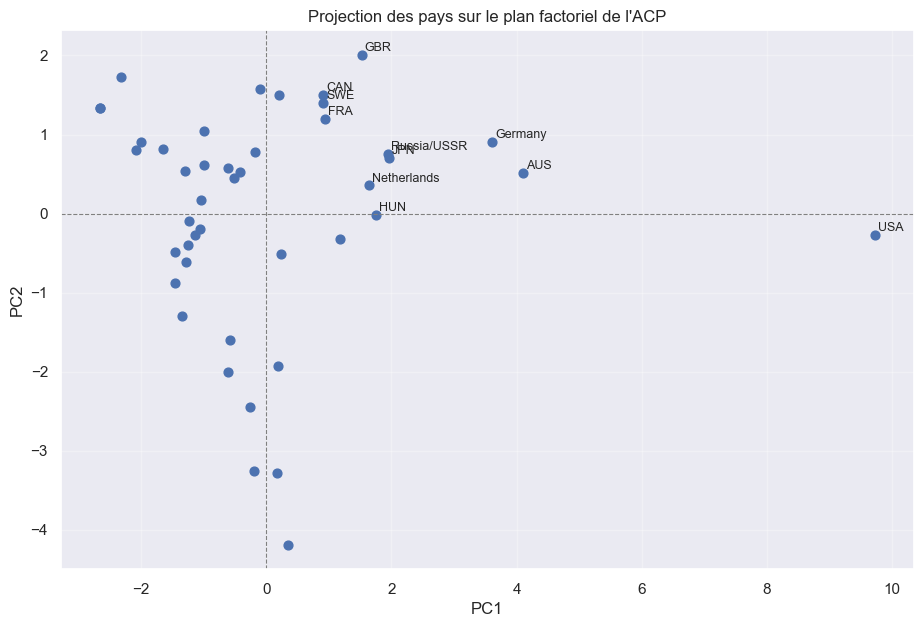

In [92]:
plt.figure(figsize=(11, 7))
plt.scatter(pca_results_country['PC1'], pca_results_country['PC2'], s=40)

# parcourt les lignes du tableau une par une
for _, row in pca_results_country.iterrows(): #_ contient les numero de ligne, row contient les valeurs des lignes
    if row['Team'] in ['USA', 'AUS', 'JPN', 'Germany', 'GBR', 'HUN', 'CAN', 'FRA', 'SWE', 'Russia/USSR', 'Netherlands']:
        plt.annotate(row['Team'], (row['PC1'], row['PC2']), xytext=(row['PC1']+0.05, row['PC2']+0.05), fontsize=9)

plt.title("Projection des pays sur le plan factoriel de l'ACP")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
plt.axvline(0, color='grey', linestyle='--', linewidth=0.8)
plt.grid(True, alpha=0.3)
plt.show()

#Deux pays proches sur le graphe ont des profils assez similaires sur les variables retenues.

In [93]:
loadings_country = pd.DataFrame(
    pca_country.components_.T,
    index=X_country.columns,
    columns=[f'PC{i+1}' for i in range(len(X_country.columns))]
)

loadings_country

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
Participations,0.449876,0.157745,-0.186916,0.138613,-0.144636,0.021142,0.834540,-0.027455
Medals,0.436546,0.070569,-0.341319,0.267126,-0.103164,-0.008775,-0.408929,-0.662307
Avg_rank,-0.289278,0.538656,-0.070940,0.233503,-0.063509,0.749282,-0.030012,0.015955
Years_present,0.340203,0.362756,0.384126,-0.308392,-0.652146,-0.064873,-0.220199,0.178946
Events_count,0.322936,0.382395,0.449145,-0.200351,0.692248,0.017042,0.001536,-0.167674
Medal_rate,0.280706,-0.487114,-0.081797,-0.538577,0.008205,0.620231,-0.004013,-0.048967
Gold_rate,0.171270,-0.404956,0.615564,0.611083,-0.082116,0.217999,0.001106,0.008197
Medals_per_year,0.441817,0.029972,-0.329602,0.237007,0.230419,0.036661,-0.294809,0.705507


L’**ACP** réalisée sur les pays repose désormais sur des variables standardisées décrivant à la fois le volume historique (`Participations`, `Medals`), la régularité (`Years_present`), la diversité (`Events_count`), la qualité moyenne (`Avg_rank`) et l’efficacité relative (`Medal_rate`, `Gold_rate`, `Medals_per_year`).

Les résultats montrent que le **premier axe (PC1)** explique environ **55,2 %** de la variance totale, et le **deuxième axe (PC2)** environ **24,8 %**. Les deux premiers axes résument donc à eux seuls environ **80 %** de l’information, ce qui rend le plan factoriel **PC1-PC2** pertinent pour représenter les profils de pays. En ajoutant le troisième axe, on dépasse même **90 %** de variance expliquée, ce qui montre que l’ACP résume assez efficacement l’information contenue dans les variables initiales.

L’étude des **loadings** montre que le premier axe est fortement et positivement lié aux variables `Participations`, `Medals` et `Medals_per_year`. Il est aussi positivement lié, mais un peu moins fortement, à `Years_present`, `Events_count` et `Medal_rate`. À l’inverse, `Avg_rank` contribue négativement à cet axe. Le premier axe peut donc être interprété comme une dimension globale de domination sportive : les pays situés à droite du plan sont ceux qui combinent un volume important de participations, beaucoup de médailles et un bon rendement moyen par année de présence.

Le deuxième axe oppose davantage les variables de présence historique et de diversité (`Years_present`, `Events_count`, `Avg_rank`) aux variables d’efficacité relative (`Medal_rate`, `Gold_rate`). En effet, `Avg_rank`, `Years_present` et `Events_count` contribuent positivement à PC2, tandis que `Medal_rate` et `Gold_rate` y contribuent négativement. Cet axe semble donc distinguer des pays très présents sur la durée, mais avec une efficacité relative plus modérée, de pays moins présents mais ayant un meilleur rendement relatif dans le jeu de données.

La projection des pays sur le plan factoriel confirme cette lecture. Les **États-Unis** apparaissent comme un cas extrêmement atypique, très isolé à droite du graphique, ce qui traduit leur domination exceptionnelle en volume de participations et de médailles. L’**Australie** et l’**Allemagne** se distinguent également nettement, mais à un niveau moins extrême. Des pays comme la **Grande-Bretagne**, la **Chine**, la **Suède**, la **France**, le **Japon**, l’ensemble **Russie/URSS**, la **Hongrie** ou le **Canada** occupent des positions intermédiaires, correspondant à des profils solides mais moins dominants.

À l’inverse, de nombreux pays restent regroupés dans la partie gauche du plan, ce qui correspond à des niveaux plus modestes de participation et de réussite. Certains pays sont également plus dispersés verticalement, ce qui reflète des différences de profil sur le deuxième axe : certains se caractérisent davantage par une présence historique et une diversité d’épreuves, tandis que d’autres ressortent plutôt par des indicateurs relatifs plus favorables.

Ainsi, cette **ACP** montre qu’il existe déjà une structuration claire des pays selon leur profil en natation olympique. Le premier axe traduit principalement une domination globale, tandis que le second axe permet de nuancer cette lecture en opposant davantage la présence historique à l’efficacité relative. Cette représentation confirme l’intérêt d’utiliser ensuite des méthodes de clustering pour identifier des groupes de pays comparables.

<a id='2-5'></a>
### 2.5 — Clustering hiérarchique des pays (CAH)


Après l’ACP, on cherche maintenant à aller plus loin dans l’identification de profils de pays. Pour cela, on utilise un **clustering hiérarchique ascendant**, ou CAH.

Le clustering hiérarchique est une méthode de classification non supervisée. Son objectif est de regrouper automatiquement les individus les plus proches selon leurs caractéristiques, sans utiliser de catégories définies à l’avance.

Ici, les individus sont les pays. Chacun est décrit par plusieurs variables quantitatives :
- le nombre de participations ;
- le nombre total de médailles ;
- le rang moyen ;
- le nombre d’années de présence ;
- le nombre d’épreuves disputées.

Le principe de la CAH est simple :
1. au départ, chaque pays forme son propre groupe ;
2. on mesure les distances entre les pays ;
3. on fusionne progressivement les groupes les plus proches ;
4. on obtient ainsi une hiérarchie de regroupements, représentée par un dendrogramme.

Cette méthode permet de repérer des groupes de pays similaires et de compléter l’ACP par une classification plus explicite.

L’objectif n’est pas seulement de classer les pays selon leur nombre de médailles, mais de dégager des profils plus globaux. On peut par exemple distinguer des pays très dominants, des pays réguliers sur la durée, ou encore des pays plus ponctuels et moins présents.

Ainsi, la CAH sert à structurer l’ensemble des résultats obtenus sur les pays et à faire apparaître des groupes cohérents de nations.

In [94]:
#on va utiiser le data X_country_scaled, utilisées precedemment pour l'ACP
X_country_scaled
# une ligne comme [-0.48, -0.36, 0.41, -0.53, -0.56] veut dire que le pays a moins de participations que la moyenne,, moins de medailles que la moyene, un Avg_rank un peu au-dessus de la moyenne, ...

array([[-4.91975212e-01, -3.80962119e-01,  3.73666991e-01,
        -5.74984325e-01, -5.80775984e-01, -5.50391668e-01,
         4.79772886e-01, -4.15806001e-01],
       [ 2.14939000e+00,  1.80444961e+00, -9.30322410e-01,
         1.79682601e+00,  1.27097353e+00,  1.00872841e+00,
         3.64018561e-01,  1.60692165e+00],
       [-4.98117921e-01, -3.80962119e-01,  5.03699847e-01,
        -5.74984325e-01, -2.10426081e-01, -4.38365131e-01,
        -1.14905582e+00, -4.15806001e-01],
       [-4.30548114e-01, -3.69697110e-01,  6.55404846e-01,
        -4.79153604e-02, -2.52511298e-02, -8.74023885e-01,
         7.25657088e-02, -4.33432950e-01],
       [-5.22688761e-01, -3.80962119e-01, -1.98348405e-03,
        -7.06751566e-01, -9.51125887e-01,  2.58688875e-01,
        -1.14905582e+00, -3.96416357e-01],
       [-2.15553271e-01, -2.57047021e-01,  6.38691584e-01,
         1.00622257e+00,  1.08579858e+00, -3.94060851e-01,
        -8.00021099e-01, -3.32124380e-01],
       [-5.34974180e-01, -3.809621

In [95]:
from scipy.cluster.hierarchy import linkage, dendrogram
#on importe linkage qui construit la hiérarchie des groupes, et dendrogram qui sert ensuite à dessiner l’arbre de cette hiérarchie
Z = linkage(X_country_scaled, method='ward')
#on choisit la méthode de liaison ward qui créer des groupes compacts, très adapté quand on veut ensuite comparer avec du K-means
#Z est une matrice où chaque ligne correspond à une fusion, chaque ligne contient l identifiant de chaque groupe fusionné, la distance de fusion, la taille du nouveau groupe 

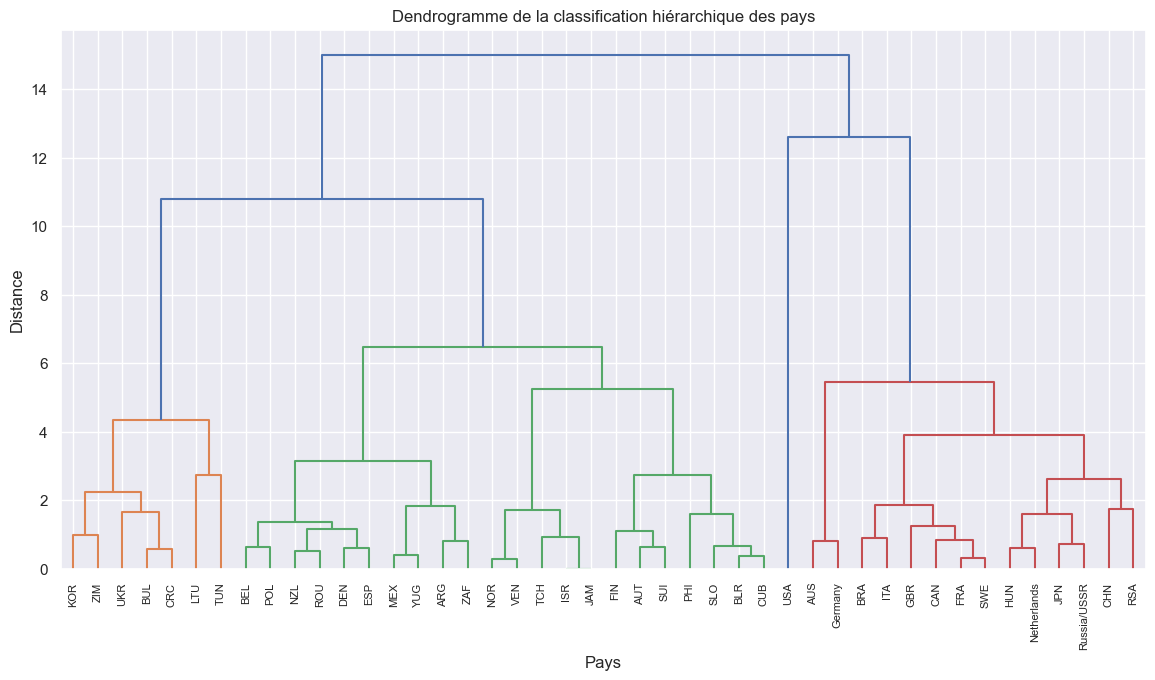

In [96]:
plt.figure(figsize=(14, 7))
dendrogram(
    Z,
    labels=country_names.tolist(),
    leaf_rotation=90,
    leaf_font_size=8
)
plt.title("Dendrogramme de la classification hiérarchique des pays")
plt.xlabel("Pays")
plt.ylabel("Distance")
plt.show()

#### Interprétation du dendrogramme

Le dendrogramme représente les fusions successives de la classification hiérarchique ascendante appliquée aux pays. Chaque pays est d’abord considéré comme un groupe distinct, puis les groupes les plus proches sont fusionnés progressivement. La hauteur à laquelle deux groupes se rejoignent indique leur niveau de dissimilarité : plus la fusion se produit haut dans l’arbre, plus les groupes réunis sont différents.

L’arbre met en évidence une structure hiérarchique assez claire. On observe plusieurs grands ensembles de pays qui ne fusionnent qu’à des distances élevées, ce qui suggère l’existence de profils nationaux réellement distincts. La partie droite du dendrogramme rassemble notamment les grandes nations historiques de la natation olympique, comme les **États-Unis**, l’**Australie**, l’**Allemagne**, l’ensemble **Russie/URSS**, le **Japon**, la **Grande-Bretagne**, le **Canada**, la **Suède**, la **Chine**, la **Hongrie**, le **Brésil**, l’**Italie**, les **Pays-Bas** ou encore l’**Afrique du Sud**.

Les **États-Unis** apparaissent comme un cas particulièrement atypique. Ils sont proches du groupe des grandes nations, mais restent isolés et ne rejoignent les autres pays qu’à une distance élevée. Cela confirme leur position exceptionnelle déjà mise en évidence dans les analyses descriptives et dans l’ACP : leur volume de participations et de médailles est nettement supérieur à celui des autres pays.

Le dendrogramme fait aussi apparaître un groupe intermédiaire, au centre, composé de pays comme la **Pologne**, la **Nouvelle-Zélande**, la **Roumanie**, le **Danemark**, l’**Espagne**, le **Mexique**, la **Yougoslavie**, l’**Argentine**, la **Norvège**, le **Venezuela**, la **Tchécoslovaquie**, **Israël**, la **Jamaïque**, la **Finlande**, l’**Autriche**, la **Suisse**, les **Philippines**, la **Slovénie**, la **Belgique** ou **Cuba**. Ces pays semblent correspondre à des profils plus modestes que les grandes puissances, mais suffisamment présents ou performants pour se distinguer du groupe des pays les plus ponctuels.

Le groupe situé à gauche rassemble plutôt des pays ayant des profils plus spécifiques ou plus ponctuels dans le jeu de données, comme la **Corée**, le **Zimbabwe**, l’**Ukraine**, la **Bulgarie**, le **Costa Rica**, la **Lituanie** ou la **Tunisie**. Certains de ces pays peuvent avoir de bons indicateurs relatifs, mais ils restent moins comparables aux grandes nations en termes de volume total et de présence historique.

Le regroupement de l’**Allemagne**, de l’ensemble **Russie/URSS** et des **Pays-Bas** permet ici une lecture plus cohérente du dendrogramme. Plutôt que de disperser artificiellement les performances entre plusieurs appellations ou codes historiques, cette harmonisation fait apparaître plus clairement leur place parmi les nations importantes de la natation olympique.

Dans l’ensemble, cette représentation confirme qu’il existe bien plusieurs profils de pays en natation olympique. Elle suggère notamment une opposition entre les grandes puissances historiques, les pays intermédiaires régulièrement présents, et des pays plus ponctuels ou caractérisés par des indicateurs relatifs élevés. Une partition en **4 groupes** semble pertinente, car elle permet en plus d’isoler les **États-Unis**, dont le profil est très différent de celui des autres nations.

In [97]:
from scipy.cluster.hierarchy import fcluster
clusters_h = fcluster(Z, t=4, criterion='maxclust')
# fcluster transforme cette hiérarchie en groupes concrets. elleprend la hiérarchie stockée dans Z et la coupe pour produire une classification finale.
#cela renvoie un vecteur où chaque nombre est le numéro du cluster attribué à un pays.
#ici on demande une partition en 4 groupes 
#criterion='maxclust' impose d avoir MAXIMUM t clusters, ici 4

In [98]:
country_clusters_h = country_acp_filtered[['Team']].reset_index(drop=True).copy()
country_clusters_h['Cluster_H'] = clusters_h
country_clusters_h.sort_values(['Cluster_H', 'Team'])

,Team,Cluster_H
6,BUL,1
9,CRC,1
22,KOR,1
23,LTU,1
37,TUN,1
38,UKR,1
43,ZIM,1
0,ARG,2
2,AUT,2
3,BEL,2


In [99]:
country_clusters_h['Cluster_H'].value_counts().sort_index()

Cluster_H
1     7
2    22
3    14
4     1
Name: count, dtype: int64

In [100]:
# On repart uniquement des pays et de leur cluster hiérarchique
country_clusters_h_simple = country_clusters_h[['Team', 'Cluster_H']].copy()

# On ajoute les variables descriptives des pays
country_clusters_h_simple = country_clusters_h_simple.merge(
    country_acp_filtered,
    on='Team',
    how='left'
)

# Résumé moyen des caractéristiques par cluster
cluster_summary_h = country_clusters_h_simple.groupby('Cluster_H')[
    [
        'Participations',
        'Medals',
        'Avg_rank',
        'Years_present',
        'Events_count',
        'Medal_rate',
        'Gold_rate',
        'Medals_per_year'
    ]
].mean()

cluster_summary_h

,Participations,Medals,Avg_rank,Years_present,Events_count,Medal_rate,Gold_rate,Medals_per_year
Cluster_H,,,,,,,,
1,9.857143,4.571429,2.940249,4.285714,5.285714,0.474717,0.476190,1.030952
2,16.681818,3.409091,3.671206,7.454545,7.363636,0.205159,0.146853,0.398453
3,201.571429,68.857143,3.399809,20.142857,16.357143,0.323781,0.238952,3.385520
4,882.000000,549.000000,2.639456,24.000000,18.000000,0.622449,0.437158,22.875000


La classification hiérarchique ascendante, mise en œuvre ici selon les méthodes vues dans le TP5, permet de regrouper les pays présentant des profils proches en termes de volume historique, de régularité, de diversité, de rang moyen et d’efficacité relative.

Le dendrogramme suggérait qu’une partition en **4 groupes** était pertinente, et cette coupure conduit à une structure globalement cohérente :

- le **cluster 4** est constitué des seuls **États-Unis**, ce qui confirme leur caractère extrêmement atypique. Ce pays présente des valeurs très supérieures à tous les autres pour `Participations`, `Medals` et `Medals_per_year`, avec également un `Avg_rank` plus favorable. Il s’agit donc d’un profil de domination exceptionnelle ;

- le **cluster 3** regroupe les grandes nations historiques de la natation olympique, comme l’**Australie**, le **Brésil**, le **Canada**, la **Chine**, la **France**, la **Grande-Bretagne**, l’**Allemagne**, la **Hongrie**, l’**Italie**, le **Japon**, les **Pays-Bas**, l’**Afrique du Sud**, l’ensemble **Russie/URSS** ou encore la **Suède**. Ce groupe se caractérise par un niveau élevé de `Participations`, de `Medals`, de `Years_present` et de `Events_count`. Il correspond donc aux pays régulièrement présents, couvrant beaucoup d’épreuves et obtenant un volume important de médailles ;

- le **cluster 1** rassemble un petit groupe de pays comme la **Bulgarie**, le **Costa Rica**, la **Corée**, la **Lituanie**, la **Tunisie**, l’**Ukraine** ou le **Zimbabwe**. Ces pays ont un volume de participation assez faible, mais présentent de bons indicateurs relatifs : leur `Medal_rate` et leur `Gold_rate` sont les plus élevés après les États-Unis, et leur `Avg_rank` est meilleur que celui du cluster 2. Ce groupe semble donc correspondre à des pays moins présents historiquement, mais relativement efficaces dans les observations disponibles ;

- le **cluster 2** regroupe le plus grand nombre de pays, comme l’**Argentine**, l’**Autriche**, la **Belgique**, **Cuba**, le **Danemark**, l’**Espagne**, la **Finlande**, **Israël**, la **Jamaïque**, le **Mexique**, la **Norvège**, la **Nouvelle-Zélande**, la **Pologne**, la **Roumanie**, la **Slovénie**, la **Suisse**, la **Tchécoslovaquie**, le **Venezuela** ou encore la **Yougoslavie**. Ce cluster se caractérise par des niveaux faibles de médailles et des indicateurs relatifs plus modestes, malgré une présence parfois plus longue que celle du cluster 1. Il correspond donc plutôt à des pays présents de manière régulière ou ponctuelle, mais moins performants en moyenne.

Le tableau des moyennes par cluster confirme cette lecture. Il ne fait pas seulement apparaître une opposition entre les grandes puissances et les pays plus modestes : il distingue aussi deux profils parmi les pays moins dominants. Le cluster 1 contient des pays peu présents mais relativement efficaces, tandis que le cluster 2 contient des pays un peu plus installés historiquement, mais avec un rendement sportif plus faible.

Cette classification hiérarchique met donc bien en évidence l’existence de profils de pays en natation olympique. Elle montre aussi que la structure des données reste fortement marquée par la surreprésentation des **États-Unis**, tout en faisant apparaître un groupe cohérent de grandes nations historiques et un ensemble de pays plus modestes différenciés par leur efficacité relative.

<a id='2-6'></a>
### 2.6 — K-means sur les pays



Après la classification hiérarchique, on utilise une seconde méthode de regroupement : **K-means**.


K-means est une méthode de classification non supervisée qui vise à partitionner les individus en un nombre fixé de groupes, noté \(K\).

Dans notre cas, les individus sont les pays, décrits par plusieurs variables quantitatives de performance, de présence et de régularité.

Le principe est le suivant :

1. on choisit à l’avance un nombre de groupes \(K\) ;
2. la méthode répartit les pays en \(K\) groupes ;
3. chaque groupe est représenté par un centre ;
4. chaque pays est affecté au groupe dont le centre est le plus proche ;
5. les centres sont recalculés itérativement jusqu’à stabilisation.

L’objectif est d’obtenir des groupes aussi **homogènes** que possible, c’est-à-dire des pays proches à l’intérieur d’un même groupe et plus éloignés des pays des autres groupes.

Dans cette étude, K-means permet de compléter la CAH avec une méthode plus **directe** et plus **structurée**.

Contrairement au clustering hiérarchique :

- K-means impose un nombre de groupes dès le départ ;
- il fournit directement une partition des pays ;
- il permet de comparer plus facilement différentes segmentations.

On cherche ici à voir si cette méthode retrouve des profils de pays similaires à ceux suggérés par l’ACP et par la classification hiérarchique.


L’idée est notamment de voir si l’on retrouve :

- un groupe de pays très dominants ;
- un groupe de pays intermédiaires ;
- un groupe de pays plus modestes ;
- éventuellement un cas très particulier, comme un pays extrêmement dominant et atypique.

L’ACP a permis de visualiser les pays et de mettre en évidence des différences de profils.  
La CAH a ensuite proposé un regroupement progressif sous forme hiérarchique.  
K-means vient maintenant fournir une autre manière de construire des groupes, afin de vérifier si les structures observées sont robustes.


#### Choix du nombre de groupes avec la méthode du coude et le score de silhouette

Avant d’appliquer K-means, on vérifie que le choix de **K = 4** est cohérent. Pour cela, on compare plusieurs valeurs possibles de \(K\) à l’aide de deux critères classiques vus dans le TP5 :

- l’**inertie**, utilisée dans la méthode du coude ;
- le **score de silhouette**, qui mesure si les groupes obtenus sont bien séparés.


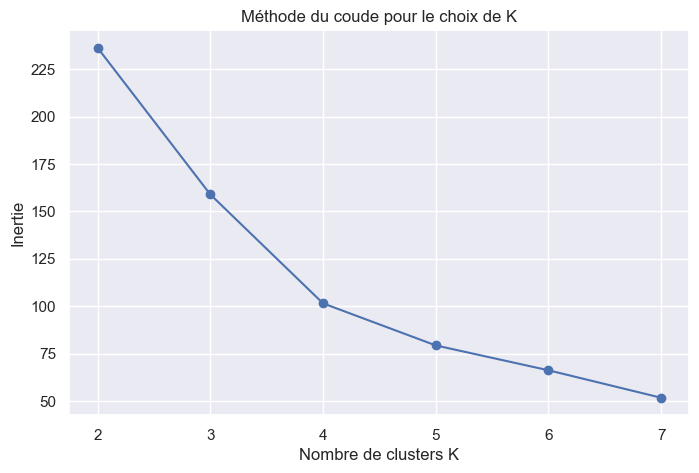

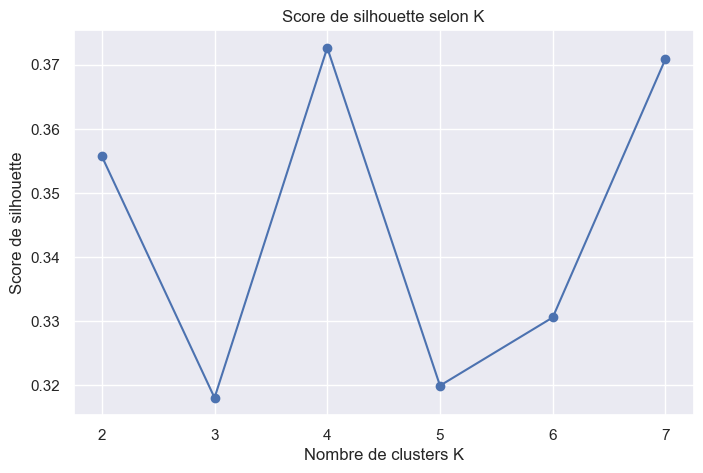

In [126]:
from sklearn.metrics import silhouette_score

inertias = []
silhouettes = []

K_values = range(2, 8)

for k in K_values:
    kmeans_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans_test.fit_predict(X_country_scaled)
    
    inertias.append(kmeans_test.inertia_)
    silhouettes.append(silhouette_score(X_country_scaled, labels))

plt.figure(figsize=(8,5))
plt.plot(K_values, inertias, marker='o')
plt.title("Méthode du coude pour le choix de K")
plt.xlabel("Nombre de clusters K")
plt.ylabel("Inertie")
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(K_values, silhouettes, marker='o')
plt.title("Score de silhouette selon K")
plt.xlabel("Nombre de clusters K")
plt.ylabel("Score de silhouette")
plt.grid(True)
plt.show()


La méthode du coude montre que l’inertie diminue fortement lorsque l’on passe de 2 à 3 groupes, puis encore nettement de 3 à 4 groupes. À partir de **K = 4**, la diminution devient plus progressive. Cela suggère donc qu’une partition en 4 groupes constitue un bon compromis : elle réduit suffisamment l’inertie sans multiplier excessivement le nombre de clusters.

Le score de silhouette confirme aussi l’intérêt de ce choix. Parmi les valeurs testées, le score est maximal pour **K = 4**, avec une valeur légèrement supérieure à celles obtenues pour les autres nombres de groupes. Même si le score pour **K = 7** est également élevé, ce choix conduirait à une partition plus détaillée et moins facilement interprétable dans le cadre de cette étude.

Ainsi, le choix de **K = 4** est cohérent à la fois avec la méthode du coude, le score de silhouette et l’interprétation déjà donnée par le dendrogramme. On conserve donc 4 groupes pour la suite de l’analyse K-means.


In [127]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters_k = kmeans.fit_predict(X_country_scaled)
#on demande ici 4 groupes, 
#random_state=42 : pour obtenir un résultat reproductible 
#n_init=10 : l’algorithme essaie plusieurs initialisations et garde la meilleure
#Le résultat clusters_k donne, pour chaque pays, le numéro du cluster attribué par K-means.

In [128]:
country_clusters_k = country_acp_filtered[['Team']].reset_index(drop=True).copy()
country_clusters_k['Cluster_K'] = clusters_k
country_clusters_k.sort_values(['Cluster_K', 'Team'])

,Team,Cluster_K
1,AUS,0
5,BRA,0
7,CAN,0
8,CHN,0
11,DEN,0
14,FRA,0
15,GBR,0
16,Germany,0
17,HUN,0
19,ITA,0


In [129]:
country_clusters_k['Cluster_K'].value_counts().sort_index()

Cluster_K
0    15
1     1
2     7
3    21
Name: count, dtype: int64

In [130]:
# On repart uniquement des pays et de leur cluster K-means
country_clusters_k_simple = country_clusters_k[['Team', 'Cluster_K']].copy()

# On ajoute les variables descriptives à partir de la colonne commune Team.
# Le tableau contient donc chaque pays, son cluster K-means et ses caractéristiques.
country_clusters_k_simple = country_clusters_k_simple.merge(
    country_acp_filtered,
    on='Team',
    how='left'
)

# Résumé moyen des caractéristiques par cluster K-means
cluster_summary_k = country_clusters_k_simple.groupby('Cluster_K')[
    [
        'Participations',
        'Medals',
        'Avg_rank',
        'Years_present',
        'Events_count',
        'Medal_rate',
        'Gold_rate',
        'Medals_per_year'
    ]
].mean()

cluster_summary_k

,Participations,Medals,Avg_rank,Years_present,Events_count,Medal_rate,Gold_rate,Medals_per_year
Cluster_K,,,,,,,,
0,191.733333,65.133333,3.411427,20.000000,16.066667,0.318245,0.238406,3.207967
1,882.000000,549.000000,2.639456,24.000000,18.000000,0.622449,0.437158,22.875000
2,9.857143,4.571429,2.940249,4.285714,5.285714,0.474717,0.476190,1.030952
3,14.904762,2.952381,3.675831,6.952381,7.142857,0.203464,0.142857,0.383036


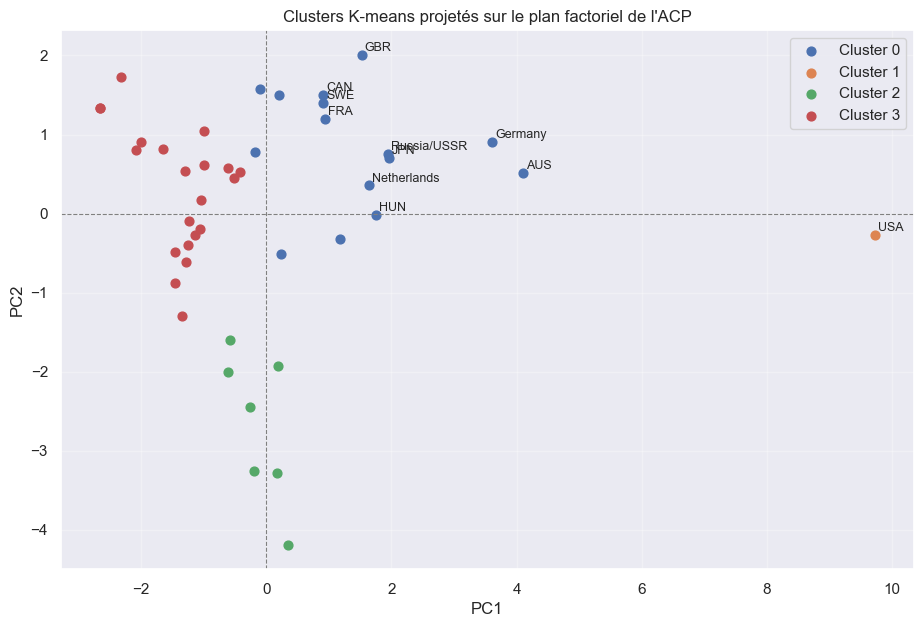

In [106]:
pca_results_country_k = pca_results_country.merge(
    country_clusters_k[['Team', 'Cluster_K']],
    on='Team',
    how='left'
)

plt.figure(figsize=(11,7))

for cluster in sorted(pca_results_country_k['Cluster_K'].unique()):
    subset = pca_results_country_k[pca_results_country_k['Cluster_K'] == cluster]
    plt.scatter(subset['PC1'], subset['PC2'], s=40, label=f'Cluster {cluster}')

for _, row in pca_results_country_k.iterrows():
    if row['Team'] in ['USA', 'AUS', 'JPN', 'Germany', 'GBR', 'HUN', 'CAN', 'FRA', 'SWE', 'Russia/USSR', 'Netherlands']:
        plt.annotate(row['Team'], (row['PC1'], row['PC2']), xytext=(row['PC1']+0.05, row['PC2']+0.05), fontsize=9)

plt.title("Clusters K-means projetés sur le plan factoriel de l'ACP")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
plt.axvline(0, color='grey', linestyle='--', linewidth=0.8)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

L’application de la méthode **K-means**, vue dans le TP5, conduit ici à une partition en 4 groupes globalement cohérente avec la structure déjà observée dans l’ACP et dans la classification hiérarchique.

Le **cluster 1** contient uniquement les **États-Unis**. Ce résultat confirme une nouvelle fois leur caractère très atypique dans le jeu de données. Les États-Unis présentent des valeurs extrêmement élevées pour `Participations`, `Medals` et `Medals_per_year`, ainsi qu’un bon `Avg_rank`. Ils forment donc à eux seuls un profil de domination exceptionnelle.

Le **cluster 0** regroupe les grandes nations historiques de la natation olympique, comme l’**Australie**, le **Brésil**, le **Canada**, la **Chine**, le **Danemark**, la **France**, la **Grande-Bretagne**, l’**Allemagne**, la **Hongrie**, l’**Italie**, le **Japon**, les **Pays-Bas**, l’**Afrique du Sud**, l’ensemble **Russie/URSS** ou encore la **Suède**. Ce groupe se caractérise par un niveau élevé de `Participations`, de `Medals`, de `Years_present` et de `Events_count`. Il correspond donc aux pays régulièrement présents, participant à de nombreuses épreuves et obtenant un volume important de médailles.

Le **cluster 2** rassemble des pays moins présents historiquement, comme la **Bulgarie**, le **Costa Rica**, la **Corée**, la **Lituanie**, la **Tunisie**, l’**Ukraine** ou le **Zimbabwe**, mais relativement efficaces dans les observations disponibles. Il se distingue par des valeurs assez élevées de `Medal_rate` et de `Gold_rate`, malgré un volume total de participations et de médailles beaucoup plus faible que celui des grandes nations. Ce groupe peut donc correspondre à des pays ayant obtenu de bons résultats ponctuels, mais sur un nombre plus limité d’observations.

Le **cluster 3** regroupe le plus grand nombre de pays. Il correspond à des nations plus modestes ou intermédiaires, avec peu de médailles, un `Medal_rate` plus faible et un `Avg_rank` moins favorable. Ces pays peuvent avoir une certaine présence historique, mais ils se distinguent moins par leurs performances sportives dans le jeu de données.

Le tableau des moyennes par cluster confirme donc une structure assez proche de celle obtenue avec la classification hiérarchique : les États-Unis sont isolés, les grandes nations historiques forment un groupe cohérent, et les pays plus modestes se divisent entre un groupe relativement efficace mais peu présent et un groupe plus large aux résultats plus limités.

Ainsi, la méthode **K-means** confirme l’existence de profils de pays en natation olympique. Elle renforce l’idée que les différences entre nations ne se résument pas seulement au nombre total de médailles, mais dépendent aussi de la régularité de présence, de la diversité des épreuves disputées et de l’efficacité relative des performances.

<a id='2-7'></a>
### 2.7 — Comparaison de la CAH et du K-means


In [107]:
country_clusters_k['Cluster_K_compare'] = country_clusters_k['Cluster_K'].map({
    2: 1,  # pays peu présents mais relativement efficaces
    3: 2,  # pays modestes / intermédiaires
    0: 3,  # grandes nations historiques
    1: 4   # États-Unis seuls
})


In [108]:
comparison_clusters = country_clusters_h[['Team', 'Cluster_H']].merge(
    country_clusters_k[['Team', 'Cluster_K_compare']],
    on='Team',
    how='inner'
)

comparison_clusters = comparison_clusters.rename(
    columns={'Cluster_K_compare': 'Cluster_K'}
)

comparison_clusters.sort_values('Team')


,Team,Cluster_H,Cluster_K
0,ARG,2,2
1,AUS,3,3
2,AUT,2,2
3,BEL,2,2
4,BLR,2,2
5,BRA,3,3
6,BUL,1,1
7,CAN,3,3
8,CHN,3,3
9,CRC,1,1


In [109]:
pd.crosstab(comparison_clusters['Cluster_H'], comparison_clusters['Cluster_K'])

Cluster_K,1,2,3,4
Cluster_H,,,,
1,7,0,0,0
2,0,21,1,0
3,0,0,14,0
4,0,0,0,1


La comparaison entre la classification hiérarchique ascendante et le K-means montre une très forte cohérence entre les deux méthodes. Après renommage des groupes du K-means pour les faire correspondre aux profils obtenus par la CAH, les deux partitions sont presque identiques.

Le tableau croisé confirme cette proximité. Le **cluster 1** de la CAH est entièrement retrouvé par le K-means : les 7 pays de ce groupe sont classés de la même manière dans les deux méthodes. Le **cluster 3**, qui correspond aux grandes nations historiques, est lui aussi parfaitement retrouvé avec 14 pays classés dans le même groupe. Le **cluster 4**, constitué uniquement des **États-Unis**, est également identique dans les deux classifications. Cela confirme le caractère très atypique des États-Unis, qui sont isolés par les deux approches.

La seule différence concerne le **cluster 2** de la CAH. Sur les 22 pays de ce groupe, 21 sont classés dans le même cluster par le K-means, tandis qu’un seul pays, le **Danemark**, est rattaché au cluster des grandes nations historiques. Cette différence reste très limitée et peut s’expliquer par une position intermédiaire du Danemark entre deux profils.

Cette quasi-identité entre les deux classifications est un résultat important. Elle signifie que la structure des données est assez nette : les groupes ne dépendent pas fortement de la méthode choisie. La CAH, qui construit progressivement les groupes à partir des distances entre pays, et le K-means, qui forme des groupes autour de centres, aboutissent presque aux mêmes profils.

Les deux méthodes convergent donc vers la même typologie :
- un groupe de pays peu présents mais relativement efficaces ;
- un groupe large de pays plus modestes ou intermédiaires ;
- un groupe de grandes nations historiques ;
- un pays totalement atypique et ultra-dominant : les **États-Unis**.

On peut donc conclure que l’existence de profils de pays en natation olympique est confirmée de manière robuste. La forte cohérence entre la CAH et le K-means renforce la fiabilité de l’analyse : les profils observés ne semblent pas être un artefact d’une seule méthode, mais bien une structure réelle du jeu de données.

<a id='2-8'></a>
## Conclusion de la question 2

L’ensemble des méthodes mobilisées dans cette deuxième partie permet de répondre de manière convaincante à la question de l’existence de profils de pays en natation olympique.

D’abord, l’analyse descriptive a montré une forte concentration des performances sur un petit nombre de nations. Les **États-Unis** dominent très nettement le jeu de données, à la fois en nombre de participations, en nombre de médailles, en présence sur la durée, en diversité d’épreuves et en nombre moyen de médailles par année de présence. L’**Australie** occupe également une place majeure, tandis que d’autres pays comme le **Japon**, l’**Allemagne**, la **Grande-Bretagne**, la **Hongrie**, le **Canada**, la **France**, la **Suède** ou encore l’ensemble **Russie/URSS** apparaissent comme des nations historiquement solides.

L’ajout d’indicateurs relatifs, comme `Medal_rate`, `Gold_rate` et `Medals_per_year`, a permis de nuancer les simples classements bruts. Ces variables montrent que certains pays moins présents peuvent avoir une efficacité relativement élevée dans les observations disponibles. Cependant, leur interprétation doit rester prudente, car un faible nombre de participations ou de médailles peut fortement influencer les taux obtenus.

Ensuite, l’étude des distributions et de la matrice de corrélation a montré que plusieurs variables sont très liées entre elles, notamment celles associées au volume de médailles. Cela a conduit à retenir un ensemble plus synthétique de variables pour l’analyse multivariée, afin de mieux distinguer les dimensions de `domination`, de `régularité`, de `diversité`, de `qualité moyenne` et d’`efficacité relative`.

L’ACP a confirmé qu’il existe une structuration claire des pays selon ces dimensions. Le premier axe traduit principalement une domination globale, opposant les nations très présentes, très médaillées et très régulières aux pays plus modestes. Le deuxième axe affine cette lecture en opposant davantage la présence historique et la diversité d’épreuves à l’efficacité relative. La projection des pays sur le plan factoriel a notamment mis en évidence le caractère très atypique des **États-Unis**, ainsi que la proximité entre plusieurs grandes nations historiques.

Les méthodes de clustering ont ensuite renforcé cette lecture. La classification hiérarchique et le K-means convergent presque parfaitement vers une même typologie :
- un groupe de pays peu présents mais relativement efficaces ;
- un groupe large de pays plus modestes ou intermédiaires ;
- un groupe de grandes nations historiques de la natation olympique ;
- et un groupe à part entière constitué des **États-Unis**, dont le profil est exceptionnel.

La comparaison entre la CAH et le K-means montre que les deux méthodes donnent quasiment les mêmes groupes. Seul le **Danemark** change de cluster selon la méthode, ce qui peut s’expliquer par une position intermédiaire entre le groupe des pays modestes et celui des grandes nations historiques. Cette très forte cohérence montre que les profils identifiés sont robustes et ne dépendent pas uniquement d’une seule méthode de partition.

On peut donc conclure que :
- il existe bien des profils distincts de pays en natation olympique ;
- les **États-Unis** constituent un profil à part, marqué par une domination exceptionnelle ;
- certaines nations, comme l’**Australie**, l’**Allemagne**, le **Japon**, la **Grande-Bretagne**, la **Hongrie**, le **Canada**, la **France**, la **Suède** ou l’ensemble **Russie/URSS**, forment un groupe de grandes puissances historiques ;
- d’autres pays se distinguent par une efficacité relative intéressante malgré un volume plus faible ;
- enfin, un grand nombre de nations restent dans des profils plus modestes ou plus ponctuels.

Cette deuxième partie répond ainsi à la problématique en montrant que la natation olympique ne se réduit pas à un simple classement de médailles. Elle fait apparaître de véritables types de nations sportives, différenciés par leur puissance, leur régularité, leur diversité de présence, leur qualité moyenne et leur efficacité relative.

<a id='2-9'></a>
### Mise en perspective historique

Les résultats obtenus dans la question 2 sont globalement cohérents avec l’histoire réelle de la natation olympique. Ils font apparaître les **États-Unis** comme une nation totalement à part, l’**Australie** comme une autre très grande puissance, puis un groupe de nations historiquement solides comme le **Japon**, l’**Allemagne**, la **Grande-Bretagne**, la **Hongrie**, le **Canada**, la **Suède** ou encore l’ensemble **Russie/URSS**. Cette hiérarchie correspond bien aux grandes tendances observées dans l’histoire olympique de la natation, où les **États-Unis** occupent une place dominante et où l’**Australie** apparaît comme l’une des principales puissances concurrentes.

Le fait que les **États-Unis** apparaissent isolés dans un groupe à part est donc tout à fait logique. Cette domination ne s’explique pas seulement par une présence ancienne et régulière aux Jeux olympiques, mais aussi par l’accumulation de générations entières de nageurs et nageuses de très haut niveau. Le cas de **Michael Phelps** est évidemment emblématique, avec 28 médailles olympiques dont 23 en or, un record absolu. D’autres nageurs et nageuses, comme **Katie Ledecky**, ont également renforcé ce poids historique sur plusieurs olympiades.

La place occupée par l’**Australie** est elle aussi cohérente. Son poids historique en natation olympique est bien connu, et il s’explique non seulement par une forte culture de la natation, mais aussi par l’existence d’un système structuré de formation et de haut niveau. Les documents de **Swimming Australia** mettent d’ailleurs en avant une véritable filière de développement, pensée pour accompagner les nageurs du repérage jusqu’au très haut niveau international.

La présence du **Japon**, de l’**Allemagne**, de la **Grande-Bretagne**, de la **Hongrie**, du **Canada** ou de la **Suède** parmi les nations fortes ou régulières paraît également crédible. Certaines de ces nations se distinguent moins par une domination absolue que par leur longévité, leur présence sur de nombreuses éditions ou leur capacité à rester compétitives dans la durée. Cela correspond bien aux dimensions qui ressortent de l’analyse statistique, en particulier la régularité, la diversité de présence et le volume global de réussite.

L’ensemble **Russie/URSS** apparaît lui aussi à une place cohérente. L’histoire olympique de la natation montre que l’espace soviétique puis russe a joué un rôle important, avec des performances de haut niveau sur plusieurs périodes. Le regroupement de ces appellations permet donc de mieux faire ressortir ce poids historique, qui aurait été plus difficile à interpréter si les différentes périodes étaient restées séparées.

Il faut toutefois garder à l’esprit que les groupes obtenus dépendent aussi de la structure du jeu de données. Celui-ci comptabilise les résultats disponibles par pays, années, épreuves et rangs, ce qui favorise mécaniquement les nations présentes sur beaucoup d’éditions et dans beaucoup d’épreuves. Les pays ayant eu quelques nageurs exceptionnels peuvent également ressortir fortement sur certains indicateurs relatifs, même s’ils ne possèdent pas la même profondeur historique que les grandes nations dominantes.

Au total, les groupes trouvés par l’ACP, la CAH et le K-means ne paraissent donc pas artificiels : ils reflètent assez bien la réalité historique de la natation olympique. On retrouve une nation ultra-dominante, les **États-Unis**, une autre très grande puissance structurelle, l’**Australie**, puis un noyau de nations historiquement solides et régulières, et enfin des pays plus modestes ou plus ponctuellement efficaces. Cette mise en perspective renforce donc la crédibilité de l’analyse statistique menée sur les données, tout en rappelant que les résultats doivent être interprétés à la lumière du contenu exact du jeu de données.

<a id='q3'></a>
# Partie III — Question 3 : Peut-on esquisser une évolution future des performances ?


<a id='3-1'></a>
### 3.1 — Définir ce qu'on veut prédire et avec quelles données


On va commencer par decider sur quelles epreuves on veut prédire, quelles variables et sur quelle periode.

On va reprendre les 4 épreuves que l'on a choisie pour l'ACP en partie 1 :
- 100m Backstroke
- 100m Freestyle
- 200m Breaststroke
- 400m Freestyle

On va essayer de prédire le temps moyen par epreuve et année 

on va donc repartir du tableau event_year

In [110]:
event_year

,Event,Year,mean,median,count
0,100m Backstroke,1912,83.720000,84.000,5
1,100m Backstroke,1920,77.600000,77.900,4
2,100m Backstroke,1924,82.680000,81.600,10
3,100m Backstroke,1928,78.369231,82.000,13
4,100m Backstroke,1932,76.316667,76.100,12
...,...,...,...,...,...
112,400m Freestyle,2004,236.982500,237.150,16
113,400m Freestyle,2008,234.306250,235.755,16
114,400m Freestyle,2012,234.834375,235.350,16
115,400m Freestyle,2016,233.659375,232.765,16


In [111]:
pred_events = ['100m Backstroke', '100m Freestyle', '200m Breaststroke', '400m Freestyle']

pred_data = event_year[event_year['Event'].isin(pred_events)].copy()
pred_data

,Event,Year,mean,median,count
0,100m Backstroke,1912,83.720000,84.000,5
1,100m Backstroke,1920,77.600000,77.900,4
2,100m Backstroke,1924,82.680000,81.600,10
3,100m Backstroke,1928,78.369231,82.000,13
4,100m Backstroke,1932,76.316667,76.100,12
...,...,...,...,...,...
112,400m Freestyle,2004,236.982500,237.150,16
113,400m Freestyle,2008,234.306250,235.755,16
114,400m Freestyle,2012,234.834375,235.350,16
115,400m Freestyle,2016,233.659375,232.765,16


In [112]:
pred_data.groupby('Event')['Year'].agg(['min', 'max', 'count'])
#pour chaque epreuve on a 25 années 

,min,max,count
Event,,,
100m Backstroke,1912,2020,25
100m Freestyle,1912,2020,25
200m Breaststroke,1912,2020,25
400m Freestyle,1912,2020,25


<a id='3-2'></a>
### 3.2 — Première projection simple par régression linéaire

Ici on va utiliser un modèle de regression linéaire avec comme variable explicative year et variable a predire mean
Pour chaque epreuve on va ajuster un modèle du type temps moyen = a X year +b

In [113]:
from sklearn.linear_model import LinearRegression

# on crée un DataFrame avec les années que l'on souhaite prédire
# on garde ici le nom de colonne 'Year' pour qu'il soit cohérent avec X
# cela évite le warning qui apparaissait quand future_years était un simple tableau numpy sans nom de variable
future_years = pd.DataFrame({'Year': [2024, 2040, 2050]})

predictions = []  # on crée un tableau vide qui servira à stocker toutes les prédictions faites pour chaque épreuve et pour chaque année future

for event in pred_events:
    subset = pred_data[pred_data['Event'] == event].copy()  # on extrait uniquement les lignes qui correspondent à l'épreuve sur laquelle on travaille
    
    X = subset[['Year']]
    y = subset['mean']
    
    model = LinearRegression()  # on crée un objet représentant le modèle de régression linéaire
    model.fit(X, y)  # cette ligne ajuste la droite de régression à partir des données observées ; elle trouve les coefficients a et b tels que mean = a*year + b
    
    y_future = model.predict(future_years)  # on utilise ensuite le modèle pour prédire les années que l'on souhaite estimer
    
    for year, pred in zip(future_years['Year'], y_future):  # on parcourt simultanément les années futures et les prédictions correspondantes
        predictions.append({
            'Event': event,
            'Year_pred': year,
            'Predicted_mean_time': pred,
            'Slope': model.coef_[0],      # Slope donne la pente de la droite de prédiction (a)
            'Intercept': model.intercept_ # Intercept donne l’ordonnée à l’origine (b)
        })

predictions_df = pd.DataFrame(predictions)
predictions_df

# le warning venait du fait que le modèle était entraîné avec un DataFrame contenant une colonne nommée 'Year',
# puis utilisé avec un tableau numpy sans nom de colonne ; en utilisant ici un DataFrame nommé 'Year',
# on garde une structure cohérente entre l'apprentissage et la prédiction

,Event,Year_pred,Predicted_mean_time,Slope,Intercept
0,100m Backstroke,2024,51.204306,-0.271831,601.390142
1,100m Backstroke,2040,46.855011,-0.271831,601.390142
2,100m Backstroke,2050,44.136702,-0.271831,601.390142
3,100m Freestyle,2024,46.593971,-0.210714,473.079670
4,100m Freestyle,2040,43.222542,-0.210714,473.079670
5,100m Freestyle,2050,41.115400,-0.210714,473.079670
6,200m Breaststroke,2024,124.329956,-0.620746,1380.719808
7,200m Breaststroke,2040,114.398021,-0.620746,1380.719808
8,200m Breaststroke,2050,108.190561,-0.620746,1380.719808
9,400m Freestyle,2024,210.918867,-1.137711,2513.646480


La régression linéaire simple fournit, pour chacune des quatre épreuves retenues, une première extrapolation des tendances observées entre 1912 et 2020. Les pentes estimées sont toutes négatives, ce qui est cohérent avec les analyses précédentes : les temps moyens diminuent globalement au fil du temps.

Les prédictions obtenues pour 2024 restent encore plausibles et s’inscrivent dans le prolongement des courbes observées. En revanche, les projections à plus long terme, notamment pour 2040 et 2050, suggèrent parfois une baisse importante des temps, en particulier pour les épreuves les plus longues. Cela montre déjà qu’une extrapolation linéaire sur toute la période historique peut conduire à des prévisions assez optimistes.

Cette première approche joue donc surtout le rôle de point de départ : elle permet de prolonger les tendances passées, mais elle devra ensuite être comparée à une approche fondée sur les périodes les plus récentes, probablement plus réaliste pour le futur proche.

In [114]:
predictions_pivot = predictions_df.pivot(index='Event', columns='Year_pred', values='Predicted_mean_time') 
predictions_pivot

Year_pred,2024,2040,2050
Event,,,
100m Backstroke,51.204306,46.855011,44.136702
100m Freestyle,46.593971,43.222542,41.115400
200m Breaststroke,124.329956,114.398021,108.190561
400m Freestyle,210.918867,192.715486,181.338374


In [115]:
predictions_df[['Event', 'Slope']].drop_duplicates() #on extrait uniquement les colonnes event et slope du tableau et drop duplicate retire les doublons 
#plus la pente est negative plus le temps baisse 

,Event,Slope
0,100m Backstroke,-0.271831
3,100m Freestyle,-0.210714
6,200m Breaststroke,-0.620746
9,400m Freestyle,-1.137711


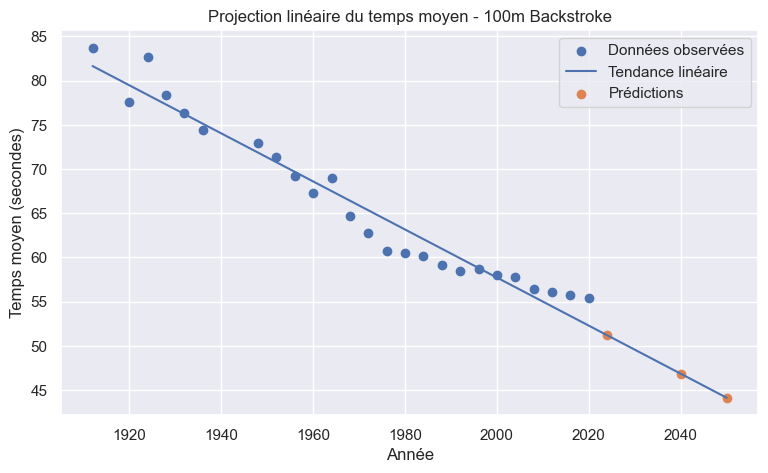

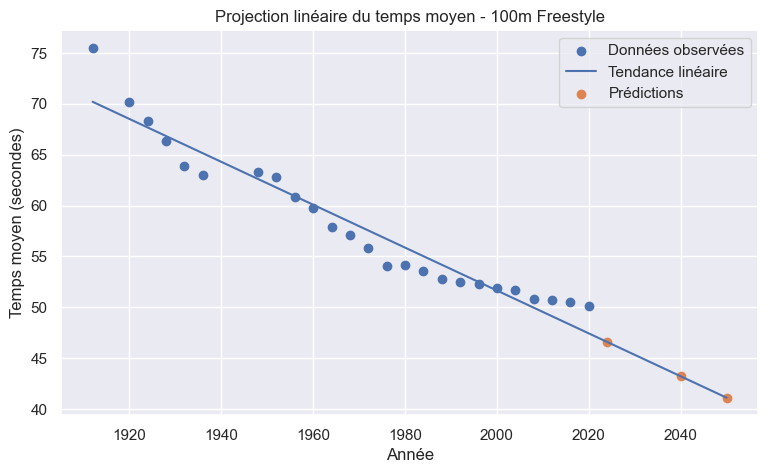

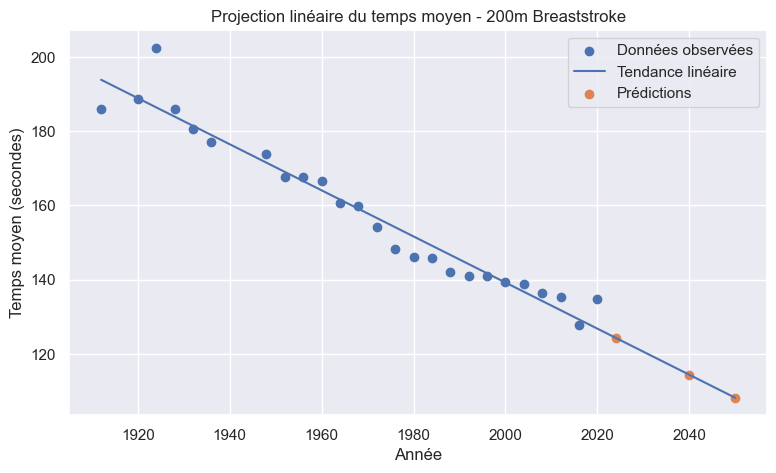

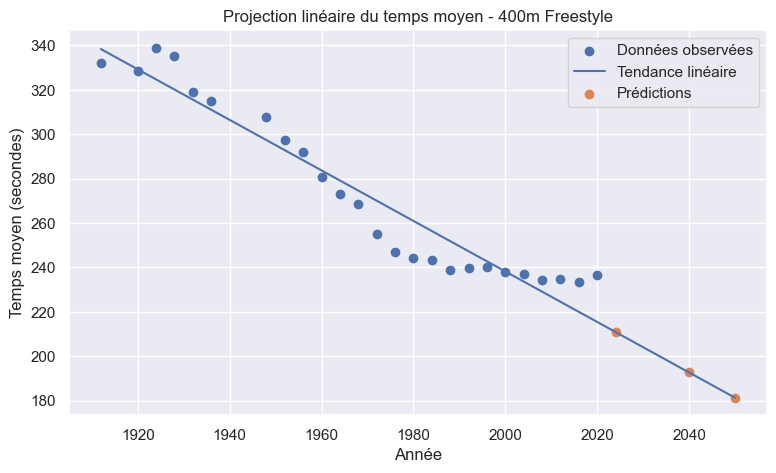

In [116]:
for event in pred_events:
    subset = pred_data[pred_data['Event'] == event].copy()
    
    X = subset[['Year']]
    y = subset['mean']
    
    model = LinearRegression()
    model.fit(X, y)
    
    # on crée un DataFrame pour rester cohérent avec X et éviter les warnings
    years_line = pd.DataFrame({'Year': np.arange(subset['Year'].min(), 2051)})
    y_line = model.predict(years_line)
    
    plt.figure(figsize=(9,5))
    plt.scatter(subset['Year'], y, label='Données observées')
    plt.plot(years_line['Year'], y_line, label='Tendance linéaire')
    plt.scatter(future_years['Year'], model.predict(future_years), label='Prédictions')
    
    plt.title(f"Projection linéaire du temps moyen - {event}")
    plt.xlabel("Année")
    plt.ylabel("Temps moyen (secondes)")
    plt.grid(True)
    plt.legend()
    plt.show()

#### Observation sur la projection linéaire de long terme

Les graphiques obtenus sont globalement cohérents avec ce que l’on pouvait attendre d’une régression linéaire ajustée sur l’ensemble de la période 1912–2020. La droite suit assez bien la tendance historique générale, marquée par une baisse importante des temps moyens au cours du XXe siècle. En ce sens, le modèle rend correctement compte de l’amélioration globale des performances sur le long terme.

Cependant, ces graphiques mettent aussi en évidence une limite importante de cette approche. Dans les quatre épreuves étudiées, les points observés depuis les années 1980–2000 semblent montrer un ralentissement de la progression, voire une forme de stabilisation relative, alors que la droite linéaire continue à faire diminuer les temps de manière régulière. Cela conduit donc à des projections 2024, 2040 et 2050 assez optimistes, en particulier pour les épreuves plus longues comme le 200m brasse et le 400m nage libre.

Cette réserve est cohérente avec ce que l’on sait plus généralement de l’évolution de la natation de haut niveau. Les progrès restent possibles, mais ils ne suivent plus forcément le rythme très marqué observé au début et au milieu du XXe siècle. À mesure que les performances se rapprochent des limites physiologiques et techniques, les gains deviennent souvent plus faibles et plus irréguliers, même si certains records du monde continuent d’être battus ponctuellement. 

#### Comparaison avec les résultats réels de Paris 2024

Pour évaluer la crédibilité de cette première projection, on peut comparer les valeurs prévues pour 2024 avec les résultats réels des Jeux olympiques de Paris 2024.

Les temps de victoire en finale ont été les suivants :
- 100m Backstroke hommes : 52.00 s ; femmes : 57.33 s
- 100m Freestyle hommes : 46.40 s ; femmes : 52.16 s
- 200m Breaststroke hommes : 2:05.85 ; femmes : 2:19.24
- 400m Freestyle hommes : 3:41.78 ; femmes : 3:57.49 

Si l’on prend une moyenne simple hommes/femmes sur ces quatre épreuves, on obtient environ :
- 100m Backstroke : 54.67 s
- 100m Freestyle : 49.28 s
- 200m Breaststroke : 132.55 s
- 400m Freestyle : 229.64 s

Or les prédictions du modèle linéaire pour 2024 étaient plus basses :
- 100m Backstroke : 51.20 s
- 100m Freestyle : 46.59 s
- 200m Breaststroke : 124.33 s
- 400m Freestyle : 210.92 s

La comparaison n’est pas parfaite, car le modèle repose sur des temps moyens historiques agrégés par année, tandis que les résultats olympiques de 2024 correspondent ici aux temps de victoire. Malgré cela, l’écart reste très instructif : dans les quatre cas, la projection linéaire sur toute la période sous-estime les temps observés en 2024. Cela signifie qu’elle surestime l’amélioration récente des performances.

Autrement dit, utiliser toute l’histoire olympique comme base de projection revient à prolonger mécaniquement les fortes baisses du XXe siècle, alors que les décennies récentes semblent davantage marquées par un ralentissement.

#### Une nuance importante : progrès ralentis ne signifie pas absence de records

Il faut toutefois nuancer ce constat. Dire que la progression ralentit ne signifie pas que les performances cessent d’évoluer. Les Jeux de Paris 2024 ont par exemple vu Pan Zhanle remporter le 100m nage libre masculin en 46.40 s, avec un record du monde. Cela montre que des ruptures spectaculaires restent possibles sur certaines épreuves. 

Mais ce type d’exploit correspond davantage à des performances exceptionnelles qu’à une baisse régulière et uniforme de tous les temps moyens. C’est précisément ce que la régression linéaire de long terme peine à capter.

#### Conclusion de cette première tentative de prévision

Cette première projection linéaire est donc utile comme prolongement simplifié de la tendance historique générale, mais elle ne semble pas adaptée pour prédire de façon réaliste le futur proche. Elle incorpore en effet les très fortes améliorations du début et du milieu du XXe siècle, ce qui conduit à des prévisions trop optimistes pour les décennies récentes.

La comparaison avec les résultats de Paris 2024 confirme cette limite : les temps réellement observés sont plus élevés que ceux prédits par le modèle. Il paraît donc plus pertinent, dans la suite, d’ajuster un modèle sur une période plus récente, par exemple à partir de 1980 ou 1990, afin de mieux tenir compte du ralentissement actuel de l’évolution des performances.

<a id='3-3'></a>
### 3.3 — Projection sur une période récente (depuis 1980)


on observe un ralentissement de l'améliorartion des temps sur ces dernieres décennies, on va donc refaire un modele similaire de regression mais en considérant seulement les epreuves depuis 1980.

In [117]:
recent_pred_data = pred_data[pred_data['Year'] >= 1980].copy()
recent_pred_data.groupby('Event')['Year'].agg(['min', 'max', 'count'])

,min,max,count
Event,,,
100m Backstroke,1980,2020,11
100m Freestyle,1980,2020,11
200m Breaststroke,1980,2020,11
400m Freestyle,1980,2020,11


In [118]:
future_years = pd.DataFrame({'Year': [2024, 2040, 2050]})

recent_predictions = []

for event in pred_events:
    subset = recent_pred_data[recent_pred_data['Event'] == event].copy()
    
    X = subset[['Year']]
    y = subset['mean']
    
    model = LinearRegression()
    model.fit(X, y)
    
    y_future = model.predict(future_years)
    
    for year, pred in zip(future_years['Year'], y_future):
        recent_predictions.append({
            'Event': event,
            'Year_pred': year,
            'Predicted_mean_time_recent': pred,
            'Slope_recent': model.coef_[0],
            'Intercept_recent': model.intercept_
        })

recent_predictions_df = pd.DataFrame(recent_predictions)
recent_predictions_df

,Event,Year_pred,Predicted_mean_time_recent,Slope_recent,Intercept_recent
0,100m Backstroke,2024,54.765602,-0.129061,315.985227
1,100m Backstroke,2040,52.700625,-0.129061,315.985227
2,100m Backstroke,2050,51.410014,-0.129061,315.985227
3,100m Freestyle,2024,49.587489,-0.096679,245.265739
4,100m Freestyle,2040,48.040625,-0.096679,245.265739
5,100m Freestyle,2050,47.073835,-0.096679,245.265739
6,200m Breaststroke,2024,130.206651,-0.363313,865.552492
7,200m Breaststroke,2040,124.393640,-0.363313,865.552492
8,200m Breaststroke,2050,120.760509,-0.363313,865.552492
9,400m Freestyle,2024,232.644231,-0.232143,702.501648


In [119]:
recent_predictions_pivot = recent_predictions_df.pivot(
    index='Event',
    columns='Year_pred',
    values='Predicted_mean_time_recent'
)

recent_predictions_pivot

Year_pred,2024,2040,2050
Event,,,
100m Backstroke,54.765602,52.700625,51.410014
100m Freestyle,49.587489,48.040625,47.073835
200m Breaststroke,130.206651,124.393640,120.760509
400m Freestyle,232.644231,228.929943,226.608513


##### Observation sur la projection linéaire sur période récente

La projection réalisée à partir de la seule période 1980–2020 me paraît nettement plus cohérente que celle ajustée sur l’ensemble de la période 1912–2020. Les pentes restent négatives dans les quatre épreuves, ce qui confirme que les temps continuent globalement à diminuer, mais la baisse est beaucoup moins forte que dans le modèle de long terme. Cela correspond mieux à ce que montrent les courbes : depuis la fin du XXe siècle, l’amélioration des performances semble plus lente et plus irrégulière, avec des phases de quasi-stagnation dans plusieurs épreuves.

Les prévisions obtenues pour 2024 sont :
- 100m Backstroke : 54.77 s
- 100m Freestyle : 49.59 s
- 200m Breaststroke : 130.21 s
- 400m Freestyle : 232.64 s

Ces valeurs paraissent beaucoup plus plausibles que celles du modèle ajusté sur toute l’histoire olympique, car elles tiennent mieux compte du ralentissement récent des progrès.

##### Comparaison avec les résultats réels de Paris 2024

En comparant ces prévisions aux résultats observés à Paris 2024, je constate que le modèle récent semble bien plus crédible que le modèle de long terme. Pour les épreuves étudiées, les temps réellement observés en 2024 restent globalement proches des prévisions issues de la période récente.

Si l’on prend une moyenne simple hommes/femmes pour comparer avec mon indicateur agrégé, on obtient environ :
- 100m Backstroke : 54.67 s
- 100m Freestyle : 49.28 s
- 200m Breaststroke : 132.55 s
- 400m Freestyle : 229.64 s

J'ai pris a chaque fois le temps des gagnant en final homme et femme, et j ai fait une moyenne , donc ce temps est le max .

- En 100m dos, en finale le temps varie entre 52 et 53 chez les hommes et entre 57.33 et 59.80 chez les femmes.
- En 100m crawl, en finale le temps varie entre 46.40 et 47.98 chez les hommes et entre 52.16 et 53.04 chez les femmes.
- En 200m brasse, en finale le temps varie entre 2:05.85 et 2:11.44 chez les hommes et entre 3:57.49 et 2:25.91 chez les femmes.
- En 400m crawl, en finale le temps varie entre 3:41.78 et 3:47.00 chez les hommes et entre 52.16 et 4:04.96 chez les femmes.


Ces valeurs sont globalement proches des prévisions du modèle récent. L’écart est faible pour le 100m Backstroke et le 100m Freestyle, raisonnable pour le 400m Freestyle, et un peu plus marqué pour le 200m Breaststroke. Cela suggère que la régression construite sur la période récente décrit bien mieux la dynamique contemporaine que la régression ajustée sur tout le XXe siècle.

##### Nuance importante

Je dois toutefois rester prudent dans cette comparaison. Mon modèle prédit des temps moyens agrégés par année et par épreuve, tandis que les valeurs de Paris 2024 correspondent ici aux temps de victoire des finales olympiques. La comparaison n’est donc pas parfaite au sens statistique strict.

Surtout, les résultats montrent bien que la dynamique des performances modernes n’est plus celle du début du XXe siècle. Le modèle long terme prolonge les très fortes baisses de temps observées pendant la grande phase de modernisation de la natation olympique, alors que la période récente semble davantage marquée par une progression plus lente. Cela ne signifie pas qu’il n’y a plus d’exploits ou de records, mais plutôt que ces progrès ne suivent plus une tendance linéaire régulière sur le long terme.

##### Conclusion de cette sous-partie

Cette deuxième approche, fondée sur une fenêtre récente, me semble donc plus crédible pour esquisser une prévision du futur proche. Elle confirme que les performances continuent à progresser, mais à un rythme plus modéré que celui observé sur l’ensemble du siècle. La comparaison avec Paris 2024 va dans ce sens : les prévisions issues de la période récente sont globalement compatibles avec la réalité observée, alors que les extrapolations fondées sur toute l’histoire olympique apparaissent trop optimistes.

site pour les resultats des JO 2024: https://www.olympics.com/en/olympic-games/paris-2024/results/swimming/women-400m-freestyle

<a id='3-4'></a>
### 3.4 — Comparaison des deux modèles de projection


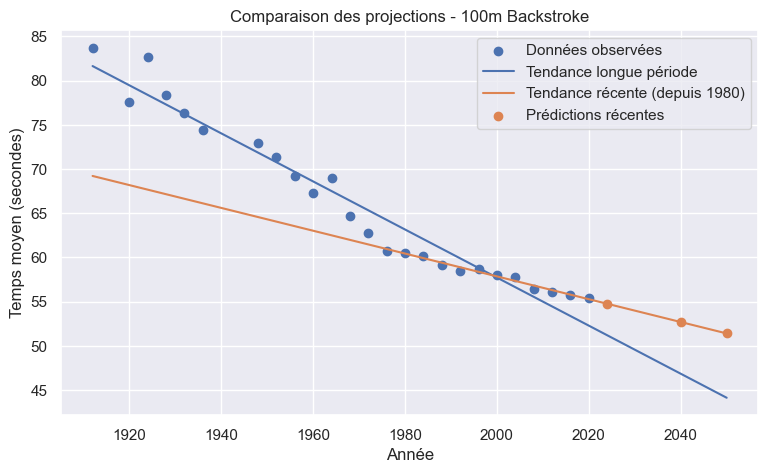

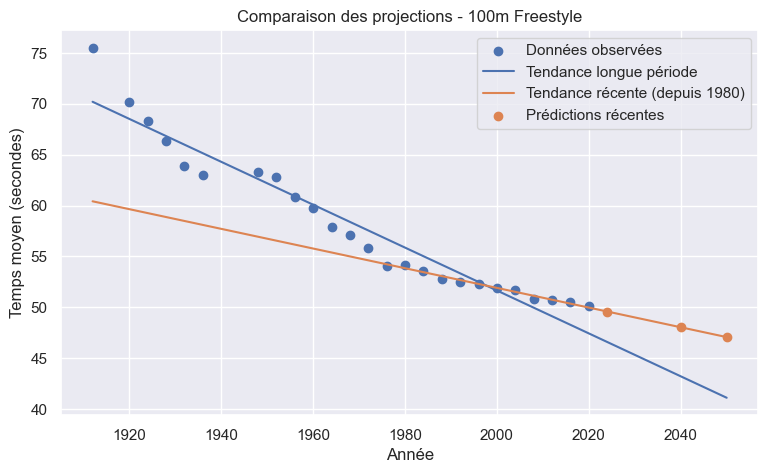

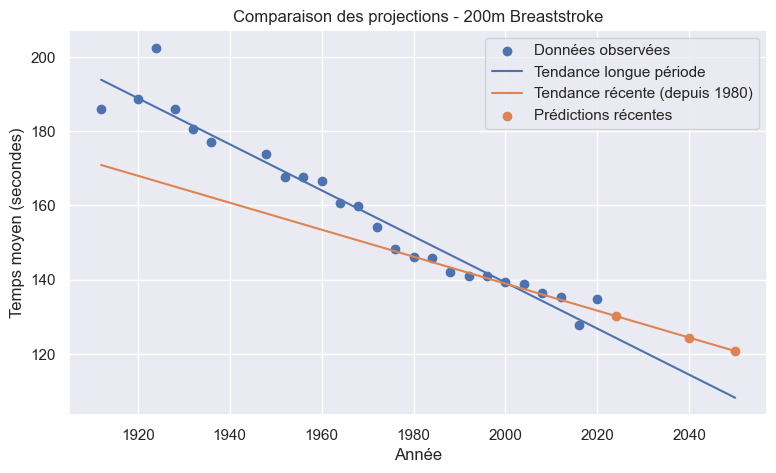

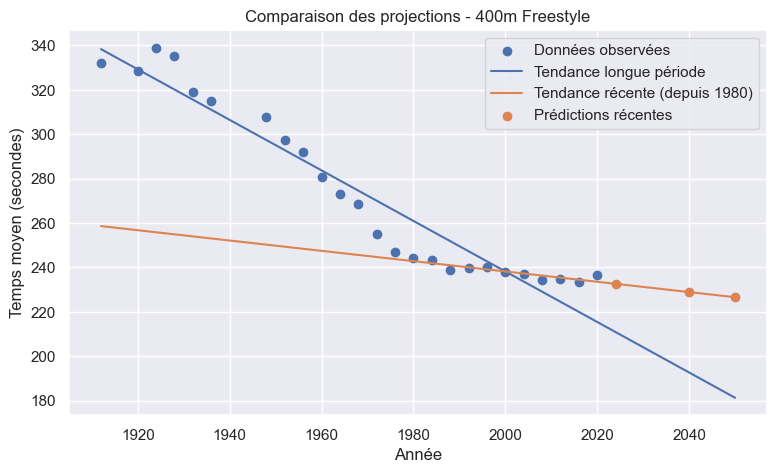

In [120]:
for event in pred_events:
    subset_all = pred_data[pred_data['Event'] == event].copy()
    subset_recent = recent_pred_data[recent_pred_data['Event'] == event].copy()
    
    model_all = LinearRegression()
    model_all.fit(subset_all[['Year']], subset_all['mean'])
    
    model_recent = LinearRegression()
    model_recent.fit(subset_recent[['Year']], subset_recent['mean'])
    
    years_line = pd.DataFrame({'Year': np.arange(subset_all['Year'].min(), 2051)})
    
    plt.figure(figsize=(9,5))
    plt.scatter(subset_all['Year'], subset_all['mean'], label='Données observées')
    plt.plot(years_line['Year'], model_all.predict(years_line), label='Tendance longue période')
    plt.plot(years_line['Year'], model_recent.predict(years_line), label='Tendance récente (depuis 1980)')
    plt.scatter(future_years['Year'], model_recent.predict(future_years), label='Prédictions récentes')
    
    plt.title(f"Comparaison des projections - {event}")
    plt.xlabel("Année")
    plt.ylabel("Temps moyen (secondes)")
    plt.grid(True)
    plt.legend()
    plt.show()

La comparaison entre les deux approches montre clairement que le modèle ajusté sur l’ensemble de la période 1912–2020 est beaucoup plus optimiste que celui construit sur la période récente. Dans les quatre épreuves, la tendance de long terme prolonge les fortes améliorations observées au XXe siècle et conduit à des prédictions très basses pour 2024, 2040 et 2050.

À l’inverse, le modèle ajusté depuis 1980 propose une évolution plus modérée, mieux alignée avec les données récentes, qui suggèrent un ralentissement de la progression. Cette différence est particulièrement visible pour le 400m Freestyle et le 200m Breaststroke, où la tendance récente est nettement moins décroissante que la tendance historique globale.

Ainsi, le modèle de long terme reste utile pour résumer l’évolution historique générale des performances, mais il paraît peu réaliste pour anticiper le futur proche. Le modèle récent semble au contraire plus crédible pour esquisser des projections prudentes, car il tient mieux compte de la phase actuelle de ralentissement.

<a id='3-5'></a>
### 3.5 — Projection de l'écart relatif hommes/femmes


In [121]:
pred_gap_data = gap_data[gap_data['Event'].isin(pred_events)].copy()
pred_gap_data.head()

Gender,Event,Year,Men,Women,Gap_Women_Men,Relative_Gap,Relative_Gap_pct
2,100m Backstroke,1924,77.200000,88.160000,10.960000,0.141969,14.196891
3,100m Backstroke,1928,72.166667,83.685714,11.519048,0.159617,15.961729
4,100m Backstroke,1932,70.566667,82.066667,11.500000,0.162966,16.296646
5,100m Backstroke,1936,68.885714,79.942857,11.057143,0.160514,16.051431
6,100m Backstroke,1948,68.325000,77.662500,9.337500,0.136663,13.666301


In [122]:
recent_gap_data = pred_gap_data[pred_gap_data['Year'] >= 1980].copy()

In [123]:
from sklearn.linear_model import LinearRegression
import pandas as pd

future_years = pd.DataFrame({'Year': [2024, 2040, 2050]})

gap_predictions = []

for event in pred_events:
    subset = recent_gap_data[recent_gap_data['Event'] == event].copy()
    
    X = subset[['Year']]
    y = subset['Relative_Gap_pct']
    
    model = LinearRegression()
    model.fit(X, y)
    
    y_future = model.predict(future_years)
    
    for year, pred in zip(future_years['Year'], y_future):
        gap_predictions.append({
            'Event': event,
            'Year_pred': year,
            'Predicted_relative_gap': pred,
            'Slope_gap': model.coef_[0],
            'Intercept_gap': model.intercept_
        })

gap_predictions_df = pd.DataFrame(gap_predictions)
gap_predictions_df

,Event,Year_pred,Predicted_relative_gap,Slope_gap,Intercept_gap
0,100m Backstroke,2024,11.884302,0.010157,-8.673553
1,100m Backstroke,2040,12.046815,0.010157,-8.673553
2,100m Backstroke,2050,12.148385,0.010157,-8.673553
3,100m Freestyle,2024,11.327814,-0.013210,38.065217
4,100m Freestyle,2040,11.116451,-0.013210,38.065217
5,100m Freestyle,2050,10.984349,-0.013210,38.065217
6,200m Breaststroke,2024,10.979170,0.016700,-22.820812
7,200m Breaststroke,2040,11.246364,0.016700,-22.820812
8,200m Breaststroke,2050,11.413360,0.016700,-22.820812
9,400m Freestyle,2024,8.909703,-0.001479,11.903037


In [124]:
gap_predictions_pivot = gap_predictions_df.pivot(
    index='Event',
    columns='Year_pred',
    values='Predicted_relative_gap'
)

gap_predictions_pivot

Year_pred,2024,2040,2050
Event,,,
100m Backstroke,11.884302,12.046815,12.148385
100m Freestyle,11.327814,11.116451,10.984349
200m Breaststroke,10.979170,11.246364,11.413360
400m Freestyle,8.909703,8.886041,8.871252


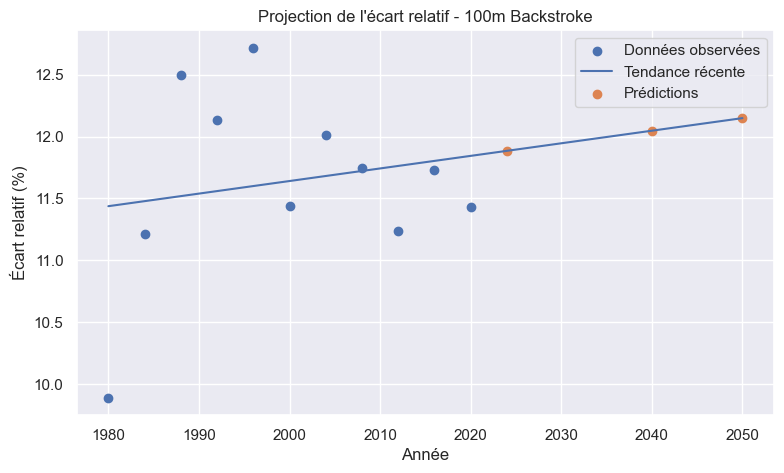

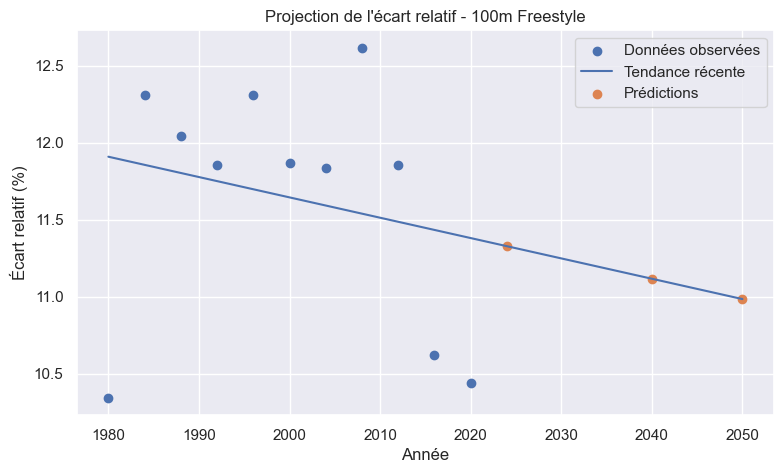

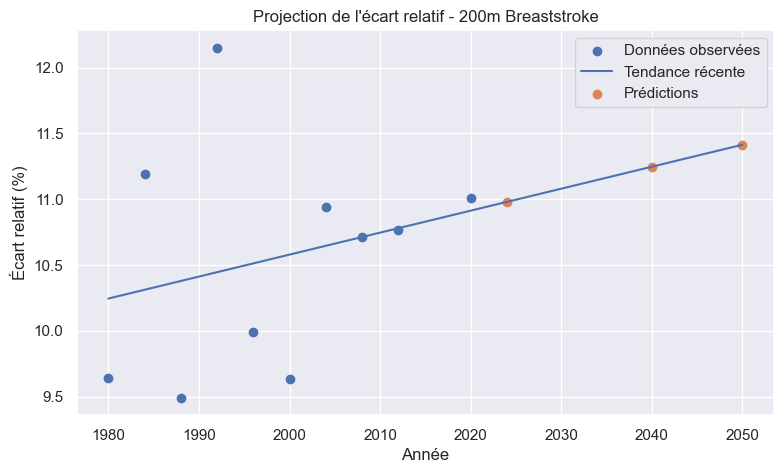

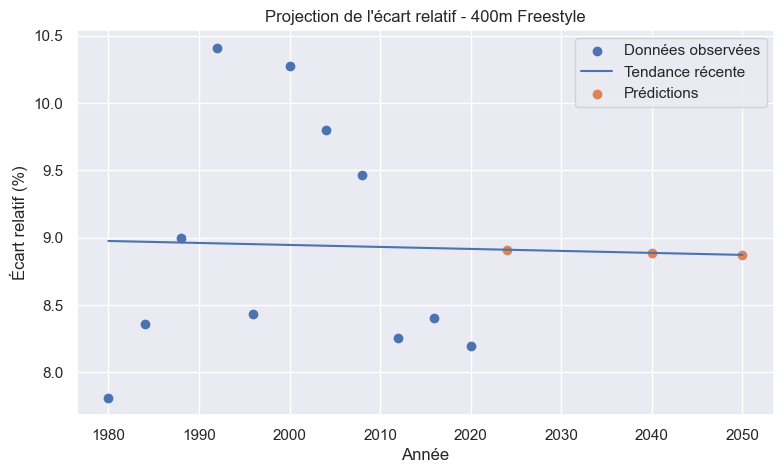

In [125]:
for event in pred_events:
    subset = recent_gap_data[recent_gap_data['Event'] == event].copy()
    
    model = LinearRegression()
    model.fit(subset[['Year']], subset['Relative_Gap_pct'])
    
    years_line = pd.DataFrame({'Year': range(subset['Year'].min(), 2051)})
    
    plt.figure(figsize=(9,5))
    plt.scatter(subset['Year'], subset['Relative_Gap_pct'], label='Données observées')
    plt.plot(years_line['Year'], model.predict(years_line), label='Tendance récente')
    plt.scatter(future_years['Year'], model.predict(future_years), label='Prédictions')
    
    plt.title(f"Projection de l'écart relatif - {event}")
    plt.xlabel("Année")
    plt.ylabel("Écart relatif (%)")
    plt.grid(True)
    plt.legend()
    plt.show()

Les projections obtenues sur la période récente montrent que l’écart relatif entre hommes et femmes ne suit plus partout une baisse nette et régulière. Dans le 100m Freestyle et le 400m Freestyle, le modèle suggère encore une très légère diminution, mais celle-ci reste faible. Dans le 100m Backstroke et le 200m Breaststroke, la tendance ajustée est même légèrement croissante, ce qui traduit plutôt une stabilisation qu’un véritable rapprochement continu.

Ces résultats sont cohérents avec les observations faites dans la première partie : la réduction de l’écart hommes/femmes a bien existé sur le long terme, mais elle semble aujourd’hui beaucoup plus lente, et selon les épreuves, elle peut laisser place à une phase de plateau. Autrement dit, les performances féminines et masculines continuent d’être proches de leurs niveaux relatifs récents, sans que l’on observe nécessairement une diminution marquée de l’écart dans le futur proche.

Cette dernière projection confirme donc l’idée générale de la partie prédictive : les tendances récentes sont beaucoup plus modérées que celles observées sur l’ensemble du XXe siècle, et les extrapolations doivent être interprétées avec prudence.

<a id='ccl'></a>
## Conclusion générale



Ce projet avait pour objectif de caractériser l’évolution des performances et les profils nationaux en natation olympique entre 1912 et 2020. Les différentes méthodes mobilisées permettent de répondre de manière assez claire à cette double question.

La première conclusion est que les performances se sont nettement améliorées au cours du temps. Dans les épreuves étudiées, les temps moyens diminuent fortement sur le long terme, ce qui confirme l’existence d’un progrès historique réel. Cette tendance est cohérente avec l’histoire de la natation olympique : professionnalisation de l’entraînement, amélioration des méthodes de préparation physique, perfectionnement des techniques de nage, transformation des bassins et évolution du matériel ont progressivement élevé le niveau général. La natation est d’ailleurs l’une des disciplines majeures du programme olympique depuis les débuts des Jeux modernes, et les épreuves féminines y sont présentes depuis 1912, ce qui permet d’observer cette évolution sur une longue durée. :contentReference[oaicite:0]{index=0}

La deuxième conclusion est que l’écart entre hommes et femmes a globalement eu tendance à se réduire, même si cette réduction n’est ni uniforme ni parfaitement régulière selon les épreuves. L’étude en secondes montrait déjà un rapprochement, mais l’étude en pourcentage a permis de mieux comparer des nages de durées très différentes. Elle a montré qu’un écart absolu important dans une épreuve longue ne signifie pas forcément un écart relatif plus marqué. Au total, les courbes, les corrélations et les projections récentes suggèrent plutôt un rapprochement ancien bien réel, suivi d’une phase plus récente de ralentissement et parfois de stabilisation.

La troisième conclusion concerne les pays. L’analyse descriptive, l’ACP, la classification hiérarchique et le K-means convergent vers l’existence de profils nationaux bien distincts. Les **États-Unis** apparaissent comme un cas totalement à part, ce qui est historiquement logique : ils dominent très largement la natation olympique en nombre de titres et de médailles, et cette domination s’explique à la fois par leur profondeur historique, la densité de leur vivier et la succession de générations exceptionnelles. Le cas de **Michael Phelps**, le plus grand médaillé olympique de l’histoire avec 28 médailles dont 23 en or, illustre bien cette capacité à produire des nageurs hors norme, sans pour autant résumer à lui seul la puissance américaine. :contentReference[oaicite:1]{index=1}

Derrière les États-Unis, l’**Australie** ressort logiquement comme l’autre grande puissance structurelle. Là encore, le résultat statistique est cohérent avec l’histoire sportive : l’Australie est la deuxième nation de l’histoire de la natation olympique en nombre de médailles, et la natation y occupe une place centrale dans la culture sportive nationale. Les documents de **Swimming Australia** montrent aussi l’existence d’une filière de haut niveau structurée, ce qui explique que la performance australienne ne repose pas sur quelques exploits isolés mais sur une organisation durable. :contentReference[oaicite:2]{index=2}

On retrouve ensuite un noyau de nations historiquement solides, comme le **Japon**, l’**Allemagne**, la **Grande-Bretagne**, la **Hongrie**, le **Canada**, la **Suède** ou l’ensemble **Russie/URSS**. Leur présence dans les groupes supérieurs est cohérente avec leur histoire olympique : certains de ces pays se distinguent par leur longévité et leur régularité, d’autres par des périodes de très forte réussite, ou encore par leur capacité à rester compétitifs dans plusieurs styles de nage et sur plusieurs générations. L’**Allemagne** et l’ensemble **Russie/URSS** occupent ainsi une place importante non seulement parce qu’ils ont produit de très grands nageurs, mais aussi parce qu’ils ont pesé durablement dans la hiérarchie olympique sur plusieurs périodes historiques.

Enfin, la partie prédictive a permis d’apporter une nuance essentielle. Une extrapolation linéaire sur toute la période 1912–2020 conduit à des prévisions trop optimistes, car elle prolonge mécaniquement les fortes améliorations du XXe siècle. En revanche, les modèles ajustés sur la période récente donnent des projections plus plausibles et plus proches des réalités observées à Paris 2024, où l’on voit que les progrès continuent, mais à un rythme plus lent et plus irrégulier. Cela conduit à une conclusion importante : la natation olympique reste un sport de progrès, mais ces progrès ne suivent plus aujourd’hui la même dynamique que dans la première moitié ou le milieu du XXe siècle.

Au total, ce projet montre que la natation olympique ne peut pas être réduite à une simple liste de médailles ou à une baisse moyenne des temps. Elle fait apparaître à la fois une histoire de progrès des performances, un rapprochement partiel entre les sexes, et une hiérarchie internationale structurée autour de quelques grandes puissances, avec en tête les **États-Unis** puis l’**Australie**, suivis d’un ensemble de nations historiquement fortes. Les méthodes statistiques utilisées permettent ainsi de retrouver, sous une forme quantitative, des régularités qui sont en grande partie cohérentes avec l’histoire réelle de la discipline.